# FDIC Deposit Early Warning: a deep learning masterclass
## Can a small neural network earn a place on an analyst's desk?

Imagine checking your bank balance tomorrow. Today you have clues, but tomorrow's balance is still unknown.
A bank analyst faces a larger version of that question: **which banks deserve a closer look before the next deposit report?**
An analyst with time to review 10% of eligible banks each quarter needs a ranking that improves on a simple rule: start with the largest banks.

**You will learn to build the entire argument:** define a measurable question, inspect messy data, protect the future from leakage,
understand a neuron, build a small deep network, test its implementation, compare alternatives, and explain what the evidence permits.
This is a self-study companion to `Assign1.ipynb`; the original assignment is preserved.

**What does “deep” mean here?** Two learned hidden layers transform seven financial and calendar inputs before two output heads answer
“will deposits fall?” and “how large might the decline be?” More layers are a design choice whose value must be tested.

**Start here:** basic Python variables, lists, functions, and a little Pandas help. Every code cell has an ELI8 explanation,
a reading guide, and a question with an answer. Code remains visible. Predict first, run second, explain the output in your own words third.
The cells use the real supplied FDIC file. One explicitly labeled arithmetic example teaches a neuron; it is never model-performance evidence.

### Study route

| Session | Guiding question | You should be able to explain afterward |
|---|---|---|
| 1 · Audit | Can we trust a row? | Grain, units, types, nulls, duplicates, and coverage |
| 2 · EDA | What patterns change our choices? | Skew, extreme values, categories, relationships, and target definition |
| 3 · Preparation | What could accidentally reveal tomorrow? | Adjacency, embargo, feature timing, train-only preprocessing |
| 4 · Network | How does a network learn? | Weights, bias, activation, gradient, loss, batches, regularization |
| 5 · Experiments | Does complexity earn its cost? | Baselines, ablations, validation selection, seed sensitivity |
| 6 · Evidence | What can the watchlist support? | Calibration, recall, dollar capture, error slices, uncertainty, next test |

Plan several study sessions. Run All can take several minutes on CPU. Saved outputs allow reading without training again.
For deliberate practice, copy this notebook before changing experiments and keep an experiment log.

### Evidence contract

- **Population:** reports in the supplied 2020 Q1–2024 Q4 CSV, keyed by FDIC certificate and quarter. Modeling requires adjacent prior and next reports,
  positive assets and prior deposits, and at least USD 10M current domestic deposits. This threshold is a teaching assumption, not an FDIC rule.
- **Outcome:** a positive next-quarter change *downward* in domestic deposit balance, measured in USD M. It is neither a bank-failure label nor proof of customer withdrawals.
- **Use:** an illustrative analyst review queue. A false alarm consumes analyst time; a missed large decline leaves exposure outside the queue.
  Those costs are unpriced here. No automated action against a bank or depositor is justified by this exercise.
- **Timing:** report dates are accounting dates. Publication timestamps and historical data vintages are absent. This is a retrospective report-to-report study,
  not a demonstrated live early warning system. Revised reports and mergers can change interpretation.
- **Honest test status:** the original assignment already evaluated 2024. We freeze this notebook's choices before its 2024 evaluation,
  but 2024 is a **reused historical holdout**, not untouched confirmatory evidence. A future vintage is needed for that claim.
- **Sources:** [FDIC BankFind financial API](https://api.fdic.gov/banks/docs/),
  [field dictionary](https://api.fdic.gov/banks/docs/risview_properties.yaml), and the local extraction script `download_fdic.py`.
  The supplied EDA article is a teaching reference, not authority to delete unusual observations.

### What should I expect to learn from the result?

The final answer is calculated at the end. A high dollar-capture percentage can largely reflect bank size.
Watch the **difference from the size baseline**, the quarter-to-quarter pattern, and probability quality together.
Finding that a simpler method performs better is a successful experiment.

## 1. Can we trust the source?

**Setup:** from this project folder run `uv sync --python 3.12 --locked`, select `.venv/bin/python`, then Run All.
The notebook reads `data/fdic_financials_2020_2024.csv` and uses the bundled notecards wheel. It makes no network calls during analysis.
For Colab, upload and extract `FDIC_Deep_Learning_Masterclass.zip`, change into its extracted folder, and install
`tensorflow==2.18.1 pandas scikit-learn matplotlib ./vendor/wm_notecards-0.1.0-py3-none-any.whl` before running.
Local execution is verified separately; Colab instructions are a portability path, not a claim of a tested cloud run.

### 1.1 · What tools do we need, and how do we keep a run repeatable?

**Short answer.** Keep the data path, random seed, review capacity, and training budget visible in one place.

**ELI8.** Our tools are pencils and rulers. A random seed tells the model which shuffled deck to start with; it does not guarantee the same result on every computer.

**Read the code.** Imports bring tools into the notebook. Constants name choices. `receipt` only displays a table; `finish` saves and displays a figure. Neither helper changes the data or trains a model.

**Predict before Run:** If we change the seed, have we collected new banks?

<details><summary>Check your reasoning</summary>

No. We have changed training randomness. That tests stability on the same evidence.

</details>

In [1]:
# EXEMPLAR: bootstrap
import os
from pathlib import Path
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".mpl-cache"))
import hashlib, json, time, platform, importlib.metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display
import tensorflow as tf
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.metrics import (average_precision_score, roc_auc_score, brier_score_loss,
    mean_absolute_error, precision_recall_curve, roc_curve, confusion_matrix)
from sklearn.calibration import calibration_curve
from wm_notecards import WMTheme, init_notebook
from wm_notecards.cards import (question_card, takeaway_card, preview_card,
    wm_check_card, wm_formula_card, wm_counterintuitive_card)
from wm_notecards.tables import wm_render_styler, display_cols_by_dtype, wm_render_micro_profile_cards
from wm_notecards.eda import (wm_eda_overview, display_data_chips,
    wm_build_category_share_table, wm_build_correlation_clues,
    PreprocessingDecision, wm_build_preprocessing_log,
    FeatureDecision, wm_validate_feature_manifest, wm_build_eda_contract)

SEED, CAPACITY, MAX_EPOCHS, BATCH_SIZE = 42, 0.10, 18, 512
MIN_DEPOSITS_000, SKEW_REVIEW, CORR_REVIEW = 10_000, 1.0, 0.8
tf.keras.utils.set_random_seed(SEED)
tf.config.set_visible_devices([], "GPU")
tf.config.threading.set_inter_op_parallelism_threads(2)
tf.config.threading.set_intra_op_parallelism_threads(2)
tf.config.experimental.enable_op_determinism()
theme = WMTheme.light()
init_notebook(expand_colab_outputs=True)
BLUE, AMBER, INK, GREY = "#007C91", "#B7791F", "#182E3A", "#697884"
plt.rcParams.update({"figure.figsize": (9, 4.5), "figure.dpi": 110,
    "font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.16, "axes.axisbelow": True})
OUT = Path("masterclass_outputs")
OUT.mkdir(exist_ok=True)

def receipt(frame, title, formats=None):
    styled = frame.style.hide(axis="index")
    if formats:
        styled = styled.format(formats, na_rep="NA")
    wm_render_styler(styled, theme=theme, title=title,
        wrap_columns={c: 290 for c in frame.columns if c in {"Reason", "Meaning", "Decision"}})

def finish(fig, name):
    fig.tight_layout()
    fig.savefig(OUT / f"{name}.png", dpi=145, bbox_inches="tight")
    alt = "; ".join(ax.get_title() for ax in fig.axes if ax.get_title())
    display(fig, metadata={"image/png": {"alt": alt}})
    plt.close(fig)

def takeaway(title, body, metric=None):
    takeaway_card(title=title, body=body, metric=metric, theme=theme, kicker="TAKEAWAY")

print("CPU lesson environment:", platform.python_version(), "| TensorFlow", tf.__version__)

CPU lesson environment: 3.12.1 | TensorFlow 2.18.1


### 1.2 · What does one row represent?

**Short answer.** One row is one bank certificate in one reporting quarter. Repeat appearances of a bank are expected.

**ELI8.** A class photo taken each term includes many of the same children. Repeated children are useful history; two copies of the same term's photo are a different problem.

**Read the code.** `read_csv` loads the raw file. We record a fingerprint, check the required columns, and display six rows. We leave `raw` untouched so later transformations can be audited.

**Predict before Run:** Should we drop every repeated CERT?

<details><summary>Check your reasoning</summary>

No. The unique key is CERT plus REPDTE. Dropping repeated CERT would destroy the time series.

</details>

In [2]:
# EXEMPLAR: purposeful-source-preview
data_path = Path("data/fdic_financials_2020_2024.csv")
if not data_path.is_file():
    raise FileNotFoundError("Open the notebook from the extracted project folder containing data/.")
source_sha = hashlib.sha256(data_path.read_bytes()).hexdigest()
raw = pd.read_csv(data_path)
expected = {"REPDTE", "CERT", "NAME", "STALP", "DEPDOM", "ASSET", "LNLSNET", "CHBAL", "EQ"}
assert expected.issubset(raw.columns)
raw_fingerprint = pd.util.hash_pandas_object(raw, index=True).sum()
preview_card(title="A bank report is a dated observation", theme=theme,
    body=f"{len(raw):,} rows, {raw.CERT.nunique():,} certificates, {raw.shape[1]} source fields.",
    bullets=["CERT identifies the institution; REPDTE identifies the reporting date.",
             "Financial balances in this extract are reported in thousands of US dollars."],
    kicker="SOURCE")
display(raw.head(6))
print("CSV SHA-256:", source_sha)

,REPDTE,CERT,NAME,STALP,DEPDOM,ASSET,LNLSNET,CHBAL,EQ
0,20200331,10004,ERGO BANK,WI,77700,95114,69681,4548,12061.0
1,20200331,10011,WOODFORD STATE BANK,WI,196880,256172,168339,8385,24494.0
2,20200331,10012,PORTAGE COUNTY BANK,WI,142528,161445,105878,28933,18673.0
3,20200331,10015,SECURITY BANK,WI,100234,115649,94583,4748,14901.0
4,20200331,10044,NATIONAL EXCHANGE BANK&TRUST,WI,1614693,2089096,1272764,191617,408155.0
5,20200331,10055,FIRST SOUTHERN BANK,GA,123080,141312,85771,28392,17829.0


CSV SHA-256: a5ec2223c7ac66de61e83681e449a7cf4ed66052b98229207d5f4067db23810b


### 1.3 · Why can a date look like a number?

**Short answer.** Storage type and analytical meaning are different. CERT is an identifier and REPDTE is a date even though both arrive as integers.

**ELI8.** A shirt number tells you who a player is; adding two shirt numbers tells you nothing about their skill.

**Read the code.** The dtype chips expose storage types. The dictionary explains all nine fields. We parse REPDTE into a new column with a strict format and fail on malformed dates, preserving the original.

**Predict before Run:** Should CERT and NAME go into the neural network?

<details><summary>Check your reasoning</summary>

No. They identify reports and let us audit predictions. This exercise learns financial relationships, not name or certificate shortcuts.

</details>

In [3]:
# EXEMPLAR: dtype-chips
display_cols_by_dtype(raw.dtypes, theme=theme, group_label="Raw storage types")
dictionary = pd.DataFrame([
    ("CERT", "Bank certificate; identifier"), ("REPDTE", "Quarter-end date; YYYYMMDD"),
    ("NAME", "Institution name; audit context"), ("STALP", "State abbreviation; institution location context"),
    ("DEPDOM", "Domestic-office deposits; USD 000"), ("ASSET", "Total assets; USD 000"),
    ("LNLSNET", "Net loans and leases; USD 000"), ("CHBAL", "Cash and due from depository institutions; USD 000"),
    ("EQ", "Equity capital; USD 000; negative values can be real")], columns=["Field", "Meaning"])
receipt(dictionary, "A dictionary prevents accidental arithmetic")
reviewed = raw.copy()
reviewed["report_date"] = pd.to_datetime(reviewed.REPDTE.astype(str), format="%Y%m%d", errors="raise")
assert reviewed.report_date.dt.is_quarter_end.all()
display_cols_by_dtype(reviewed.drop(columns="REPDTE").dtypes, theme=theme,
    group_label="Reviewed storage types: report_date is now datetime; roles stay in the dictionary")

Field,Meaning
CERT,Bank certificate; identifier
REPDTE,Quarter-end date; YYYYMMDD
NAME,Institution name; audit context
STALP,State abbreviation; institution location context
DEPDOM,Domestic-office deposits; USD 000
ASSET,Total assets; USD 000
LNLSNET,Net loans and leases; USD 000
CHBAL,Cash and due from depository institutions; USD 000
EQ,Equity capital; USD 000; negative values can be real


### 1.4 · Which values are missing, and is zero the same thing?

**Short answer.** Audit every field. Missing equity and a recorded equity of zero carry different information.

**ELI8.** An empty answer on a quiz means we do not know the answer. Writing zero is an actual answer.

**Read the code.** `isna` makes a true/false mask; `sum` counts blanks and `mean` gives the fraction. The bar chart uses a zero origin and exact count labels. Blank strings are checked separately.

**Predict before Run:** Can 99.6% complete round to 100% in a small label?

<details><summary>Check your reasoning</summary>

Yes. Use this exact receipt for decisions. This notebook uses exact missing counts and three-decimal percentages instead of rounded completeness chips.

</details>

Field,Missing rows,Missing %,Dtype
EQ,340,0.351,float64
STALP,20,0.021,str
ASSET,0,0.000,int64
CERT,0,0.000,int64
CHBAL,0,0.000,int64
DEPDOM,0,0.000,int64
LNLSNET,0,0.000,int64
NAME,0,0.000,str
REPDTE,0,0.000,int64


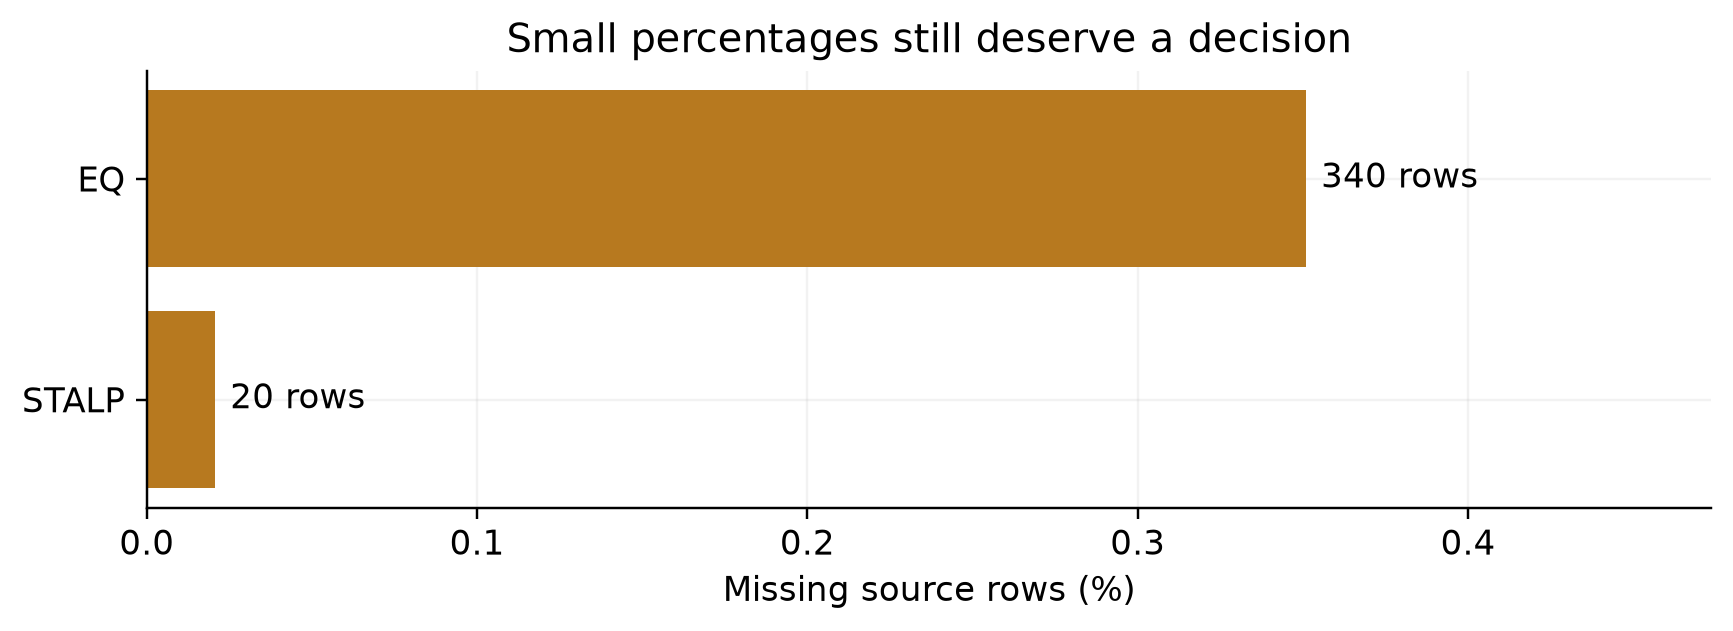

Whitespace-only strings: {'NAME': 0, 'STALP': 0}


In [4]:
# EXEMPLAR: missingness-evidence
missing = pd.DataFrame({"Field": raw.columns, "Missing rows": raw.isna().sum().values,
    "Missing %": 100 * raw.isna().mean().values, "Dtype": raw.dtypes.astype(str).values})
missing = missing.sort_values(["Missing rows", "Field"], ascending=[False, True])
receipt(missing, f"Complete missingness audit: denominator {len(raw):,} rows", {"Missing %": "{:.3f}"})
nonzero = missing.loc[missing["Missing rows"] > 0].sort_values("Missing %")
fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(nonzero.Field, nonzero["Missing %"], color=AMBER)
ax.bar_label(bars, labels=[f"{n:,} rows" for n in nonzero["Missing rows"]], padding=5)
ax.set(xlabel="Missing source rows (%)", title="Small percentages still deserve a decision")
ax.set_xlim(0, max(nonzero["Missing %"].max() * 1.35, 0.1))
finish(fig, "01_missingness")
blank_strings = raw.select_dtypes(include=["object", "str", "string"]).apply(
    lambda s: s.str.strip().eq("").sum())
print("Whitespace-only strings:", blank_strings.to_dict())
takeaway("Equity needs a policy; state is context", f"EQ is missing in {raw.EQ.isna().sum():,} reports; "
    f"STALP is missing in {raw.STALP.isna().sum():,}. We will audit patterns before imputing financial predictors.")

### 1.5 · Are the blanks scattered or concentrated?

**Short answer.** Missingness by time and institution can reveal a systematic reporting gap. It cannot prove a missing-data mechanism.

**ELI8.** If the same student leaves the same question blank each week, a class-wide average hides that pattern.

**Read the code.** We group the missingness masks by report date, then count distinct affected certificates. Rates by quarter use that quarter's reports as their denominator.

**Predict before Run:** Do these charts prove missing-at-random?

<details><summary>Check your reasoning</summary>

No. MCAR means unrelated to observed or unobserved values; MAR means explainable by observed information; MNAR may depend on the unseen value. Observed patterns alone cannot settle that distinction.

</details>

report_date,EQ,STALP
2020-03-31 00:00:00,0.328,0.019
2020-06-30 00:00:00,0.331,0.019
2020-09-30 00:00:00,0.333,0.020
2020-12-31 00:00:00,0.336,0.020
2021-03-31 00:00:00,0.337,0.020
2021-06-30 00:00:00,0.339,0.020
2021-09-30 00:00:00,0.341,0.020
2021-12-31 00:00:00,0.347,0.020
2022-03-31 00:00:00,0.350,0.021
2022-06-30 00:00:00,0.351,0.021


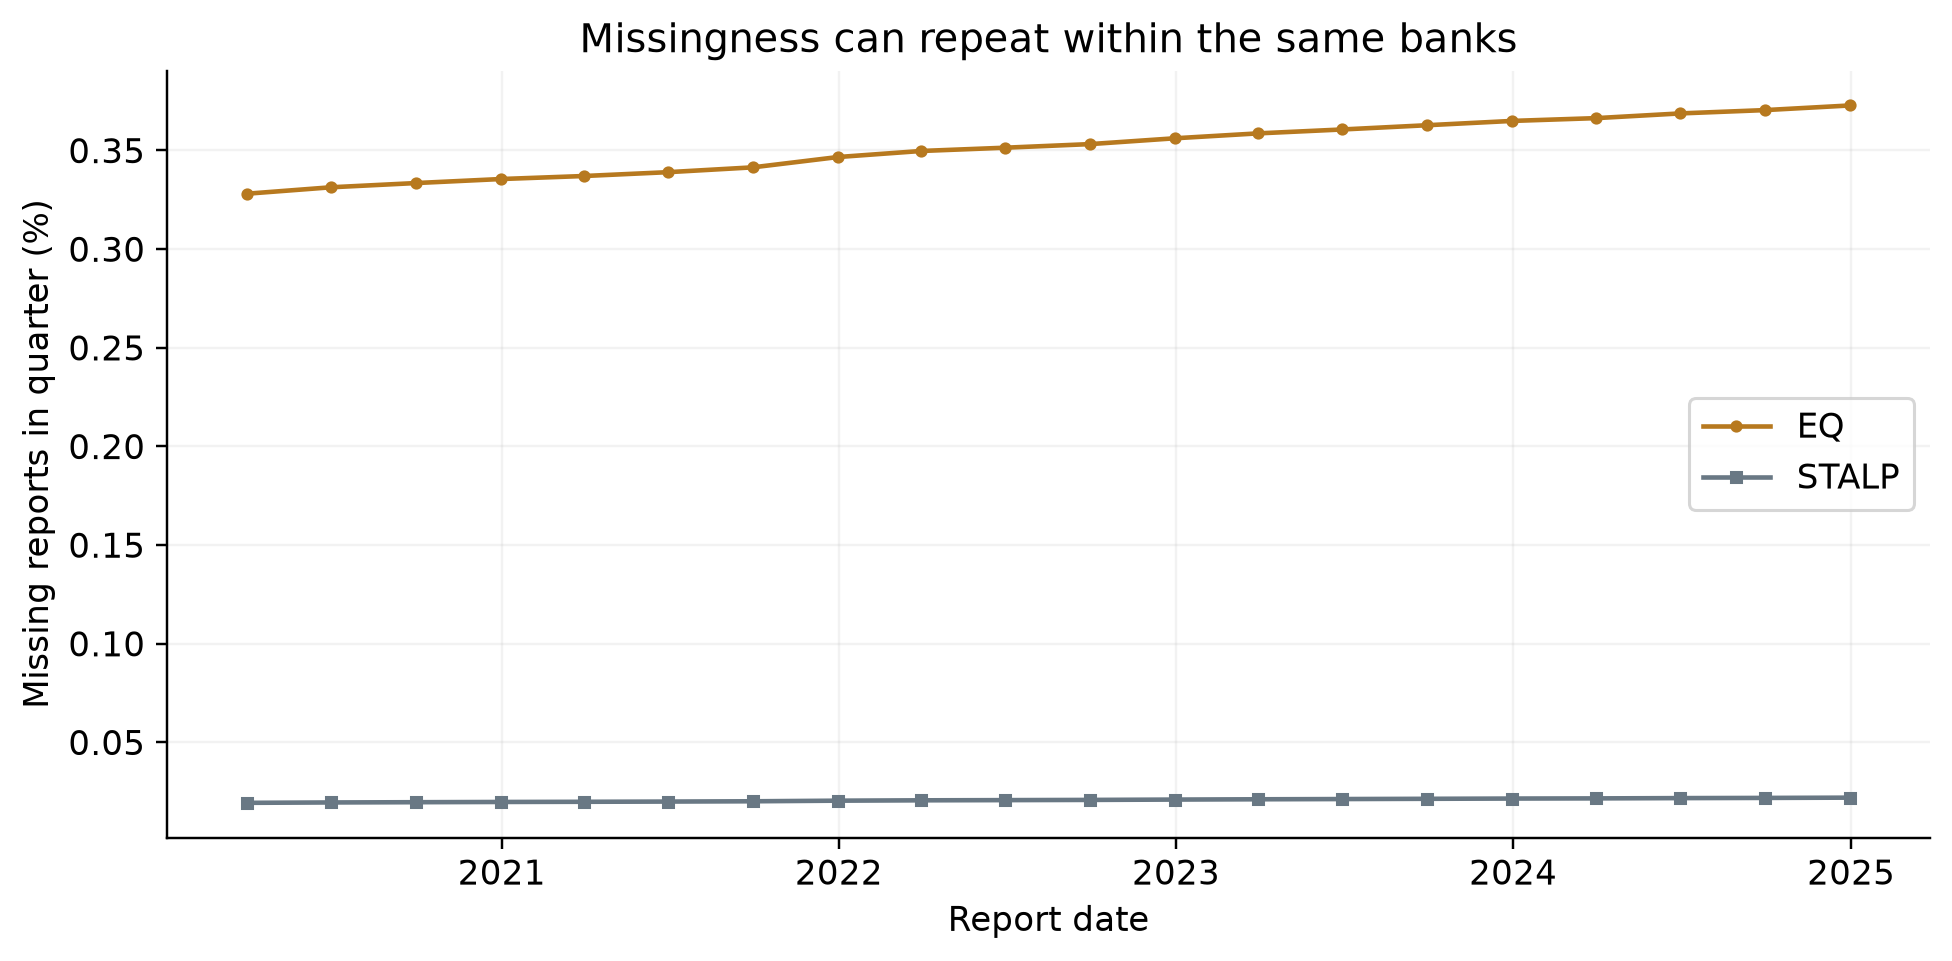

EQ : 340 missing reports across 17 certificates
STALP : 20 missing reports across 1 certificates


In [5]:
missing_by_time = reviewed.groupby("report_date")[["EQ", "STALP"]].agg(lambda s: s.isna().mean() * 100)
receipt(missing_by_time.reset_index(), "Missingness by reporting quarter", {"EQ": "{:.3f}", "STALP": "{:.3f}"})
fig, ax = plt.subplots()
for field, color, marker in [("EQ", AMBER, "o"), ("STALP", GREY, "s")]:
    ax.plot(missing_by_time.index, missing_by_time[field], label=field, color=color, marker=marker, ms=3)
ax.set(title="Missingness can repeat within the same banks", ylabel="Missing reports in quarter (%)", xlabel="Report date")
ax.legend(); finish(fig, "02_missingness_time")
for field in ["EQ", "STALP"]:
    subset = reviewed.loc[reviewed[field].isna()]
    print(field, ":", len(subset), "missing reports across", subset.CERT.nunique(), "certificates")

### 1.6 · Which quality checks should stop us?

**Short answer.** Duplicate keys, invalid dates, and impossible denominators must be resolved before model construction. Extreme but plausible values deserve investigation.

**ELI8.** A giant elephant is unusual in a list of pets. It is not a typo just because it is big.

**Read the code.** Checks count full-row duplicates, repeated bank-quarter keys, zeros, negatives, and accounting ratios. Assertions stop the run on an ambiguous key. Negative equity is flagged for interpretation and retained.

**Predict before Run:** The attached article suggests removing outliers. Should we automatically do that?

<details><summary>Check your reasoning</summary>

No. The largest banks may dominate the decision we care about. Deletion requires evidence of error or a documented change in population.

</details>

In [6]:
# EXEMPLAR: quality-check
numeric_source = ["DEPDOM", "ASSET", "LNLSNET", "CHBAL", "EQ"]
quality = pd.DataFrame({"Field": numeric_source,
    "Zero": [int(raw[c].eq(0).sum()) for c in numeric_source],
    "Negative": [int(raw[c].lt(0).sum()) for c in numeric_source],
    "Nonfinite (not NA)": [int((~np.isfinite(raw[c]) & raw[c].notna()).sum()) for c in numeric_source]})
receipt(quality, "Separate zeros, negatives, and invalid numbers")
key_duplicates = int(raw.duplicated(["CERT", "REPDTE"], keep=False).sum())
wm_check_card(title="The row key controls every future comparison", theme=theme, checks=[
    {"label": "Unique bank-quarter", "status": "PASS" if key_duplicates == 0 else "FAIL", "detail": f"{key_duplicates} duplicated-key rows of {len(raw):,}"},
    {"label": "Exact duplicate records", "status": "PASS" if not raw.duplicated().any() else "CHECK", "detail": f"{raw.duplicated().sum()} repeated complete records"},
    {"label": "Positive assets", "status": "PASS" if raw.ASSET.gt(0).all() else "CHECK", "detail": f"{raw.ASSET.le(0).sum()} nonpositive denominators"},
    {"label": "Negative equity", "status": "CHECK" if raw.EQ.lt(0).any() else "PASS", "detail": f"{raw.EQ.lt(0).sum()} rows retained; not automatically invalid"}])
assert key_duplicates == 0, "Resolve ambiguous duplicate reports before matching quarters."
assert raw.DEPDOM.ge(0).all() and np.isfinite(raw[numeric_source].dropna()).all().all()

Field,Zero,Negative,Nonfinite (not NA)
DEPDOM,1051,0,0
ASSET,0,0,0
LNLSNET,1792,0,0
CHBAL,120,0,0
EQ,0,186,0


### 1.7 · Is a falling bank count evidence of a banking crisis?

**Short answer.** It describes coverage. Exits, mergers, and reporting changes require separate source evidence.

**ELI8.** A shrinking class list might mean students moved classrooms. The count alone does not tell the story.

**Read the code.** Count unique certificates each quarter, then count consecutive appearances within certificates. An absent next report creates an unobserved target, never a zero decline.

**Predict before Run:** Can we call an absent bank a failure?

<details><summary>Check your reasoning</summary>

No. This CSV does not supply the causal history needed for that claim.

</details>

report_date,Reports,Banks
2020-03-31 00:00:00,5182,5182
2020-06-30 00:00:00,5131,5131
2020-09-30 00:00:00,5098,5098
2020-12-31 00:00:00,5067,5067
2021-03-31 00:00:00,5044,5044
2021-06-30 00:00:00,5015,5015
2021-09-30 00:00:00,4979,4979
2021-12-31 00:00:00,4904,4904
2022-03-31 00:00:00,4861,4861
2022-06-30 00:00:00,4838,4838


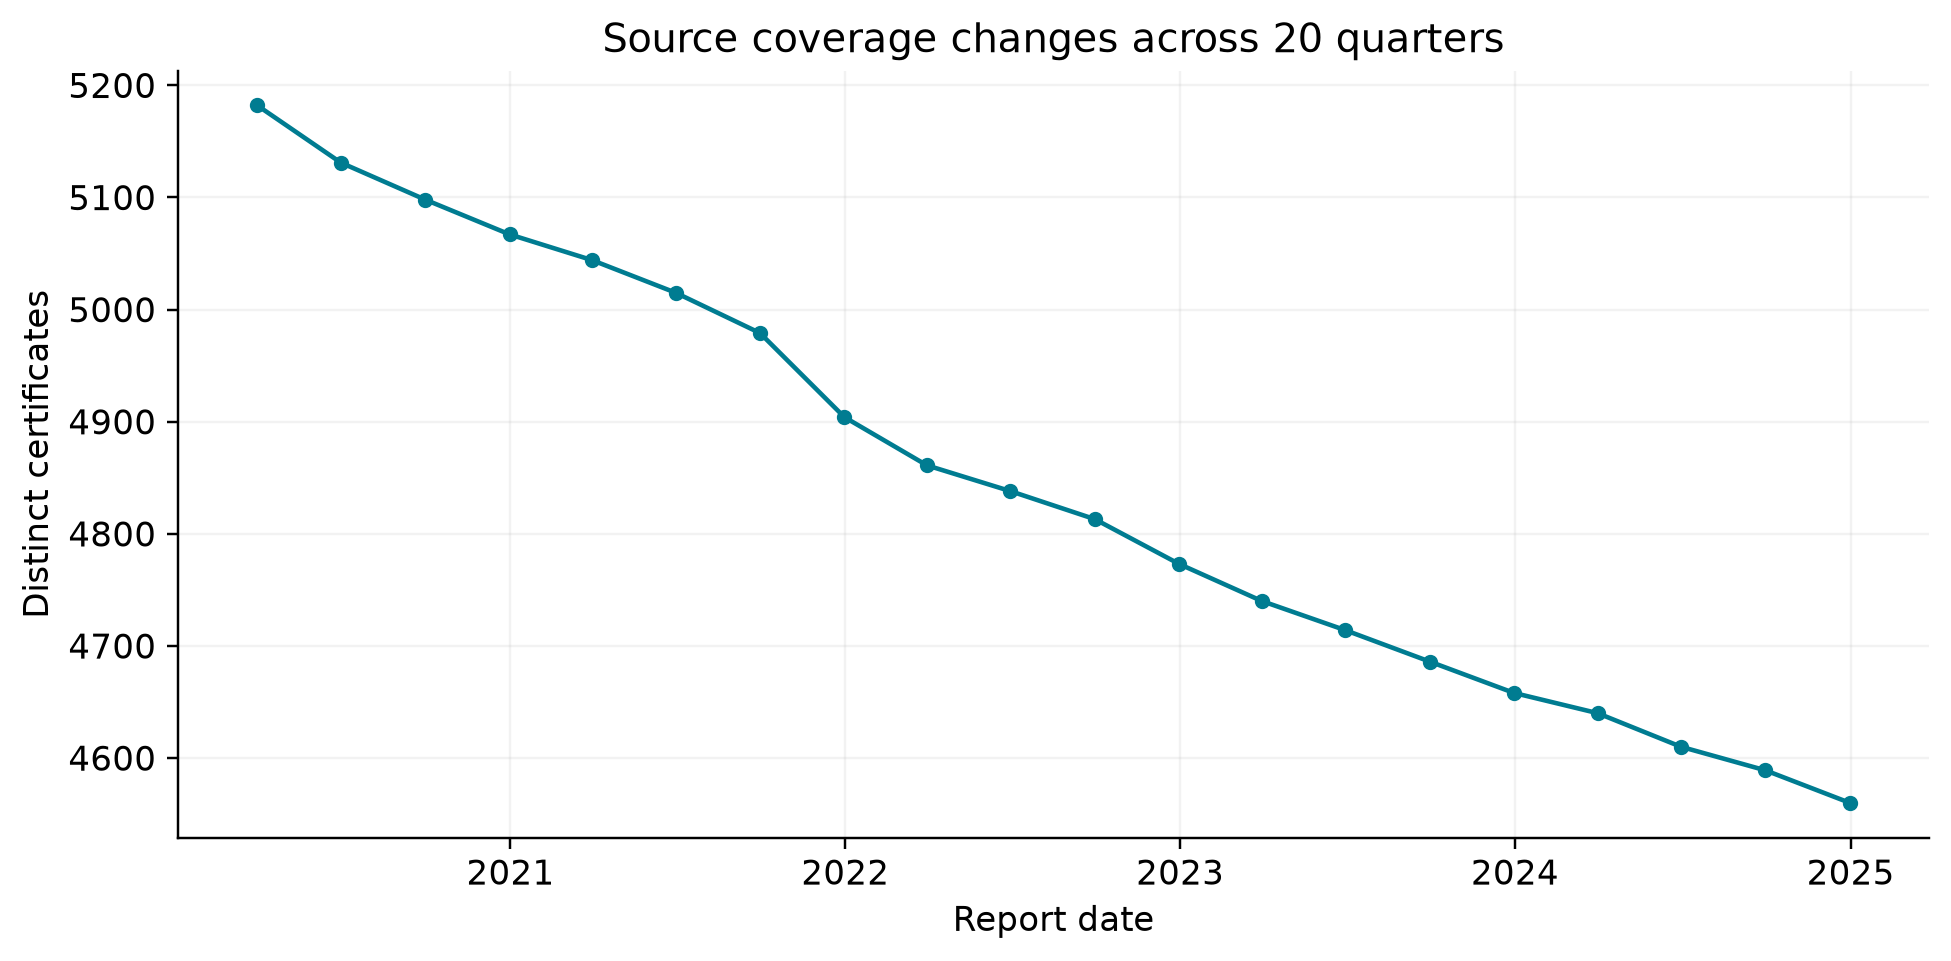

Distinct certificates across the entire file: 5237


In [7]:
coverage = reviewed.groupby("report_date").agg(Reports=("CERT", "size"), Banks=("CERT", "nunique"))
receipt(coverage.reset_index(), "Coverage: each report date has its own population")
fig, ax = plt.subplots()
ax.plot(coverage.index, coverage.Banks, color=BLUE, marker="o", ms=4)
ax.set(title="Source coverage changes across 20 quarters", ylabel="Distinct certificates", xlabel="Report date")
finish(fig, "03_coverage")
print("Distinct certificates across the entire file:", reviewed.CERT.nunique())

## 2. How do we turn reports into a prediction problem?

**Target contract.** For a bank's report at time *t*, let `D_t` be domestic deposits in USD 000.
`runoff_m = max(0, D_t − D_next) / 1000`; `fell = 1` when `runoff_m > 0`, otherwise `0`.
The valid amount lies between zero and current deposits in USD M. Growth becomes zero decline; it does not become negative loss.
Only a same-certificate, adjacent-quarter pair supplies this target. No future balance is imputed.

**Two real questions, two consequences.** A likelihood ranking finds banks likely to decline. A dollar ranking prioritizes amounts.
The top 10% is a visible review-capacity assumption. An analyst would set that budget and price false positives and missed cases.
Location is institution context, not customer geography. We do not infer individual depositors' behavior or fairness from these records.

### 2.1 · How do we find yesterday and tomorrow without mixing banks?

**Short answer.** Sort by bank and date, shift within each bank, and verify the quarter gap is exactly one.

**ELI8.** Put each child's school reports in a separate pile before reading the previous or next page.

**Read the code.** `groupby(...).shift(1)` reads the previous row in a bank's pile; `shift(-1)` reads the next. Adjacency checks protect against gaps. The ledger is a sequential waterfall so exclusions reconcile.

**Predict before Run:** If Q2 is missing, does Q3 count as the next quarter after Q1?

<details><summary>Check your reasoning</summary>

No. A row shift locates the next available report; the quarter-number test decides whether it is the next quarter.

</details>

Step,Remaining,Removed at step
All source reports,96902,0
Adjacent prior report,91665,5237
Adjacent future report,86485,5180
At least USD 10M current deposits,84924,1561
Usable balances and positive assets,84922,2


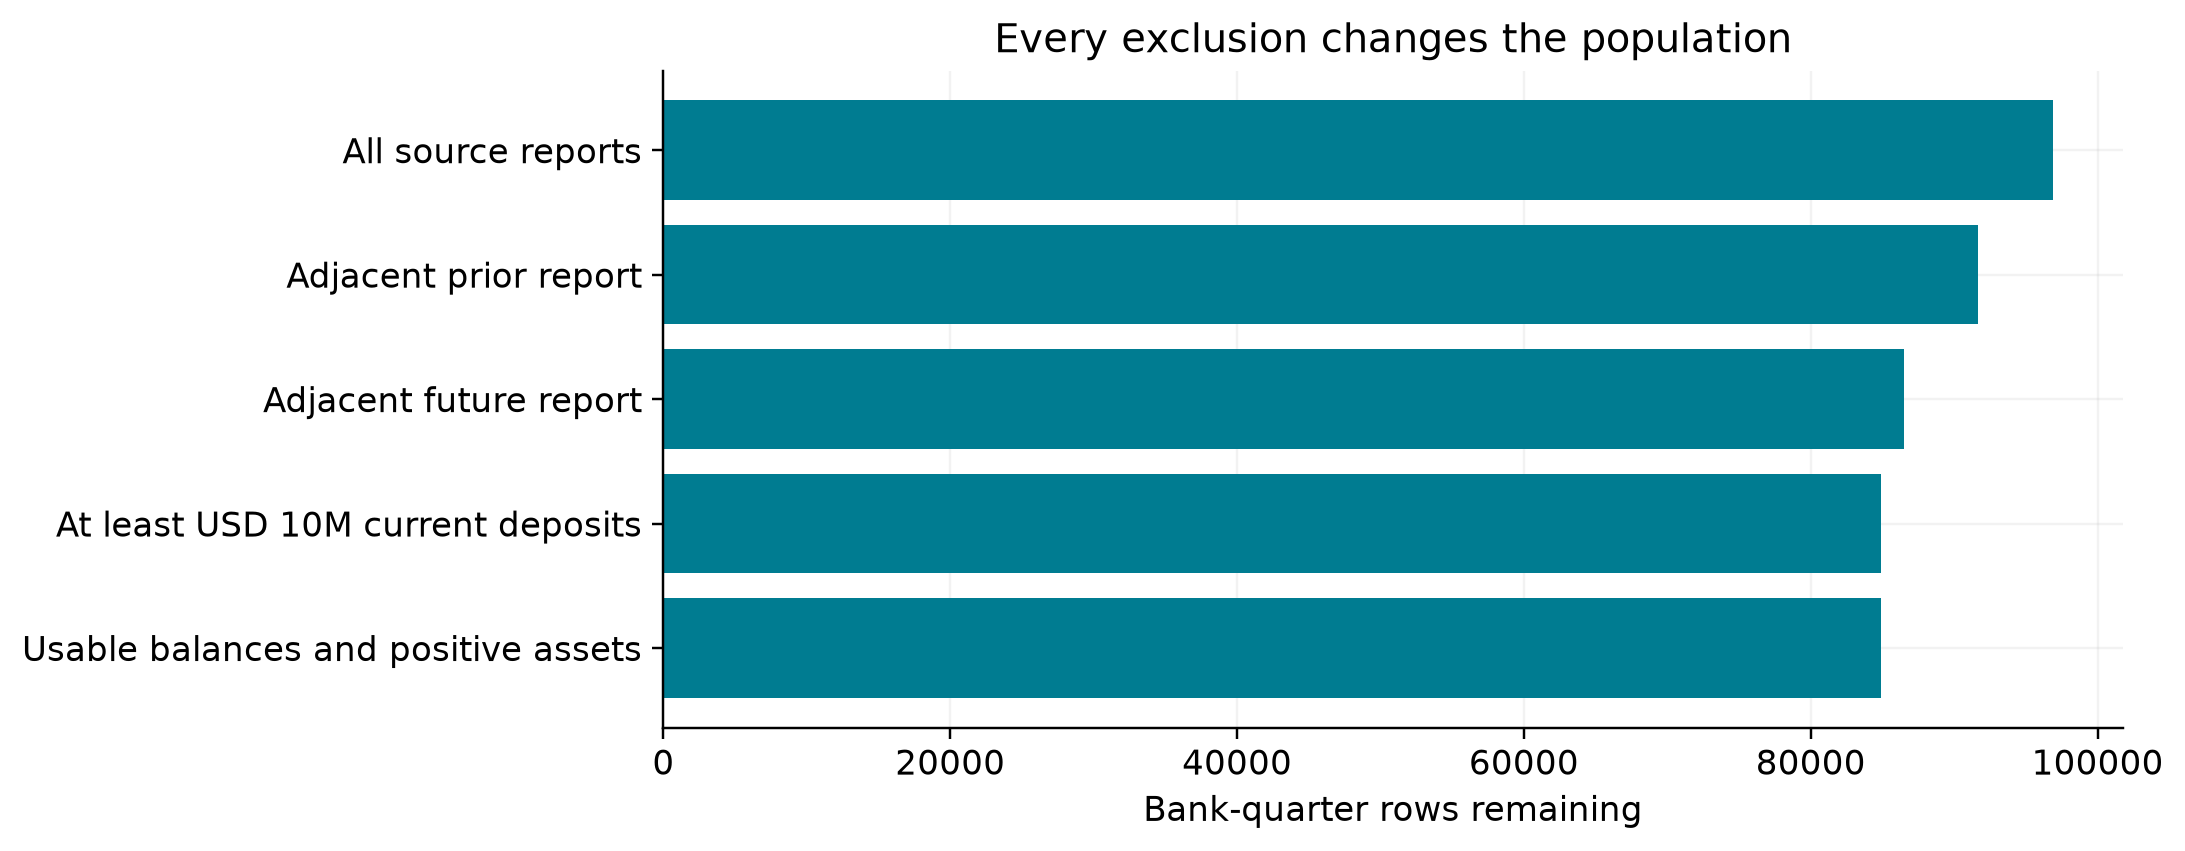

In [8]:
# EXEMPLAR: formula-card
wm_formula_card(title="A USD 20M deposit decline", theme=theme,
    items=[{"label": "Observed target", "fallback": "max(0, 100,000 − 80,000) / 1,000 = 20 million dollars"}],
    subtitle="Illustrative arithmetic; source balances use USD 000.")
panel = reviewed.sort_values(["CERT", "report_date"]).copy()
panel["qnum"] = panel.report_date.dt.to_period("Q").astype("int64")
grouped = panel.groupby("CERT", sort=False)
for new, old, step in [("prior_q", "qnum", 1), ("next_q", "qnum", -1),
        ("prior_deposits", "DEPDOM", 1), ("next_deposits", "DEPDOM", -1),
        ("target_date", "report_date", -1)]:
    panel[new] = grouped[old].shift(step)
conditions = {
    "Adjacent prior report": panel.qnum.sub(panel.prior_q).eq(1),
    "Adjacent future report": panel.next_q.sub(panel.qnum).eq(1),
    "At least USD 10M current deposits": panel.DEPDOM.ge(MIN_DEPOSITS_000),
    "Usable balances and positive assets": panel.prior_deposits.gt(0) & panel.next_deposits.ge(0) & panel.ASSET.gt(0)}
keep = pd.Series(True, index=panel.index)
ledger = [{"Step": "All source reports", "Remaining": len(panel), "Removed at step": 0}]
for name, condition in conditions.items():
    before = int(keep.sum()); keep &= condition
    ledger.append({"Step": name, "Remaining": int(keep.sum()), "Removed at step": before-int(keep.sum())})
eligibility = pd.DataFrame(ledger)
receipt(eligibility, "Sequential eligibility ledger")
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(eligibility.Step[::-1], eligibility.Remaining[::-1], color=BLUE)
ax.set(xlabel="Bank-quarter rows remaining", title="Every exclusion changes the population")
finish(fig, "04_eligibility")
rows = panel.loc[keep].copy()
rows["runoff_m"] = (rows.DEPDOM - rows.next_deposits).clip(lower=0) / 1000
rows["fell"] = rows.runoff_m.gt(0).astype(int)
rows["deposit_m"] = rows.DEPDOM / 1000
assert rows.runoff_m.between(0, rows.deposit_m).all()
assert len(panel)-len(rows) == eligibility["Removed at step"].sum()

### 2.2 · Which dates may teach us, and which dates must wait?

**Short answer.** Training outcomes must precede validation predictor dates; validation outcomes must precede historical-holdout predictor dates.

**ELI8.** You cannot use tomorrow's answer key while claiming to practice today. A gap between practice and the exam makes that boundary easy to see.

**Read the code.** We embargo predictor quarters 2022 Q4 and 2023 Q4. Training ends at 2022 Q3 (outcomes through Q4), validation uses 2023 Q1–Q3, and historical evaluation uses 2024 Q1–Q3. Counts and timeline come from those masks.

**Predict before Run:** Do the same banks appearing in several splits automatically mean leakage?

<details><summary>Check your reasoning</summary>

No: the intended task is predicting later reports for continuing banks. It does create dependence. New-bank generalization would require a separate bank holdout.

</details>

Split,Rows,Share %,First predictor,Last predictor,Last outcome
Train,48472,64.0,2020-06-30,2022-09-30,2022-12-31
Validation,13777,18.2,2023-03-31,2023-09-30,2023-12-31
Historical holdout,13480,17.8,2024-03-31,2024-09-30,2024-12-31


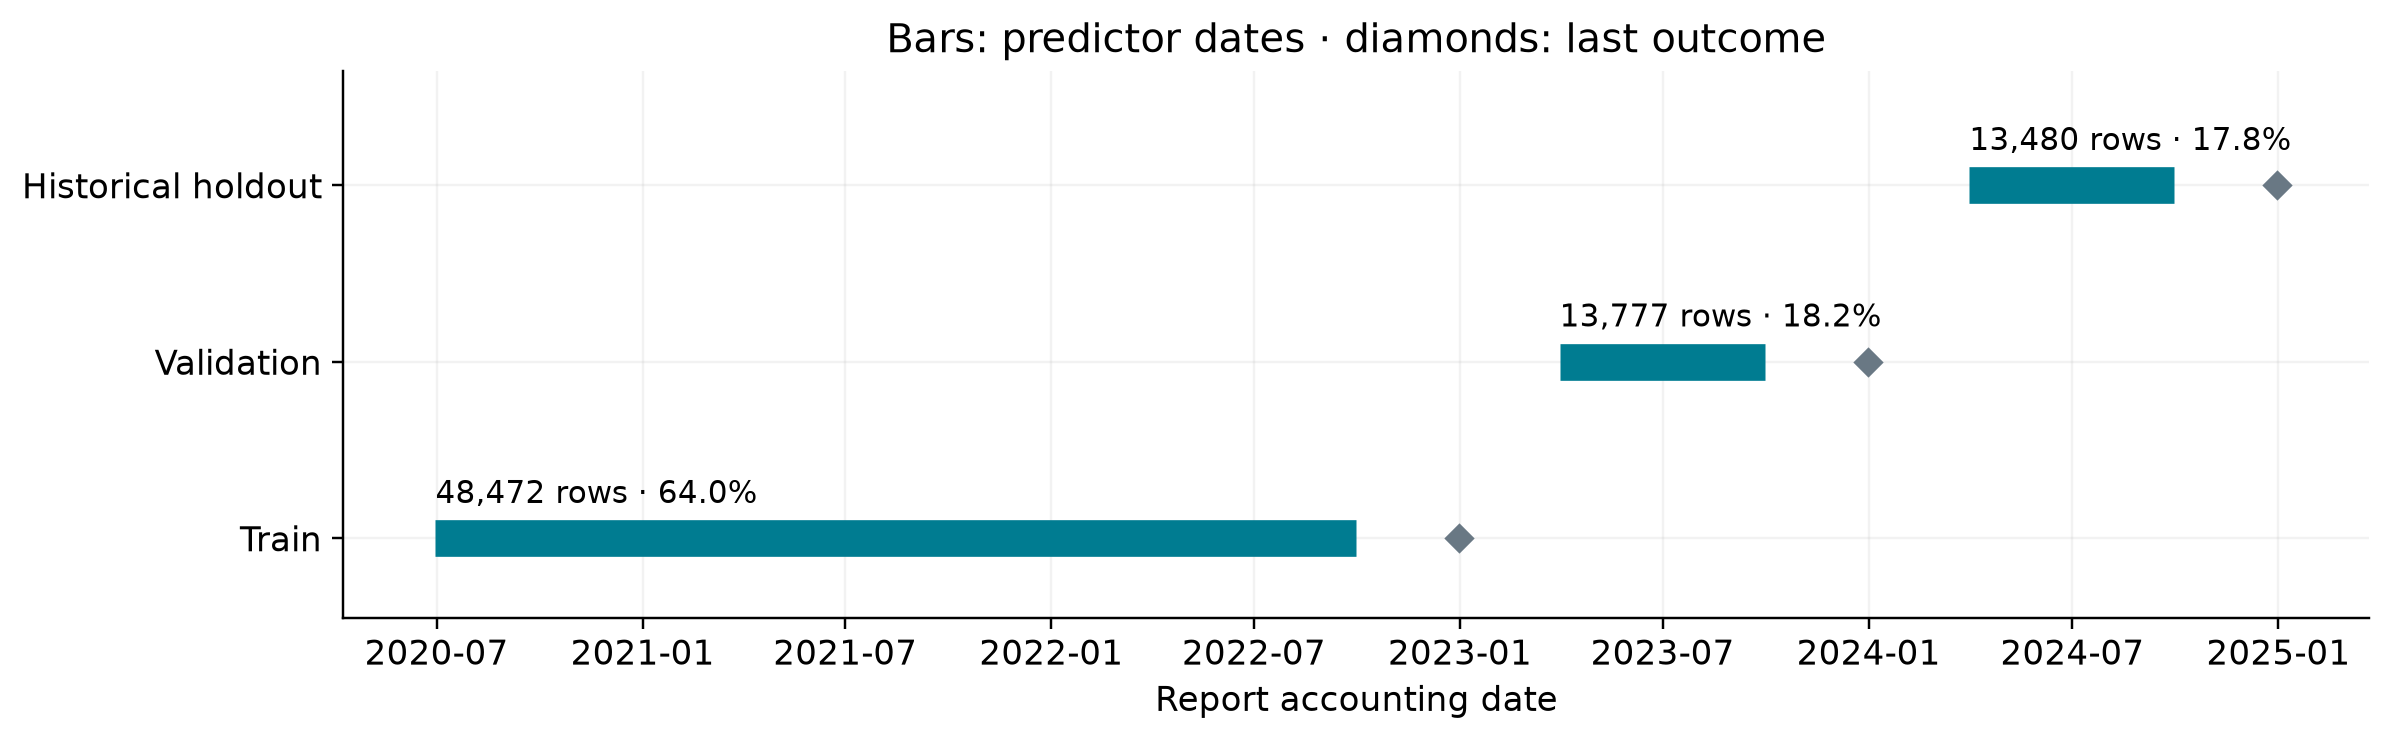

Embargoed eligible rows: 9193
Holdout banks also seen in training: 0.9965875370919881


In [9]:
train = rows.loc[rows.report_date <= "2022-09-30"].copy()
valid = rows.loc[rows.report_date.between("2023-01-01", "2023-09-30")].copy()
test = rows.loc[rows.report_date.between("2024-01-01", "2024-09-30")].copy()
assert train.target_date.max() < valid.report_date.min()
assert valid.target_date.max() < test.report_date.min()
assert len(train) and len(valid) and len(test)
splits = {"Train": train, "Validation": valid, "Historical holdout": test}
split_table = pd.DataFrame([{"Split": name, "Rows": len(f), "Share %": 100*len(f)/sum(map(len, splits.values())),
    "First predictor": str(f.report_date.min().date()), "Last predictor": str(f.report_date.max().date()),
    "Last outcome": str(f.target_date.max().date())} for name, f in splits.items()])
receipt(split_table, "Exact chronological split; shares exclude embargoed rows", {"Share %": "{:.1f}"})
fig, ax = plt.subplots(figsize=(11, 3.5))
for i, (name, f) in enumerate(splits.items()):
    ax.plot([f.report_date.min(), f.report_date.max()], [i,i], lw=12, solid_capstyle="butt", color=BLUE)
    ax.plot(f.target_date.max(), i, "D", color=GREY)
    ax.text(f.report_date.min(), i+0.2, f"{len(f):,} rows · {100*len(f)/sum(map(len,splits.values())):.1f}%", fontsize=10)
ax.set_yticks(range(3), list(splits)); ax.set_ylim(-0.45, 2.65)
ax.set(title="Bars: predictor dates · diamonds: last outcome", xlabel="Report accounting date")
finish(fig, "05_splits")
print("Embargoed eligible rows:", len(rows)-sum(map(len, splits.values())))
print("Holdout banks also seen in training:", test.CERT.isin(train.CERT).mean())
takeaway("The calendar boundary is explicit", "The embargo prevents labels from crossing the next predictor boundary. "
    "Publication lag and revisions remain unresolved because this extract has neither availability timestamps nor historical vintages.")

## 3. What does traditional EDA teach us before fitting?

**Use training rows for discovery.** The source audit above checks integrity across the file. From here, distributions,
relationships, and design choices use training data. We keep the historical outcomes out of those choices.

**Chart plan:** bars for missingness and categories; lines for time; histograms and ECDF for scale; box plots for group overlap;
hexbin for dense relationships; a signed correlation matrix for redundancy; learning curves, PR, ROC, calibration,
confusion matrix, capture curves, and intervals for model evidence. Every view has a question.
Maps are omitted because the decision is bank-level ranking rather than geography. PCA is omitted because seven interpretable
predictors do not create a dimensionality problem. Violin and pie charts would repeat evidence without improving this lesson.

### 3.1 · What is typical, and how far do the tails stretch?

**Short answer.** Read counts, quartiles, median, mean, extremes, and skew together. A mean alone hides concentration.

**ELI8.** One billionaire joining a room can change the average wealth enormously while everyone else's wallet stays the same.

**Read the code.** `describe` gives the numerical receipt in source units (USD thousands). The existing WM profile cards use USD millions, dividing balances by 1,000 for readable numbers. Scroll the card strip horizontally to compare all five fields. The skew threshold is a review cue, never an automatic cleaning rule.

**Predict before Run:** Why show the missing field before complete fields?

<details><summary>Check your reasoning</summary>

Because a distribution drawn from only observed equity needs its missingness boundary nearby.

</details>

In [10]:
# EXEMPLAR: analytical-question
question_card(title="What should we understand before treating a balance as a signal?", theme=theme,
    body="Training-period financial fields: inspect equity missingness first, then scale and skew.")
display(train[numeric_source].describe(percentiles=[.01, .25, .5, .75, .99]).round(2))
eda_contract = wm_build_eda_contract(train[numeric_source], skew_threshold=SKEW_REVIEW)
profile_millions = train[["EQ", "DEPDOM", "ASSET", "LNLSNET", "CHBAL"]].div(1000)
profile_millions.columns = [f"{c} (USD M)" for c in profile_millions.columns]
wm_render_micro_profile_cards(profile_millions, theme=theme,
    columns=list(profile_millions.columns),
    skew_threshold=SKEW_REVIEW, visible_cards=5, max_cards=5)
receipt(eda_contract[["field", "missing", "skew", "status"]],
    "Review |skew| ≥ 1.0; preserve real extremes", {"skew": "{:.2f}"})

,DEPDOM,ASSET,LNLSNET,CHBAL,EQ
count,4.847200e+04,4.847200e+04,4.847200e+04,4.847200e+04,4.831800e+04
mean,3.548005e+06,4.715595e+06,2.265463e+06,6.766997e+05,4.617749e+05
std,4.895233e+07,7.020986e+07,2.748982e+07,1.222714e+07,6.553337e+06
min,1.000000e+04,1.044300e+04,0.000000e+00,0.000000e+00,-6.097000e+04
1%,1.951897e+04,2.411504e+04,7.215390e+03,1.251710e+03,2.227020e+03
25%,1.165028e+05,1.362228e+05,7.214225e+04,1.152100e+04,1.424525e+04
50%,2.596420e+05,3.048010e+05,1.778280e+05,2.874450e+04,3.068450e+04
75%,6.433480e+05,7.587272e+05,4.774475e+05,7.810425e+04,7.737375e+04
99%,4.330549e+07,5.324226e+07,3.073698e+07,6.495458e+06,5.441679e+06
max,2.201118e+09,3.476711e+09,1.098891e+09,7.602590e+08,3.028480e+08


field,missing,skew,status
DEPDOM,0,32.87,CHECK
ASSET,0,33.76,CHECK
LNLSNET,0,29.38,CHECK
CHBAL,0,40.59,CHECK
EQ,154,32.40,CHECK


### 3.2 · Why use a logarithmic axis and an ECDF?

**Short answer.** A log axis reveals multiplicative scale; an ECDF shows the fraction of observations at or below each value without depending on histogram bins.

**ELI8.** The steps 10, 100, and 1,000 are equally spaced on a log ruler because each step multiplies by ten.

**Read the code.** Raw-dollar and log-axis histograms use the same deposits. The ECDF sorts every value and stacks their cumulative share. No rows are trimmed to make the picture prettier.

**Predict before Run:** Does plotting on a log axis change the training data?

<details><summary>Check your reasoning</summary>

No. An axis transform changes the display. A feature transform changes the numbers supplied to a model; we make that choice later.

</details>

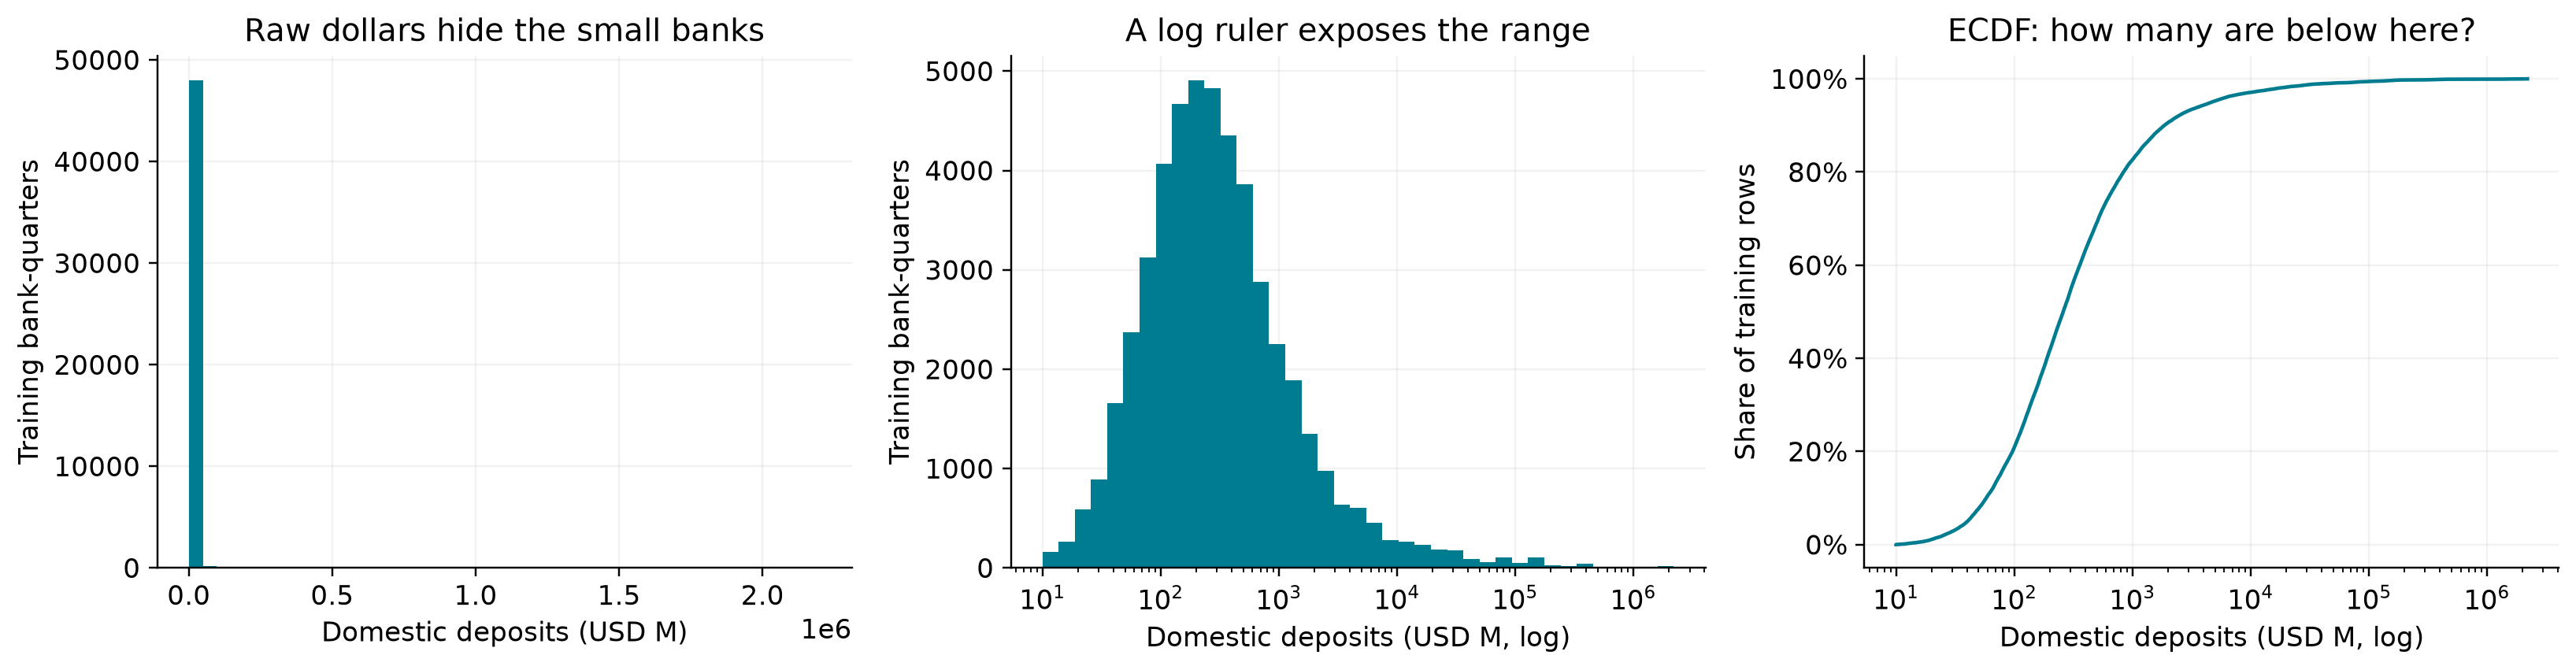

In [11]:
deposits = train.deposit_m.to_numpy()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(deposits, bins=45, color=BLUE)
axes[0].set(title="Raw dollars hide the small banks", xlabel="Domestic deposits (USD M)", ylabel="Training bank-quarters")
bins = np.geomspace(deposits.min(), deposits.max()*1.001, 40)
axes[1].hist(deposits, bins=bins, color=BLUE); axes[1].set_xscale("log")
axes[1].set(title="A log ruler exposes the range", xlabel="Domestic deposits (USD M, log)", ylabel="Training bank-quarters")
ordered = np.sort(deposits)
axes[2].plot(ordered, np.arange(1,len(ordered)+1)/len(ordered), color=BLUE)
axes[2].set_xscale("log"); axes[2].yaxis.set_major_formatter(PercentFormatter(1))
axes[2].set(title="ECDF: how many are below here?", xlabel="Domestic deposits (USD M, log)", ylabel="Share of training rows")
finish(fig, "06_deposit_shapes")
takeaway("The median and mean answer different questions", f"Training median deposits: USD {np.median(deposits):,.1f}M; "
    f"mean: USD {np.mean(deposits):,.1f}M; maximum: USD {np.max(deposits):,.1f}M. Large institutions remain in the study.")

### 3.3 · Which rows are unusual, and should they be removed?

**Short answer.** An IQR flag is a request to inspect. Legitimate financial scale can generate many flags.

**ELI8.** The tallest child being outside the usual range does not mean the ruler is broken.

**Read the code.** The IQR is Q3 minus Q1. We flag values below Q1−1.5×IQR or above Q3+1.5×IQR. We count flags per field and inspect the largest deposit rows with their keys.

**Predict before Run:** What would dropping all deposit flags do to dollar capture?

<details><summary>Check your reasoning</summary>

It would remove part of the very population whose dollar concentration drives the review decision, changing the question.

</details>

Field,Flagged rows,Flagged %
DEPDOM,6168,12.7
ASSET,6244,12.9
LNLSNET,6195,12.8
CHBAL,6023,12.4
EQ,6120,12.6


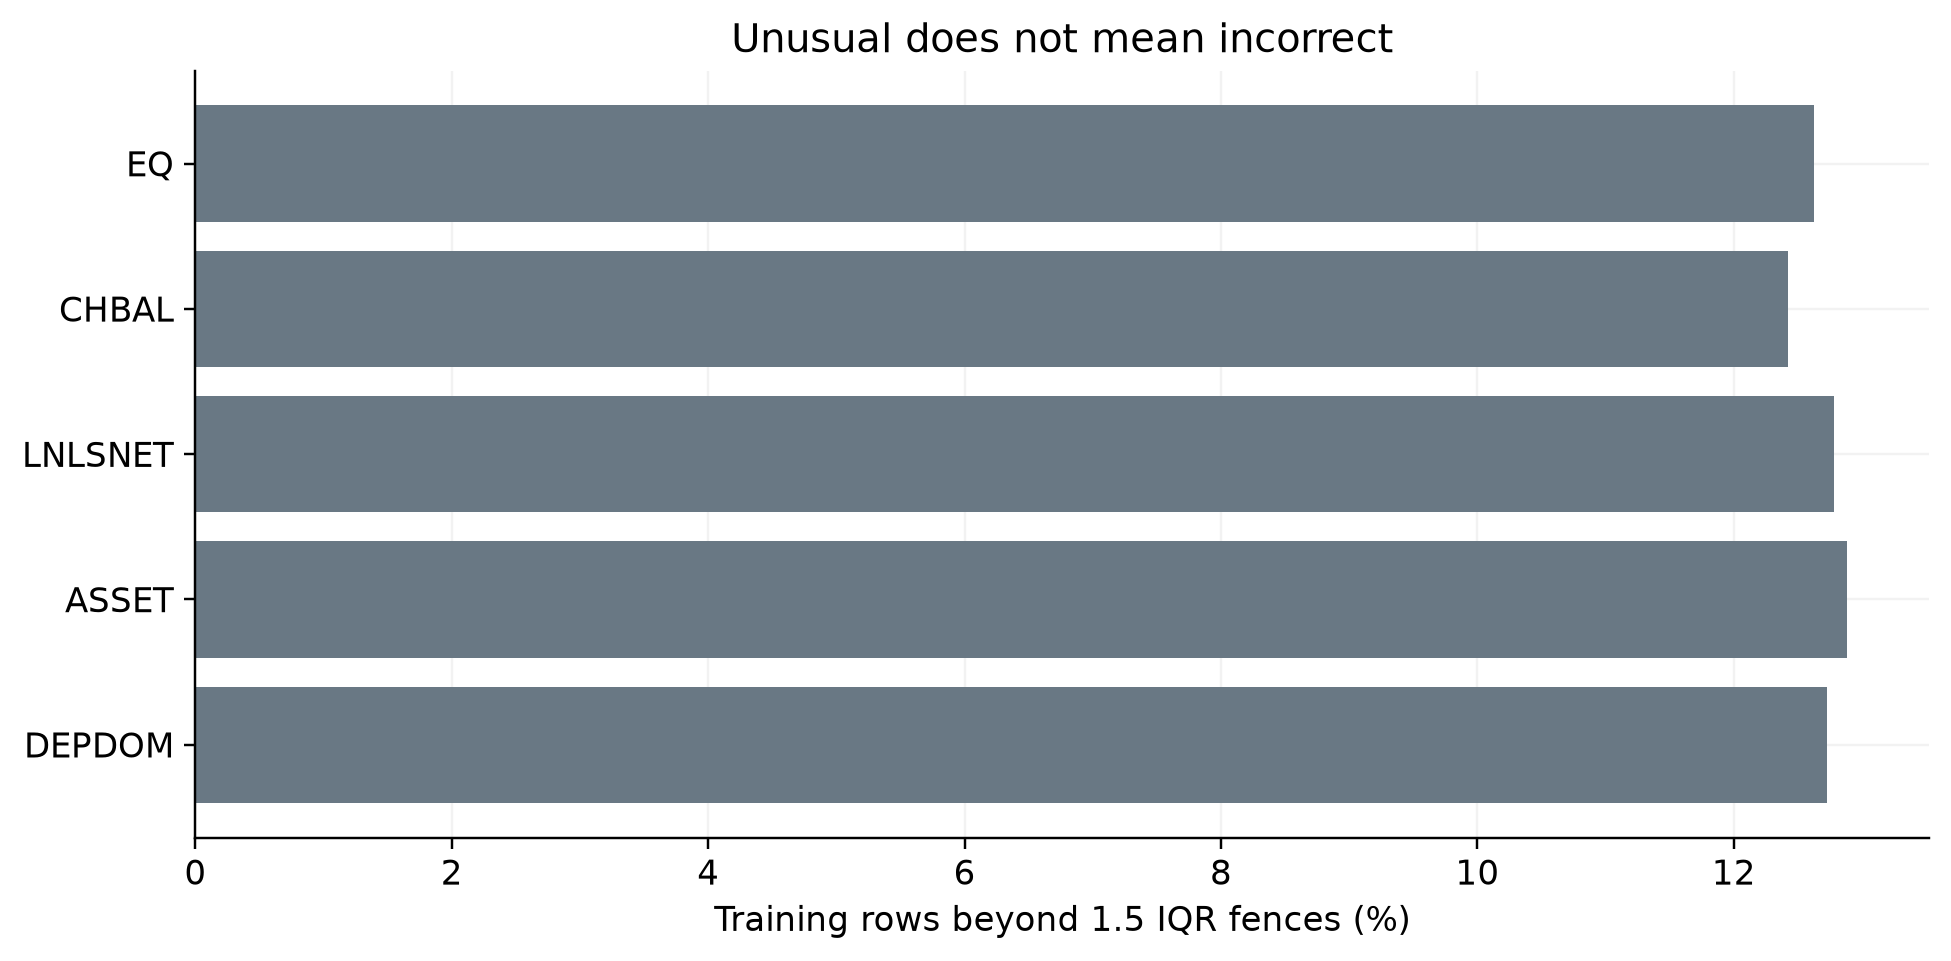

,CERT,NAME,report_date,DEPDOM,ASSET,EQ
44710,628,JPMORGAN CHASE BANK NA,2022-03-31,2201118000,3476711000,299153000.0
39844,628,JPMORGAN CHASE BANK NA,2021-12-31,2152876000,3306982000,302848000.0
49552,628,JPMORGAN CHASE BANK NA,2022-06-30,2128462000,3380824000,297245000.0
34932,628,JPMORGAN CHASE BANK NA,2021-09-30,2091215000,3290398000,296062000.0
54368,628,JPMORGAN CHASE BANK NA,2022-09-30,2079331000,3308575000,297265000.0


In [12]:
outlier_audit = []
for c in numeric_source:
    q1, q3 = train[c].quantile([.25, .75]); iqr = q3-q1
    flags = train[c].lt(q1-1.5*iqr) | train[c].gt(q3+1.5*iqr)
    outlier_audit.append({"Field": c, "Flagged rows": int(flags.sum()), "Flagged %": 100*flags.mean()})
outlier_audit = pd.DataFrame(outlier_audit)
receipt(outlier_audit, "IQR review flags; no automatic deletion", {"Flagged %": "{:.1f}"})
fig, ax = plt.subplots()
ax.barh(outlier_audit.Field, outlier_audit["Flagged %"], color=GREY)
ax.set(xlabel="Training rows beyond 1.5 IQR fences (%)", title="Unusual does not mean incorrect")
finish(fig, "07_outlier_flags")
display(train.nlargest(5,"DEPDOM")[["CERT","NAME","report_date","DEPDOM","ASSET","EQ"]])

### 3.4 · What do the categories tell us about coverage?

**Short answer.** State counts describe institution-report composition, not depositor geography or state risk.

**ELI8.** The return address on a company's letter is not a map of everyone who uses its products.

**Read the code.** The WM category helper counts all training rows, including missing labels. We plot the eight largest categories and combine the rest into Other so the denominator stays complete.

**Predict before Run:** Does the largest state bar mean the most deposit risk?

<details><summary>Check your reasoning</summary>

No. It measures how many training reports carry that state abbreviation.

</details>

State,Reports,Share %
TX,3993,8.24
IL,3872,7.99
MN,2665,5.50
IA,2577,5.32
MO,2261,4.66
KS,2149,4.43
OK,1840,3.80
WI,1741,3.59
Other,27374,56.47


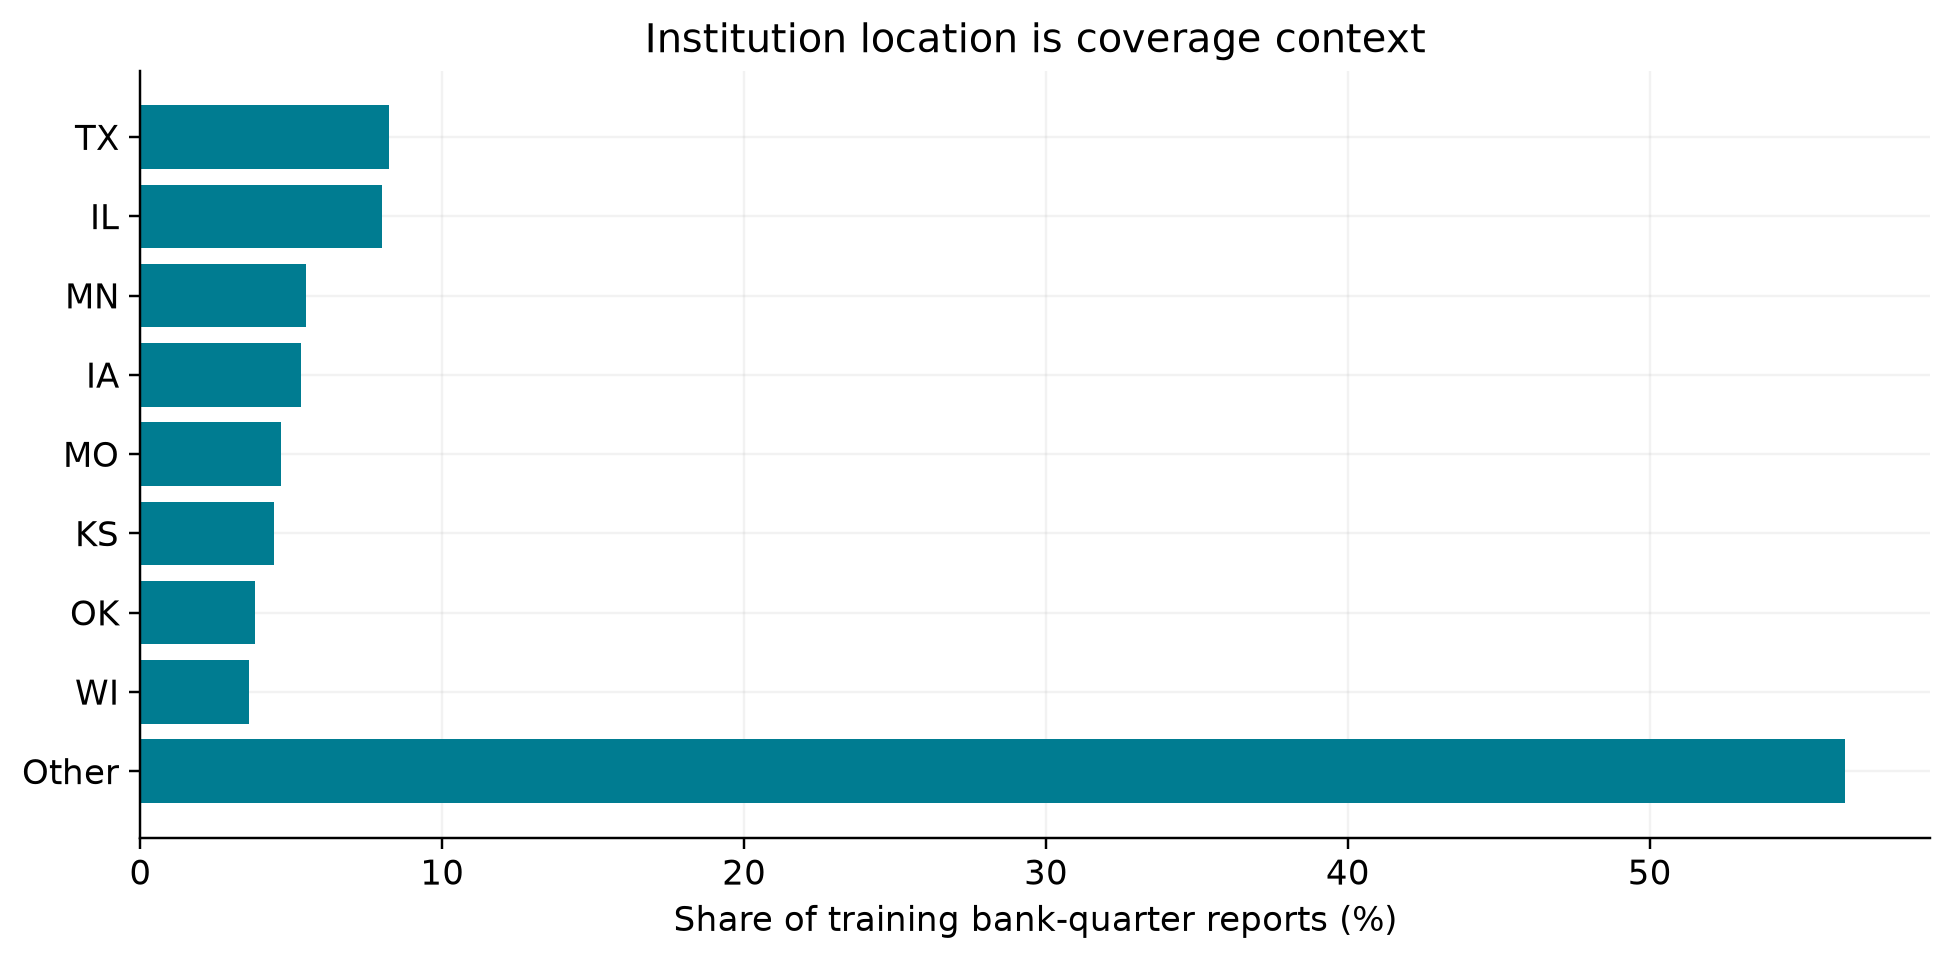

In [13]:
state_table = wm_build_category_share_table(train, ["STALP"], include_missing=True)
top_states = state_table.head(8).copy()
other_count = int(state_table.iloc[8:].rows.sum())
state_plot = pd.DataFrame({"State": list(top_states.category)+["Other"], "Reports": list(top_states.rows)+[other_count]})
state_plot["Share %"] = 100*state_plot.Reports/len(train)
receipt(state_plot, "Training report composition; all rows included", {"Share %": "{:.2f}"})
fig, ax = plt.subplots()
ax.barh(state_plot.State[::-1], state_plot["Share %"][::-1], color=BLUE)
ax.set(xlabel="Share of training bank-quarter reports (%)", title="Institution location is coverage context")
finish(fig, "08_state_composition")

### 3.5 · How often do deposits fall, and how large are those declines?

**Short answer.** Occurrence and amount are separate targets. Zero decline is common; positive amounts vary greatly.

**ELI8.** First ask whether it will rain. Then ask how much rain to expect on a rainy day.

**Read the code.** The prevalence receipt prints numerator and denominator. The positive-only histogram excludes zeros explicitly; a logarithmic axis cannot show zero.

**Predict before Run:** If a model predicts zero for everybody, can its typical error look small?

<details><summary>Check your reasoning</summary>

Yes. With many zeros, a median-seeking model can look good on an all-row typical-error measure while missing important positive amounts.

</details>

Outcome,Rows
No decline,32891
Any decline,15581


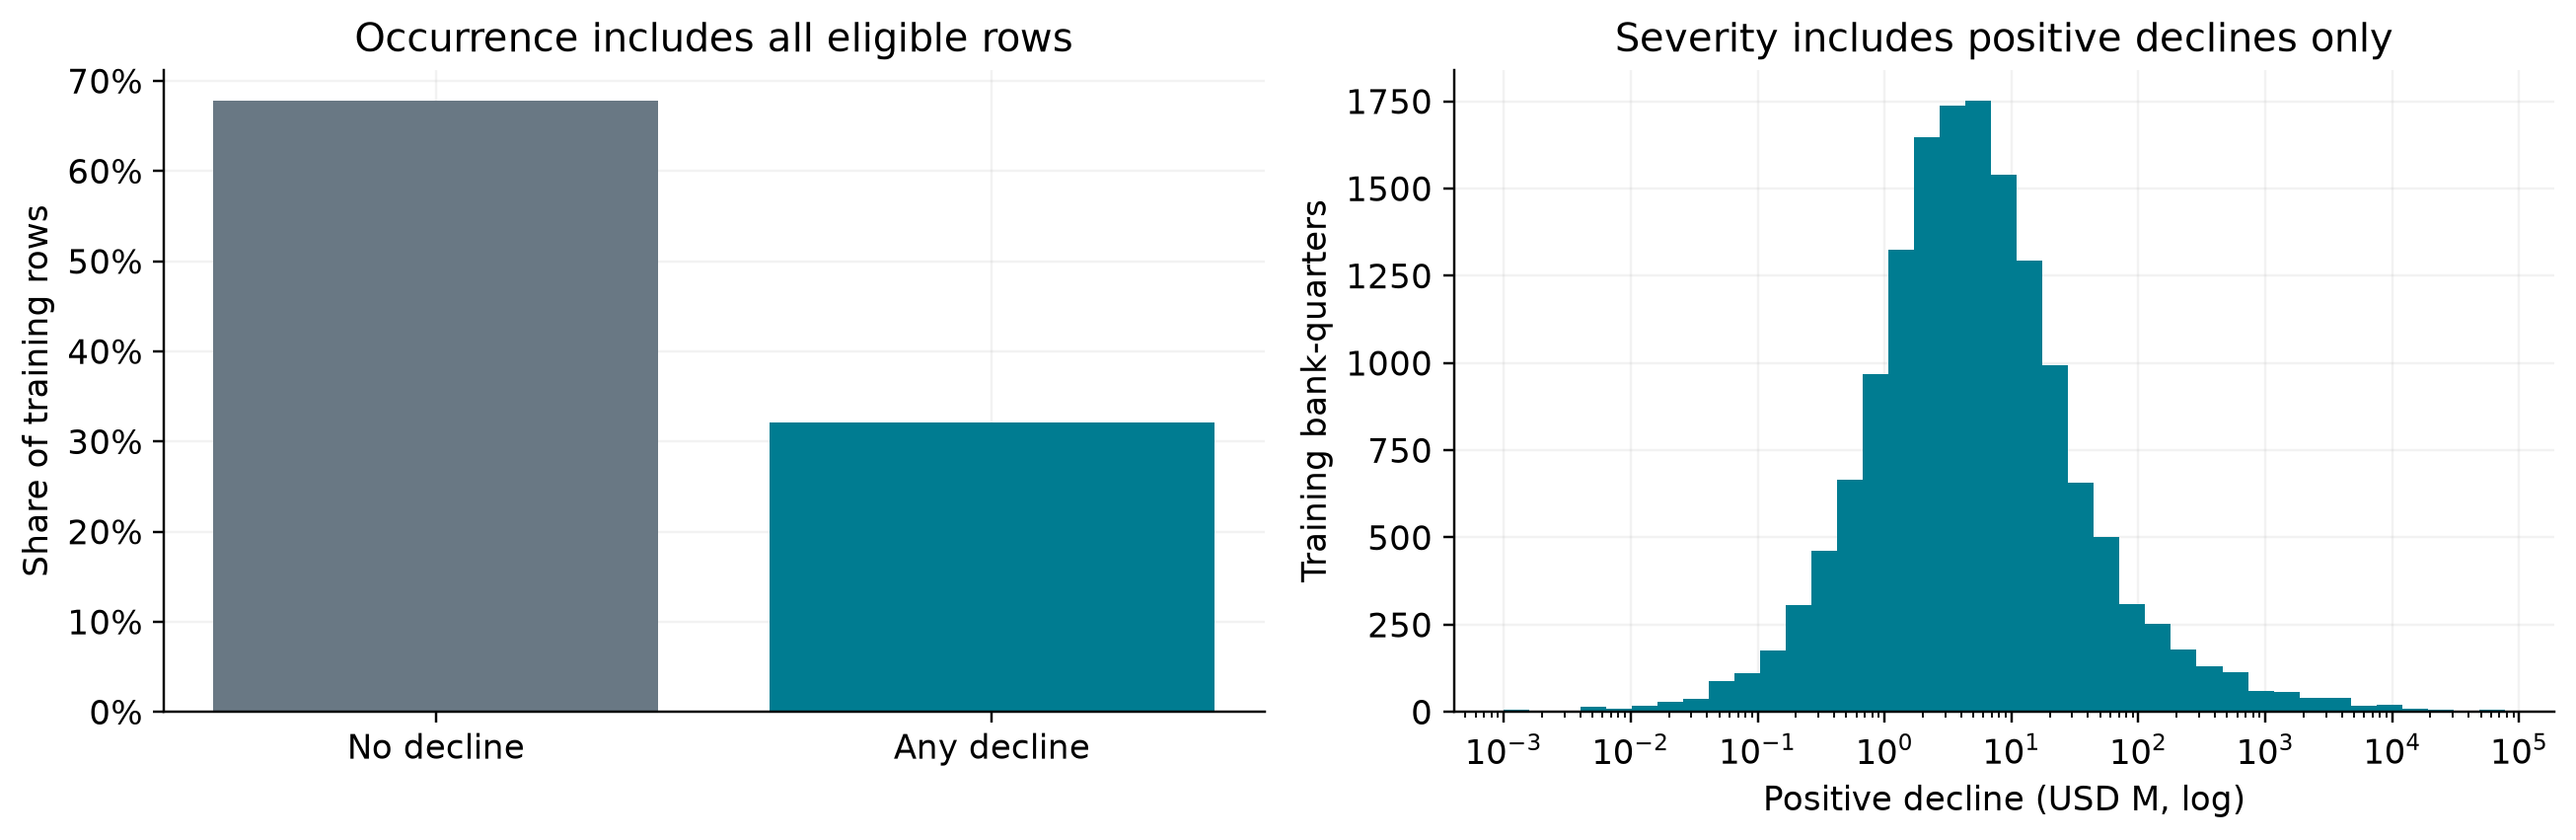

In [14]:
positive_train = train.loc[train.fell.eq(1)]
prevalence = train.fell.mean()
receipt(pd.DataFrame({"Outcome": ["No decline", "Any decline"],
    "Rows": [(train.fell==0).sum(), (train.fell==1).sum()]}), "Training target counts")
fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].bar(["No decline", "Any decline"], [1-prevalence, prevalence], color=[GREY, BLUE])
axes[0].yaxis.set_major_formatter(PercentFormatter(1)); axes[0].set(ylabel="Share of training rows", title="Occurrence includes all eligible rows")
amounts = positive_train.runoff_m.to_numpy()
axes[1].hist(amounts, bins=np.geomspace(amounts.min(), amounts.max()*1.001, 40), color=BLUE)
axes[1].set_xscale("log"); axes[1].set(title="Severity includes positive declines only", xlabel="Positive decline (USD M, log)", ylabel="Training bank-quarters")
finish(fig, "09_target")
takeaway("Keep probability and severity separate", f"{len(positive_train):,} of {len(train):,} training rows declined. "
    f"Median positive decline: USD {np.median(amounts):,.2f}M; 99th percentile: USD {np.quantile(amounts,.99):,.2f}M.", metric=f"{prevalence:.1%} declined")

### 3.6 · Do frequency and dollars tell the same story over time?

**Short answer.** A large number of small declines and a small number of large declines can create different time patterns.

**ELI8.** Ten children dropping one marble each and one child dropping a whole jar are different clean-up jobs.

**Read the code.** Quarterly rates divide decline cases by eligible rows. Dollar totals add positive changes only. These totals are repeated quarterly changes, not a unique cumulative bank loss.

**Predict before Run:** Can we average these rates across quarters without thinking?

<details><summary>Check your reasoning</summary>

An equal-quarter average answers an average-quarter question. A row-weighted rate answers an average-observation question. State which one you use.

</details>

report_date,Rows,Declines,Dollars_M,Rate
2020-06-30 00:00:00,5006,1632,"117,342.0",32.6%
2020-09-30 00:00:00,4975,909,"52,658.5",18.3%
2020-12-31 00:00:00,4948,419,"35,258.1",8.5%
2021-03-31 00:00:00,4923,1680,"102,281.0",34.1%
2021-06-30 00:00:00,4887,1499,"55,866.8",30.7%
2021-09-30 00:00:00,4816,1114,"89,939.9",23.1%
2021-12-31 00:00:00,4775,1151,"133,311.5",24.1%
2022-03-31 00:00:00,4745,2282,"432,767.9",48.1%
2022-06-30 00:00:00,4718,2342,"349,531.6",49.6%
2022-09-30 00:00:00,4679,2553,"305,796.0",54.6%


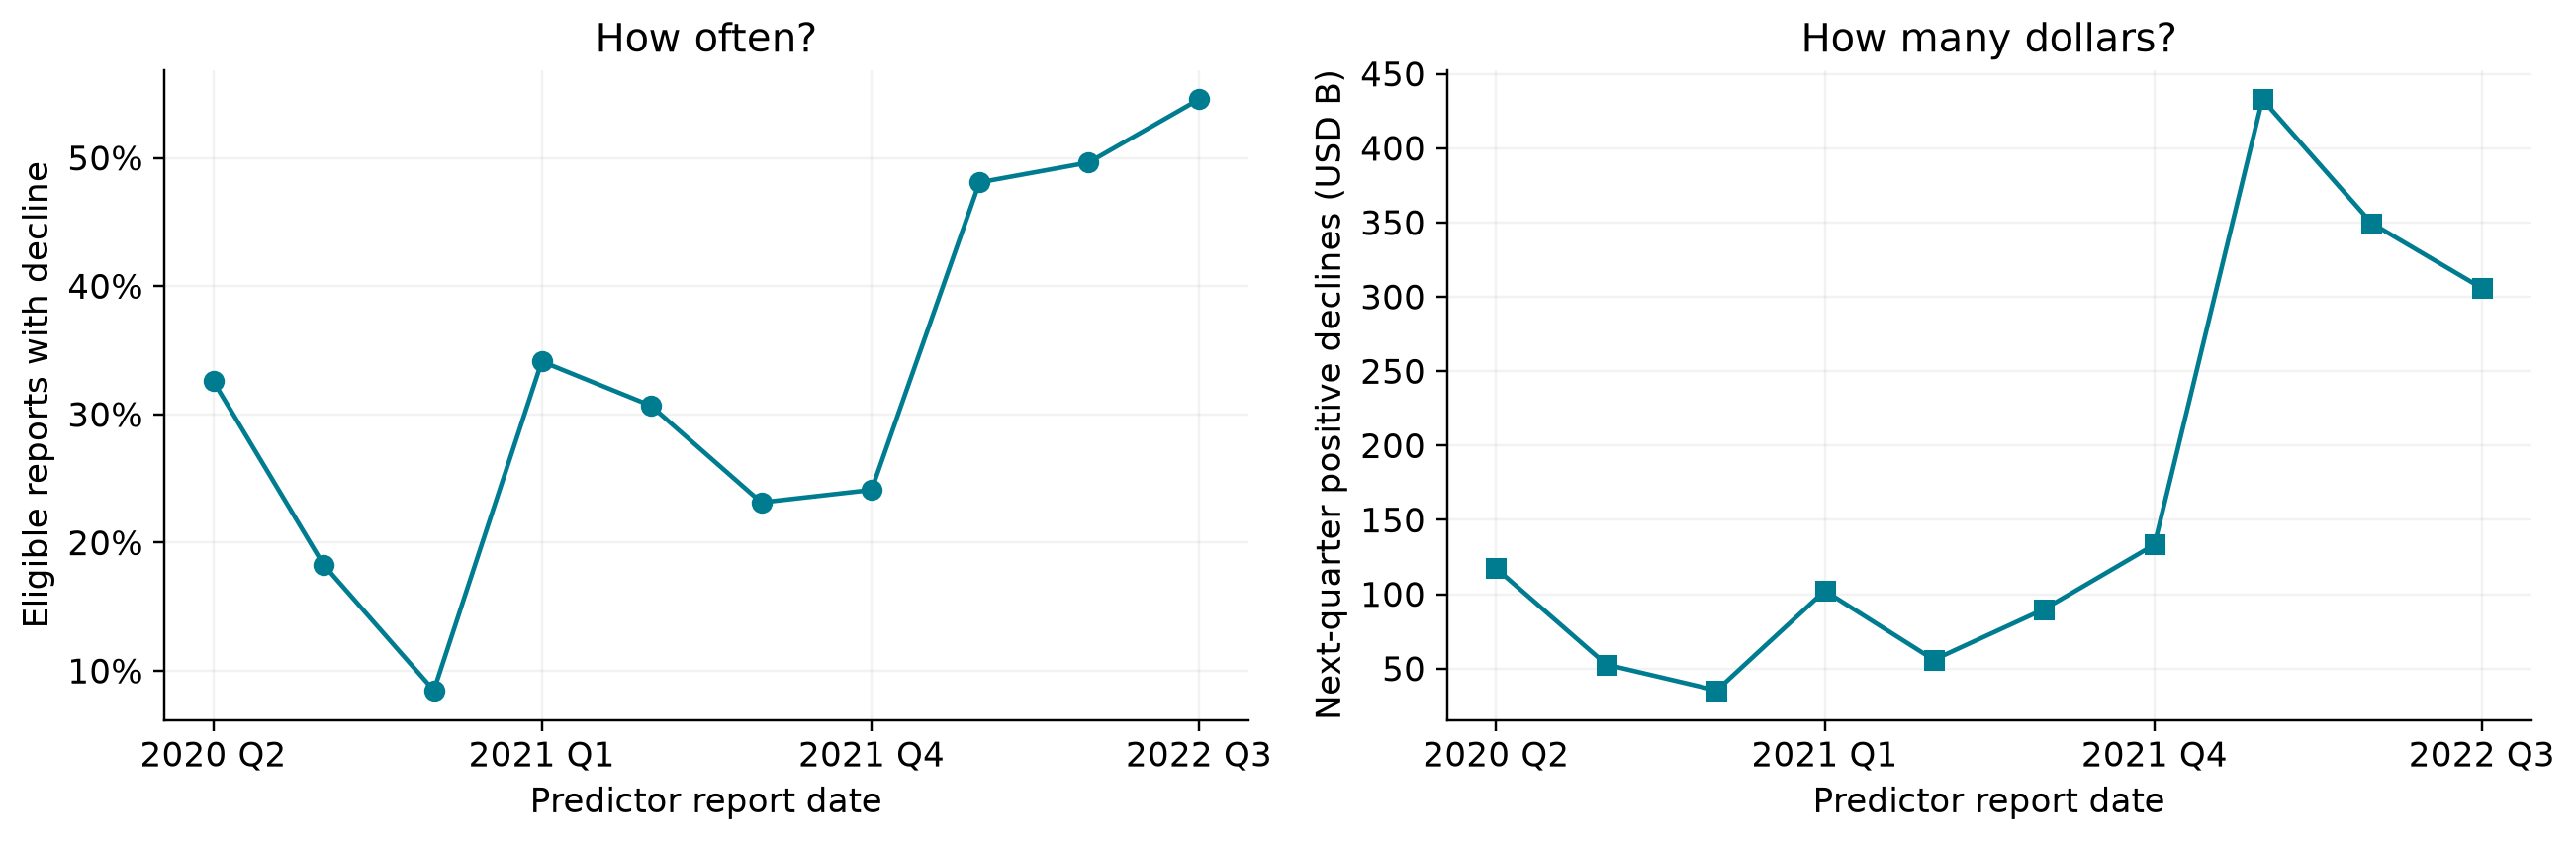

In [15]:
time_eda = train.groupby("report_date").agg(Rows=("fell","size"), Declines=("fell","sum"), Dollars_M=("runoff_m","sum"))
time_eda["Rate"] = time_eda.Declines/time_eda.Rows
receipt(time_eda.reset_index(), "Quarterly target evidence; training only", {"Rate":"{:.1%}", "Dollars_M":"{:,.1f}"})
fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].plot(time_eda.index, time_eda.Rate, "o-", color=BLUE)
axes[0].yaxis.set_major_formatter(PercentFormatter(1)); axes[0].set(title="How often?",ylabel="Eligible reports with decline",xlabel="Predictor report date")
axes[1].plot(time_eda.index, time_eda.Dollars_M/1000, "s-", color=BLUE)
axes[1].set(title="How many dollars?",ylabel="Next-quarter positive declines (USD B)",xlabel="Predictor report date")
for ax in axes:
    ticks = time_eda.index[::3]
    ax.set_xticks(ticks, [f"{d.year} Q{d.quarter}" for d in ticks])
finish(fig, "10_target_time")

### 3.7 · Which features are available before the answer?

**Short answer.** Use current balances, a prior-quarter change, and calendar position. Keep next deposits and the target out of the predictor matrix.

**ELI8.** A weather forecast can use today's clouds. It cannot use tomorrow's measured rainfall as a clue.

**Read the code.** Logs compress size; ratios compare banks on a common scale; asinh compresses positive and negative growth. Sine and cosine put Q4 near Q1 on a yearly clock. All formulas are deterministic, so they learn no statistics from future rows.

**Predict before Run:** Why use two calendar columns instead of quarter number 1–4?

<details><summary>Check your reasoning</summary>

A circle represents seasonality without pretending Q4 and Q1 are far apart. It does not prove seasonality helps; the no-calendar experiment tests that.

</details>

In [16]:
def add_features(frame):
    f = frame.copy()
    f["log_deposits"] = np.log1p(f.deposit_m)
    f["cash_ratio"] = f.CHBAL/f.ASSET
    f["loan_ratio"] = f.LNLSNET/f.ASSET
    f["equity_ratio"] = f.EQ/f.ASSET
    f["prior_growth"] = (f.DEPDOM-f.prior_deposits)/f.prior_deposits
    f["growth_asinh"] = np.arcsinh(f.prior_growth)
    angle = 2*np.pi*(f.report_date.dt.quarter-1)/4
    f["quarter_sin"], f["quarter_cos"] = np.sin(angle), np.cos(angle)
    return f
train, valid, test = [add_features(f) for f in [train, valid, test]]
FEATURES = ["log_deposits","cash_ratio","loan_ratio","equity_ratio","growth_asinh","quarter_sin","quarter_cos"]
feature_reasons = ["Compress bank size; preserve every bank", "Cash and due balances / assets", "Net lending / assets",
    "Capital / assets; retain negative values", "Signed prior growth; compress extremes", "Yearly calendar position", "Yearly calendar position"]
manifest = wm_validate_feature_manifest(train[FEATURES], [
    FeatureDecision(field=c, role="numeric", model_use="candidate", reason=r) for c,r in zip(FEATURES,feature_reasons)] + [
    FeatureDecision(field=c, role="future or identity", model_use="exclude", reason="Not a permitted predictor")
    for c in ["CERT","NAME","next_deposits","runoff_m","fell","target_date"]])
receipt(manifest.rename(columns={"reason":"Reason"}), "Predictor allowlist and leakage exclusions")

field,role,model use,Reason
log_deposits,numeric,candidate,Compress bank size; preserve every bank
cash_ratio,numeric,candidate,Cash and due balances / assets
loan_ratio,numeric,candidate,Net lending / assets
equity_ratio,numeric,candidate,Capital / assets; retain negative values
growth_asinh,numeric,candidate,Signed prior growth; compress extremes
quarter_sin,numeric,candidate,Yearly calendar position
quarter_cos,numeric,candidate,Yearly calendar position
CERT,future or identity,exclude,Not a permitted predictor
NAME,future or identity,exclude,Not a permitted predictor
next_deposits,future or identity,exclude,Not a permitted predictor


### 3.8 · Does having more cash separate banks that later decline?

**Short answer.** Compare distributions and denominators before claiming a relationship. Overlap matters as much as a difference in medians.

**ELI8.** Two classes can have different average heights and still contain many children of the same height.

**Read the code.** Box plots compare cash ratios by future outcome in training. Quintiles create five equally populated groups where possible. Their rates are descriptive associations, not causal effects.

**Predict before Run:** Would a higher decline rate in the cash-rich group prove cash causes declines?

<details><summary>Check your reasoning</summary>

No. Bank size, business model, period, and other factors may explain the association.

</details>

fell,Rows,Median_cash_ratio
0,32891,0.096
1,15581,0.108


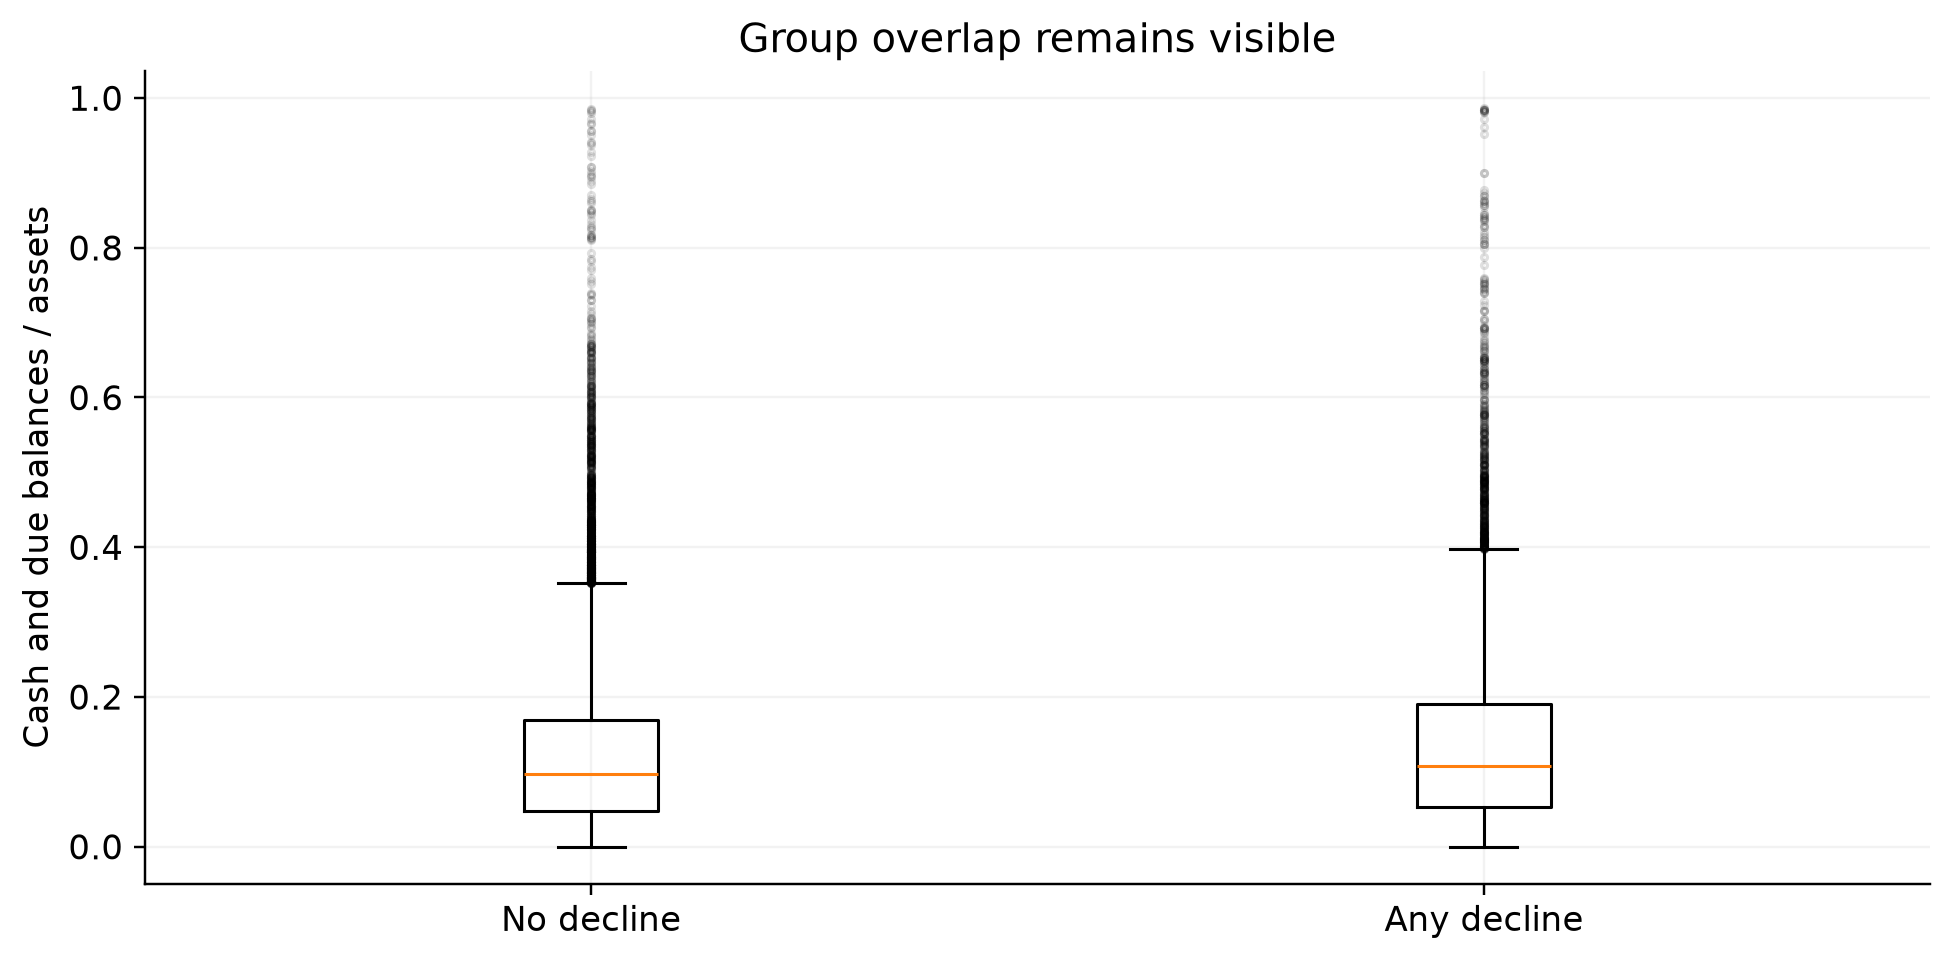

cash_ratio,Rows,Declines,Rate
"(-0.001, 0.0404]",9695,2963,30.6%
"(0.0404, 0.0782]",9694,2876,29.7%
"(0.0782, 0.126]",9694,2996,30.9%
"(0.126, 0.199]",9694,3141,32.4%
"(0.199, 0.987]",9695,3605,37.2%


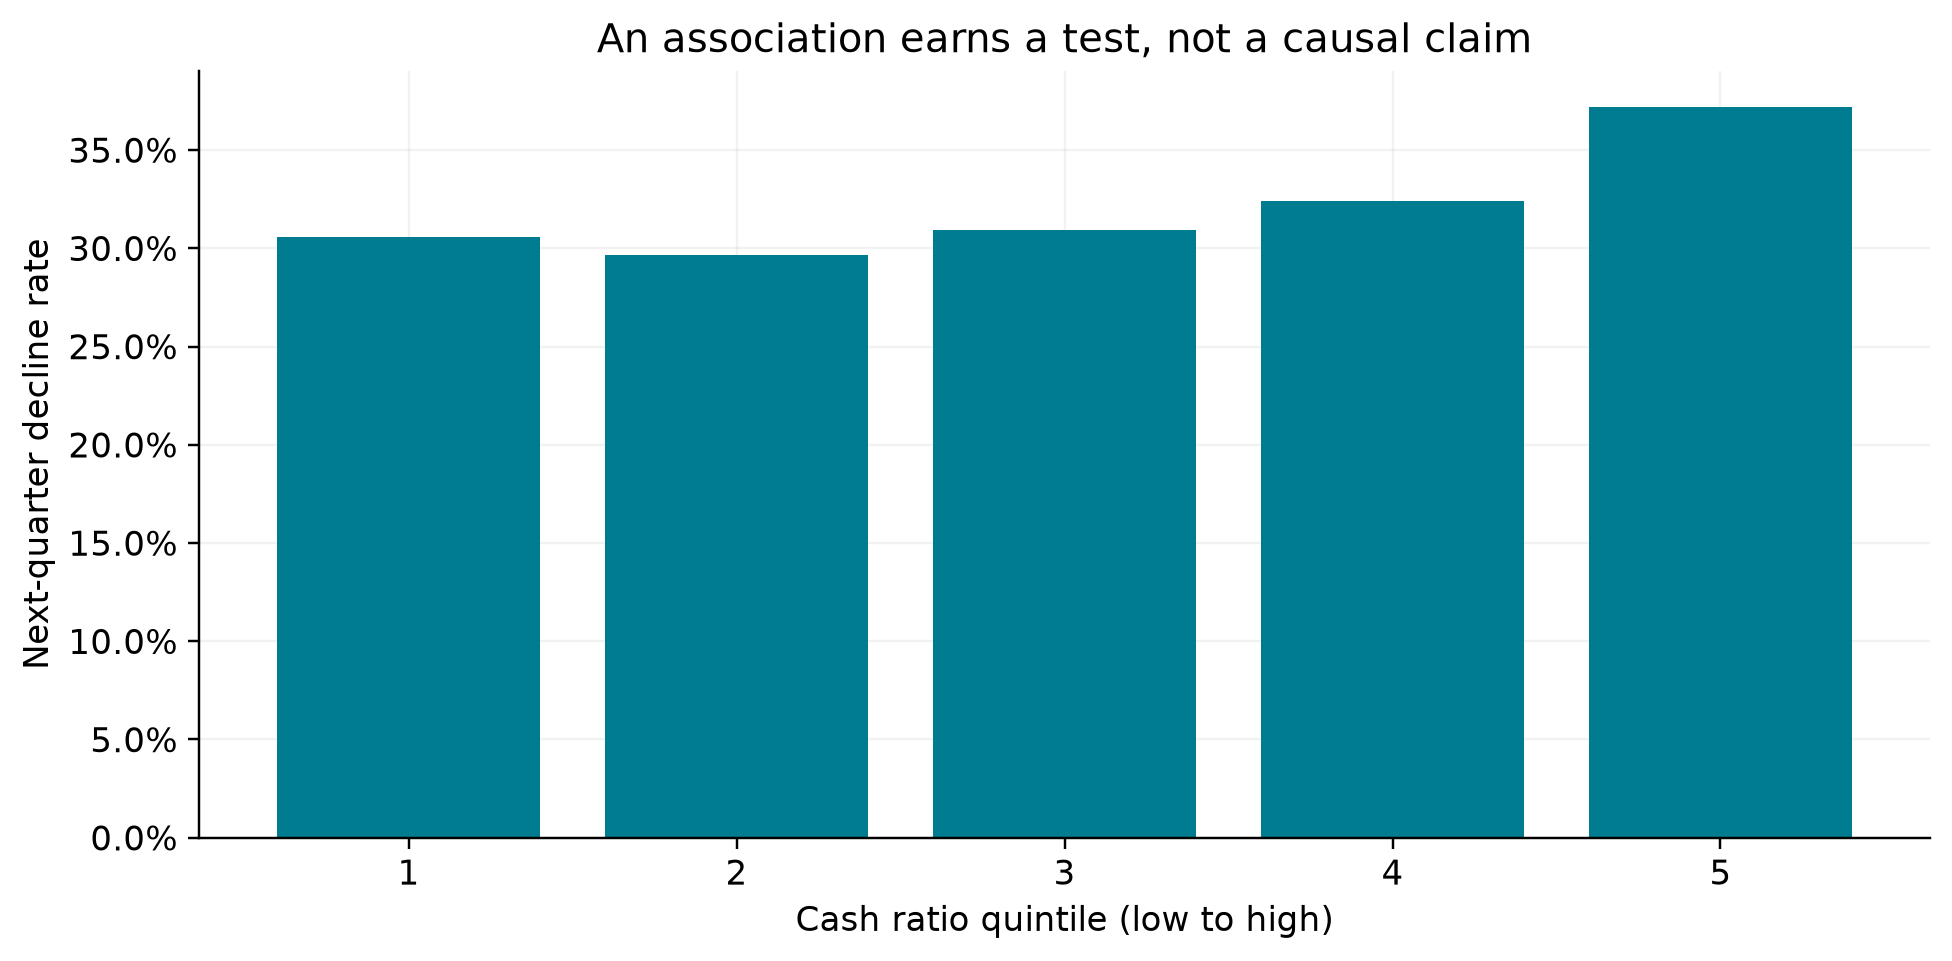

In [17]:
cash_group = train.groupby("fell").agg(Rows=("CERT","size"), Median_cash_ratio=("cash_ratio","median"))
receipt(cash_group.reset_index(), "Cash ratio by observed next-quarter outcome", {"Median_cash_ratio":"{:.3f}"})
fig, ax = plt.subplots()
ax.boxplot([train.loc[train.fell.eq(i),"cash_ratio"].dropna() for i in [0,1]],
    tick_labels=["No decline", "Any decline"], showfliers=True, flierprops={"markersize":2,"alpha":.12})
ax.set(title="Group overlap remains visible", ylabel="Cash and due balances / assets")
finish(fig, "11_cash_by_target")
cash_bins = pd.qcut(train.cash_ratio, 5, duplicates="drop")
cash_rates = train.groupby(cash_bins, observed=True).agg(Rows=("fell","size"), Declines=("fell","sum"))
cash_rates["Rate"] = cash_rates.Declines/cash_rates.Rows
receipt(cash_rates.reset_index().assign(cash_ratio=lambda d: d.cash_ratio.astype(str)),
    "Cash quintiles are descriptive training groups", {"Rate":"{:.1%}"})
fig, ax = plt.subplots()
ax.bar(range(1,len(cash_rates)+1), cash_rates.Rate, color=BLUE)
ax.yaxis.set_major_formatter(PercentFormatter(1)); ax.set(xlabel="Cash ratio quintile (low to high)",ylabel="Next-quarter decline rate",title="An association earns a test, not a causal claim")
finish(fig, "12_cash_quintiles")

### 3.9 · Are size and severity related, and which inputs overlap?

**Short answer.** Inspect a dense scatter and rank correlations. Shared movement suggests redundancy, not automatic deletion.

**ELI8.** Two thermometers in the same room may tell similar stories. That does not mean one is broken.

**Read the code.** Hexagons summarize dense positive-decline observations. Spearman correlation compares ranks, reducing sensitivity to giant values; the matrix has a fixed −1 to +1 scale. Calendar columns are omitted from this financial-redundancy view.

**Predict before Run:** Can a weak pairwise correlation prove a feature is useless to a network?

<details><summary>Check your reasoning</summary>

No. A feature can matter through nonlinear relationships or interactions with other inputs.

</details>

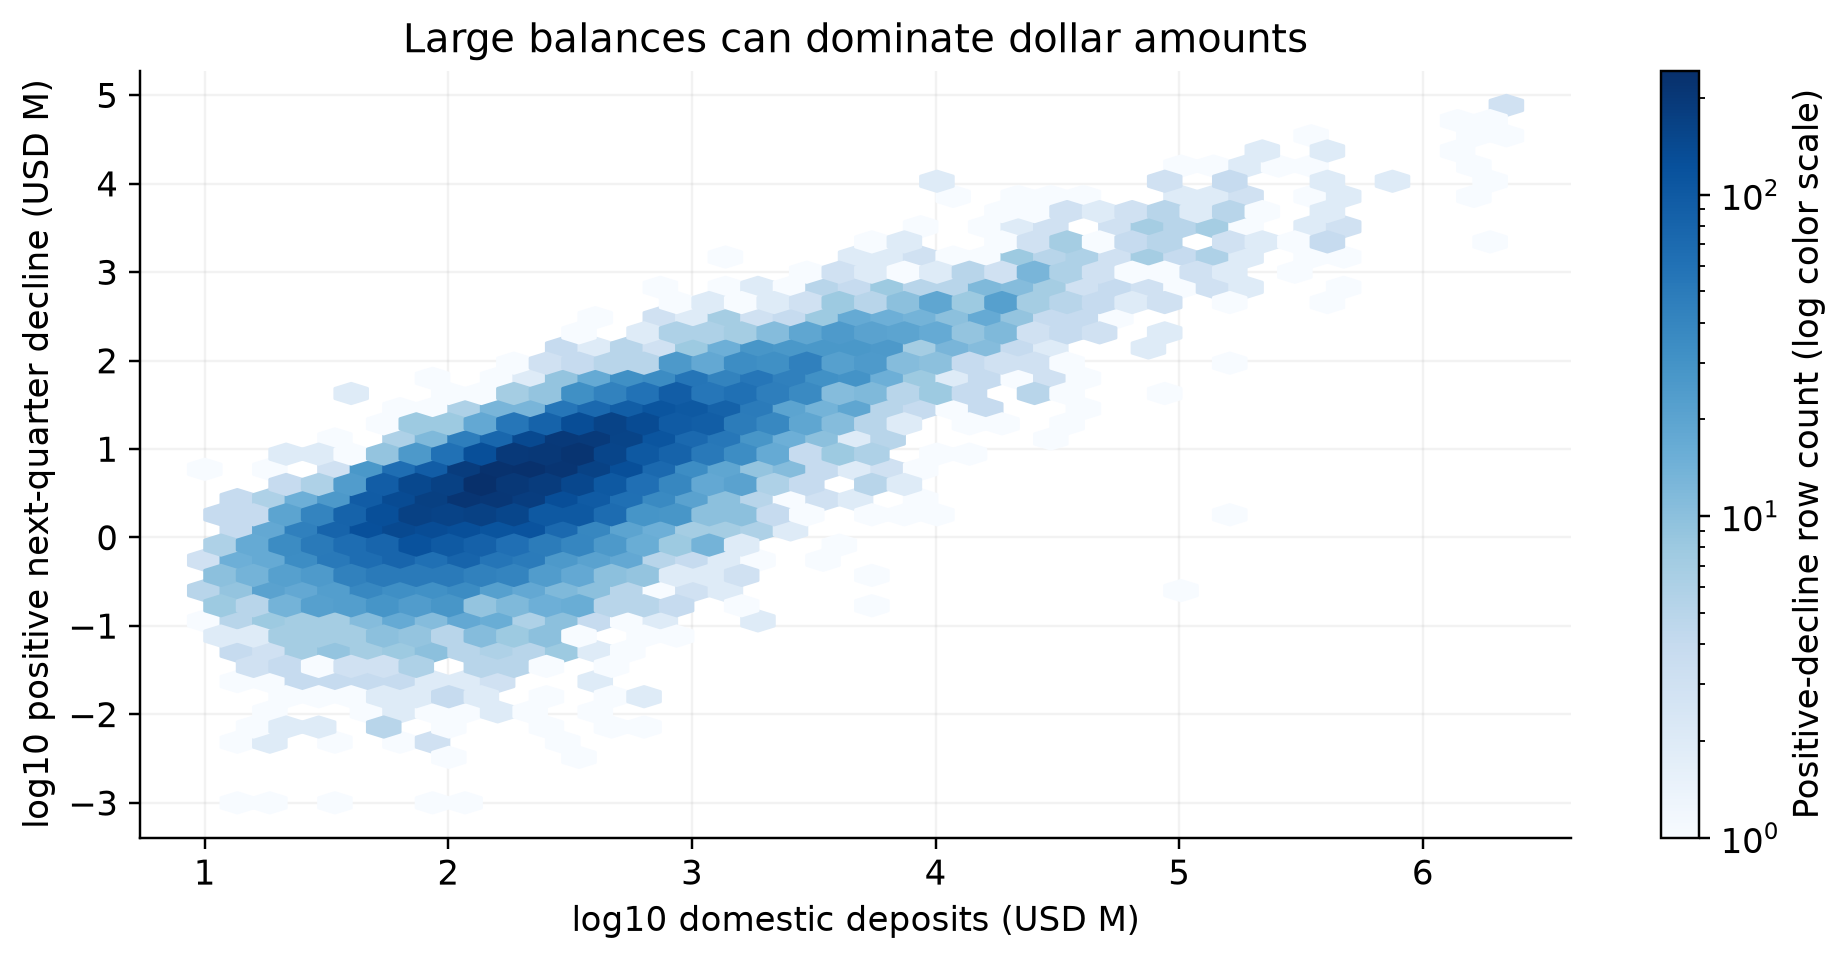

field A,field B,correlation,status
log_deposits,loan_ratio,0.250,PASS
cash_ratio,loan_ratio,-0.245,PASS
log_deposits,cash_ratio,-0.190,PASS
log_deposits,equity_ratio,-0.165,PASS
cash_ratio,growth_asinh,0.119,PASS
log_deposits,growth_asinh,0.058,PASS
equity_ratio,growth_asinh,-0.045,PASS
cash_ratio,equity_ratio,0.041,PASS
loan_ratio,equity_ratio,0.030,PASS
loan_ratio,growth_asinh,0.006,PASS


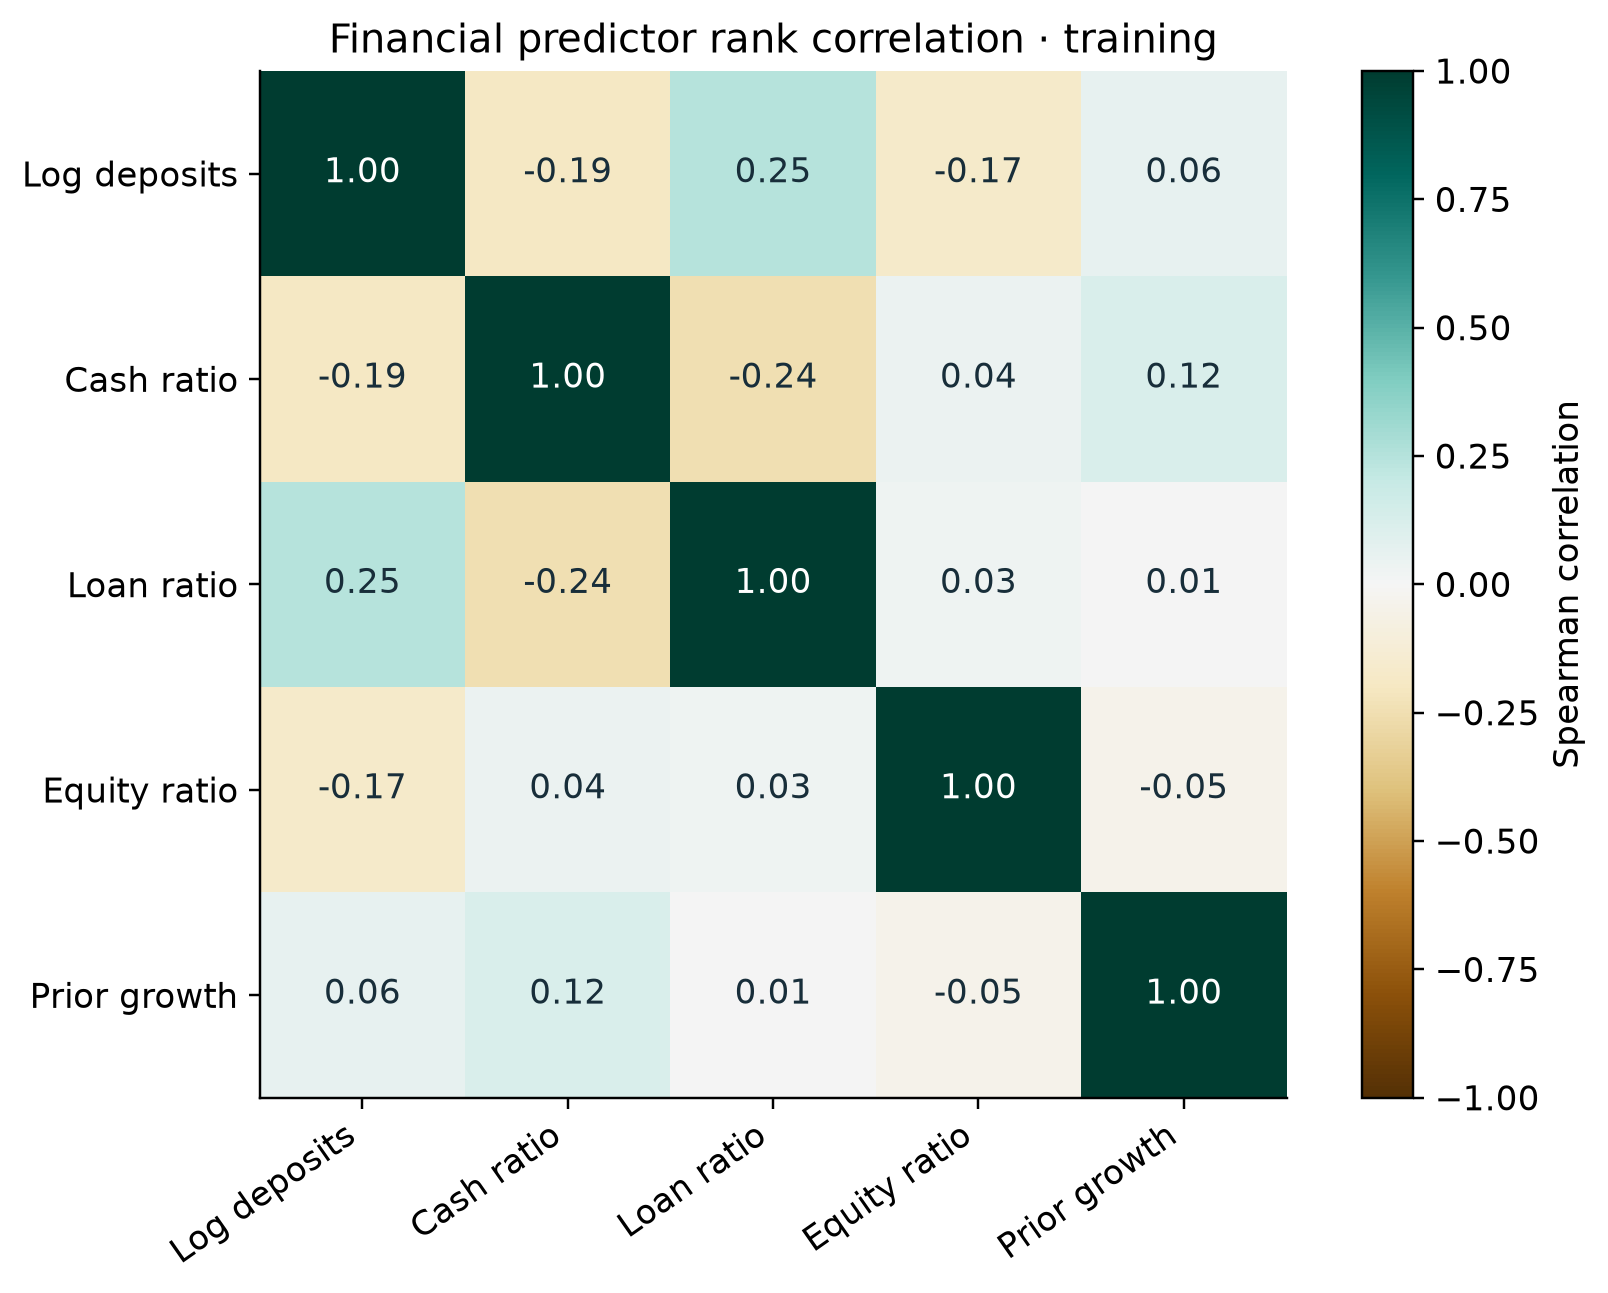

In [18]:
fig, ax = plt.subplots()
h = ax.hexbin(np.log10(positive_train.deposit_m), np.log10(positive_train.runoff_m), gridsize=40, mincnt=1, bins="log", cmap="Blues")
ax.set(xlabel="log10 domestic deposits (USD M)",ylabel="log10 positive next-quarter decline (USD M)",title="Large balances can dominate dollar amounts")
fig.colorbar(h, ax=ax, label="Positive-decline row count (log color scale)")
finish(fig, "13_size_severity")
financial = FEATURES[:5]
corr = train[financial].corr(method="spearman")
clues = wm_build_correlation_clues(train[financial], method="spearman", threshold=CORR_REVIEW, top_n=10)
receipt(clues[["field A","field B","correlation","status"]], "Ranked correlation clues; review |r| ≥ 0.8", {"correlation":"{:.3f}"})
fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="BrBG")
labels = ["Log deposits", "Cash ratio", "Loan ratio", "Equity ratio", "Prior growth"]
ax.set_xticks(range(5),labels,rotation=35,ha="right"); ax.set_yticks(range(5),labels)
for i in range(5):
    for j in range(5):
        ax.text(j,i,f"{corr.iloc[i,j]:.2f}",ha="center",va="center",color="white" if abs(corr.iloc[i,j])>.65 else INK)
ax.grid(False); ax.set_title("Financial predictor rank correlation · training")
fig.colorbar(im,ax=ax,label="Spearman correlation"); finish(fig,"14_correlation")

## 4. What changes are justified before learning?

**Decision ledger.** We keep genuine scale extremes; use log bank size and signed asinh prior growth; normalize financial balances by assets;
exclude identifiers, state, and future fields; preserve the raw source; and impute missing predictor values using training medians.
Negative equity remains visible. No target value is filled. No observation is called fraud or failure.

**Missing-data alternatives:** deleting incomplete rows is simple but changes the population; zero fill confuses “unknown” with a real zero;
median fill is robust and reproducible but suppresses uncertainty; a missingness indicator can retain a signal but can also memorize reporting practice.
We choose training median fill plus missingness indicators for fields that were incomplete in training. We do not claim that choice solves MNAR bias.

### 4.1 · Why must the imputer and scaler learn only from training?

**Short answer.** Even an average or median can leak future information if fitted on the whole dataset.

**ELI8.** Set your measuring ruler using the practice set, then use that same ruler on the exam.

**Read the code.** `fit_transform` learns training medians, means, and standard deviations. Later splits use `transform` only. `add_indicator=True` adds a flag for each predictor that had training missingness. The log records actual completed repairs.

**Predict before Run:** After scaling, must validation features also have mean zero?

<details><summary>Check your reasoning</summary>

No. Their shifted means are useful evidence of distribution change. Only training features are centered by construction.

</details>

field,method,fit scope,missing before,missing after,missing indicator kept
equity_ratio,Training median 0.101355,train_only,154,0,True


Model input columns: ['log_deposits', 'cash_ratio', 'loan_ratio', 'equity_ratio', 'growth_asinh', 'quarter_sin', 'quarter_cos', 'missingindicator_equity_ratio']
Train and validation shapes: (48472, 8) (13777, 8)


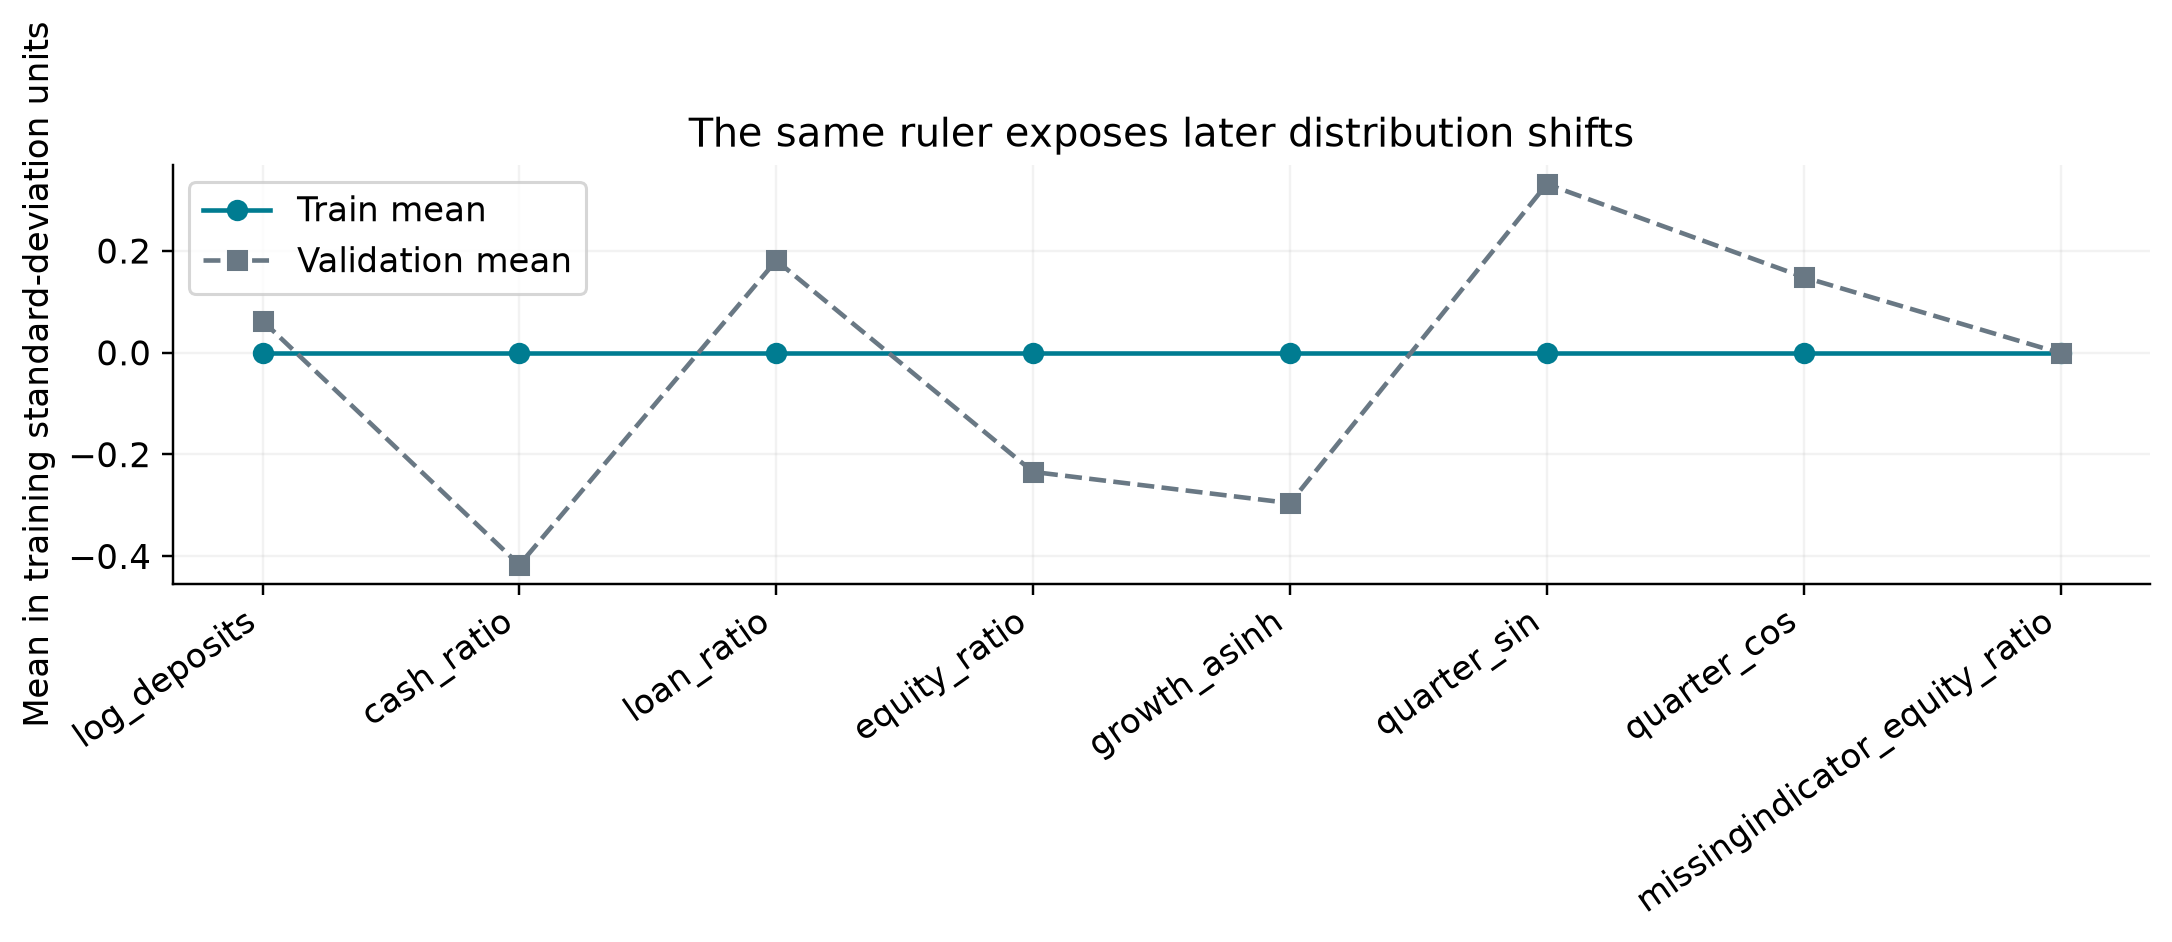

In [19]:
imputer = SimpleImputer(strategy="median", add_indicator=True, keep_empty_features=True)
train_filled = imputer.fit_transform(train[FEATURES])
valid_filled = imputer.transform(valid[FEATURES])
input_names = list(imputer.get_feature_names_out(FEATURES))
scaler = StandardScaler()
X_train = scaler.fit_transform(train_filled).astype("float32")
X_valid = scaler.transform(valid_filled).astype("float32")
assert np.isfinite(X_train).all() and np.isfinite(X_valid).all()
assert not train[FEATURES].isna().all().any()
after_imputation = pd.DataFrame(train_filled[:,:len(FEATURES)], columns=FEATURES, index=train.index)
affected = [c for c in FEATURES if train[c].isna().any()]
decisions = [PreprocessingDecision(field=c, action="impute", method=f"Training median {imputer.statistics_[FEATURES.index(c)]:.6g}",
    reason="Retain incomplete reports; median does not identify the missing mechanism", fit_scope="train_only", keep_missing_indicator=True) for c in affected]
if decisions:
    log = wm_build_preprocessing_log(train[FEATURES], after_imputation, decisions)
    receipt(log[["field","method","fit scope","missing before","missing after","missing indicator kept"]], "Completed imputation receipt")
print("Model input columns:", input_names)
print("Train and validation shapes:", X_train.shape, X_valid.shape)
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(X_train.mean(axis=0),"o-",label="Train mean",color=BLUE)
ax.plot(X_valid.mean(axis=0),"s--",label="Validation mean",color=GREY)
ax.set_xticks(range(len(input_names)),input_names,rotation=35,ha="right")
ax.set(ylabel="Mean in training standard-deviation units",title="The same ruler exposes later distribution shifts"); ax.legend()
finish(fig,"15_preprocessing")

### 4.2 · What shapes do features and targets need?

**Short answer.** Each row is one example; each column is one input. Each output head receives a target and a loss weight for every example.

**ELI8.** The model sees a worksheet: one bank per line and one clue per column. The answer sheet must have exactly the same row order.

**Read the code.** The chance target is 0 or 1. The severity target is log1p of dollars. Its weight is zero for no-decline rows and normalized on positive rows so the two task losses have explicit scale.

**Predict before Run:** Why not train the severity head on zero-decline rows too?

<details><summary>Check your reasoning</summary>

That would estimate an unconditional amount and could pull it toward zero. This head's question is size conditional on a positive decline.

</details>

In [20]:
def targets_and_weights(frame):
    fell = frame.fell.to_numpy(dtype="float32")
    log_amount = np.log1p(frame.runoff_m.to_numpy()).astype("float32")
    assert fell.sum() > 0
    targets = {"chance": fell[:,None], "severity": log_amount[:,None]}
    weights = {"chance": np.ones(len(frame), dtype="float32"), "severity": fell/fell.mean()}
    return targets, weights
Y_train, W_train = targets_and_weights(train)
Y_valid, W_valid = targets_and_weights(valid)
assert all(len(v)==len(X_train) for v in Y_train.values())
assert np.all(W_train["severity"][train.fell.eq(0)] == 0)
assert np.isclose(W_train["severity"].mean(),1)
receipt(pd.DataFrame({"Object": ["Feature matrix", "Chance target", "Severity target", "Severity weights"],
    "Shape": [str(X_train.shape), str(Y_train["chance"].shape), str(Y_train["severity"].shape), str(W_train["severity"].shape)]}), "Rows must remain aligned")

Object,Shape
Feature matrix,"(48472, 8)"
Chance target,"(48472, 1)"
Severity target,"(48472, 1)"
Severity weights,"(48472,)"


## 5. How does a deep network actually learn?

**Start with one neuron:** multiply clues by learned weights, add a learned bias, apply an activation.
For a chance neuron, `z = x·w + b` and `p = sigmoid(z) = 1 / (1 + exp(−z))`.
Weights control the influence of clues; bias sets a starting tendency. Hidden units learn combinations rather than named financial rules.

**Forward pass:** compute predictions. **Loss:** measure wrongness. **Backpropagation:** use the chain rule to assign each weight a derivative of the loss.
**Optimizer:** change weights using those derivatives. Repeat. A gradient is a local slope, not a global guarantee of the best answer.

**Why activations?** Stacking linear layers alone collapses to another linear transformation. ReLU introduces bends.
Sigmoid bounds a chance in [0,1]. Softplus gives a positive severity on the log scale. A bounded output is not automatically calibrated.

### 5.1 · Can I compute one learning step myself?

**Short answer.** Yes. For a sigmoid neuron with binary cross-entropy, the weight gradient for one example is `(p−y)×x`.

**ELI8.** If the guess was too low, move the knobs in directions that raise it. How far you move depends on the learning rate.

**Read the code.** This explicitly illustrative two-feature example uses invented numbers for arithmetic only. We compare a hand derivative with TensorFlow's automatic derivative, then verify one small update reduces its loss.

**Predict before Run:** If the learning rate is enormous, is lower loss guaranteed?

<details><summary>Check your reasoning</summary>

No. A large step can jump past a useful region. The check below applies only to this small illustrative step.

</details>

Step,Probability,Cross-entropy
Before,0.5622,0.5759
After one update,0.5863,0.5340


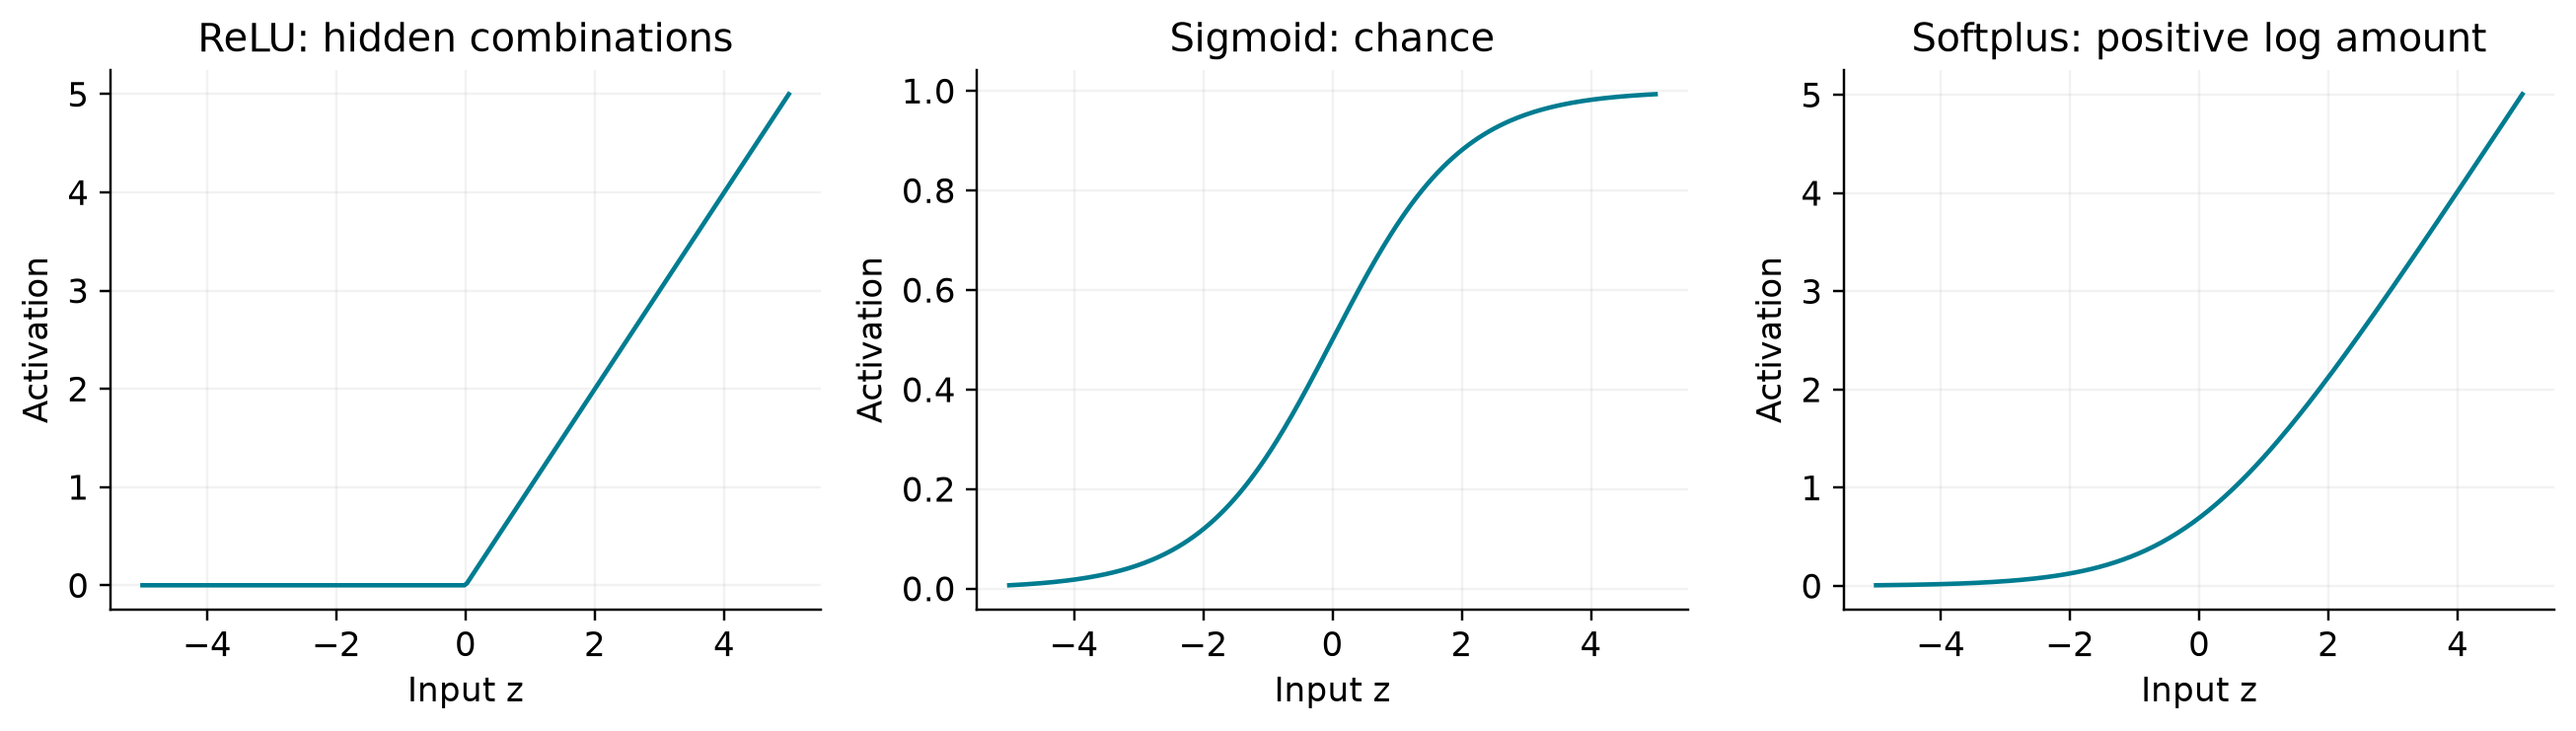

In [21]:
x_demo = np.array([1.0, -0.5], dtype=np.float32)
w_demo = tf.Variable([0.2, -0.1], dtype=tf.float32)
b_demo = tf.Variable(0.0, dtype=tf.float32)
y_demo, learning_rate_demo = 1.0, 0.1
with tf.GradientTape() as tape:
    z_demo = tf.reduce_sum(x_demo*w_demo)+b_demo
    loss_before = tf.nn.sigmoid_cross_entropy_with_logits(labels=y_demo,logits=z_demo)
grad_w, grad_b = tape.gradient(loss_before,[w_demo,b_demo])
p_before = float(tf.sigmoid(z_demo))
hand_gradient = (p_before-y_demo)*x_demo
np.testing.assert_allclose(grad_w.numpy(), hand_gradient, atol=1e-6)
w_demo.assign_sub(learning_rate_demo*grad_w); b_demo.assign_sub(learning_rate_demo*grad_b)
new_z = tf.reduce_sum(x_demo*w_demo)+b_demo
loss_after = float(tf.nn.sigmoid_cross_entropy_with_logits(labels=y_demo,logits=new_z))
assert loss_after < float(loss_before)
receipt(pd.DataFrame({"Step": ["Before", "After one update"],
    "Probability": [p_before,float(tf.sigmoid(new_z))], "Cross-entropy": [float(loss_before),loss_after]}),
    "Illustrative arithmetic, not bank model performance", {"Probability":"{:.4f}","Cross-entropy":"{:.4f}"})
fig, axes = plt.subplots(1,3,figsize=(12,3.5)); z = np.linspace(-5,5,250)
for ax, values, title in zip(axes,[np.maximum(0,z),1/(1+np.exp(-z)),np.logaddexp(0,z)],["ReLU: hidden combinations","Sigmoid: chance","Softplus: positive log amount"]):
    ax.plot(z,values,color=BLUE); ax.set(title=title,xlabel="Input z",ylabel="Activation")
finish(fig,"16_activations")

### 5.2 · Why this architecture, and how many knobs does it learn?

**Short answer.** A compact shared 32→16 network is a testable starting point for this small tabular feature set. Two heads separate occurrence and positive severity.

**ELI8.** Two helpers read the same notes. One guesses whether a decline happens; the other estimates its size when it does.

**Read the code.** The Functional API names the input and both outputs. Dense layers learn weights and biases. The layer receipt counts parameters as `(inputs+1)×units`. We draw layers as blocks so the picture stays readable.

**Predict before Run:** Why no image convolution or recurrent network?

<details><summary>Check your reasoning</summary>

These inputs have no image grid. We provide one prior-change feature rather than a sequence; a recurrent model would require explicit sequence construction and another controlled comparison.

</details>

Layer,Parameters
financial_inputs,0
hidden_1,288
hidden_2,528
chance,17
severity,17


Total parameters: 850


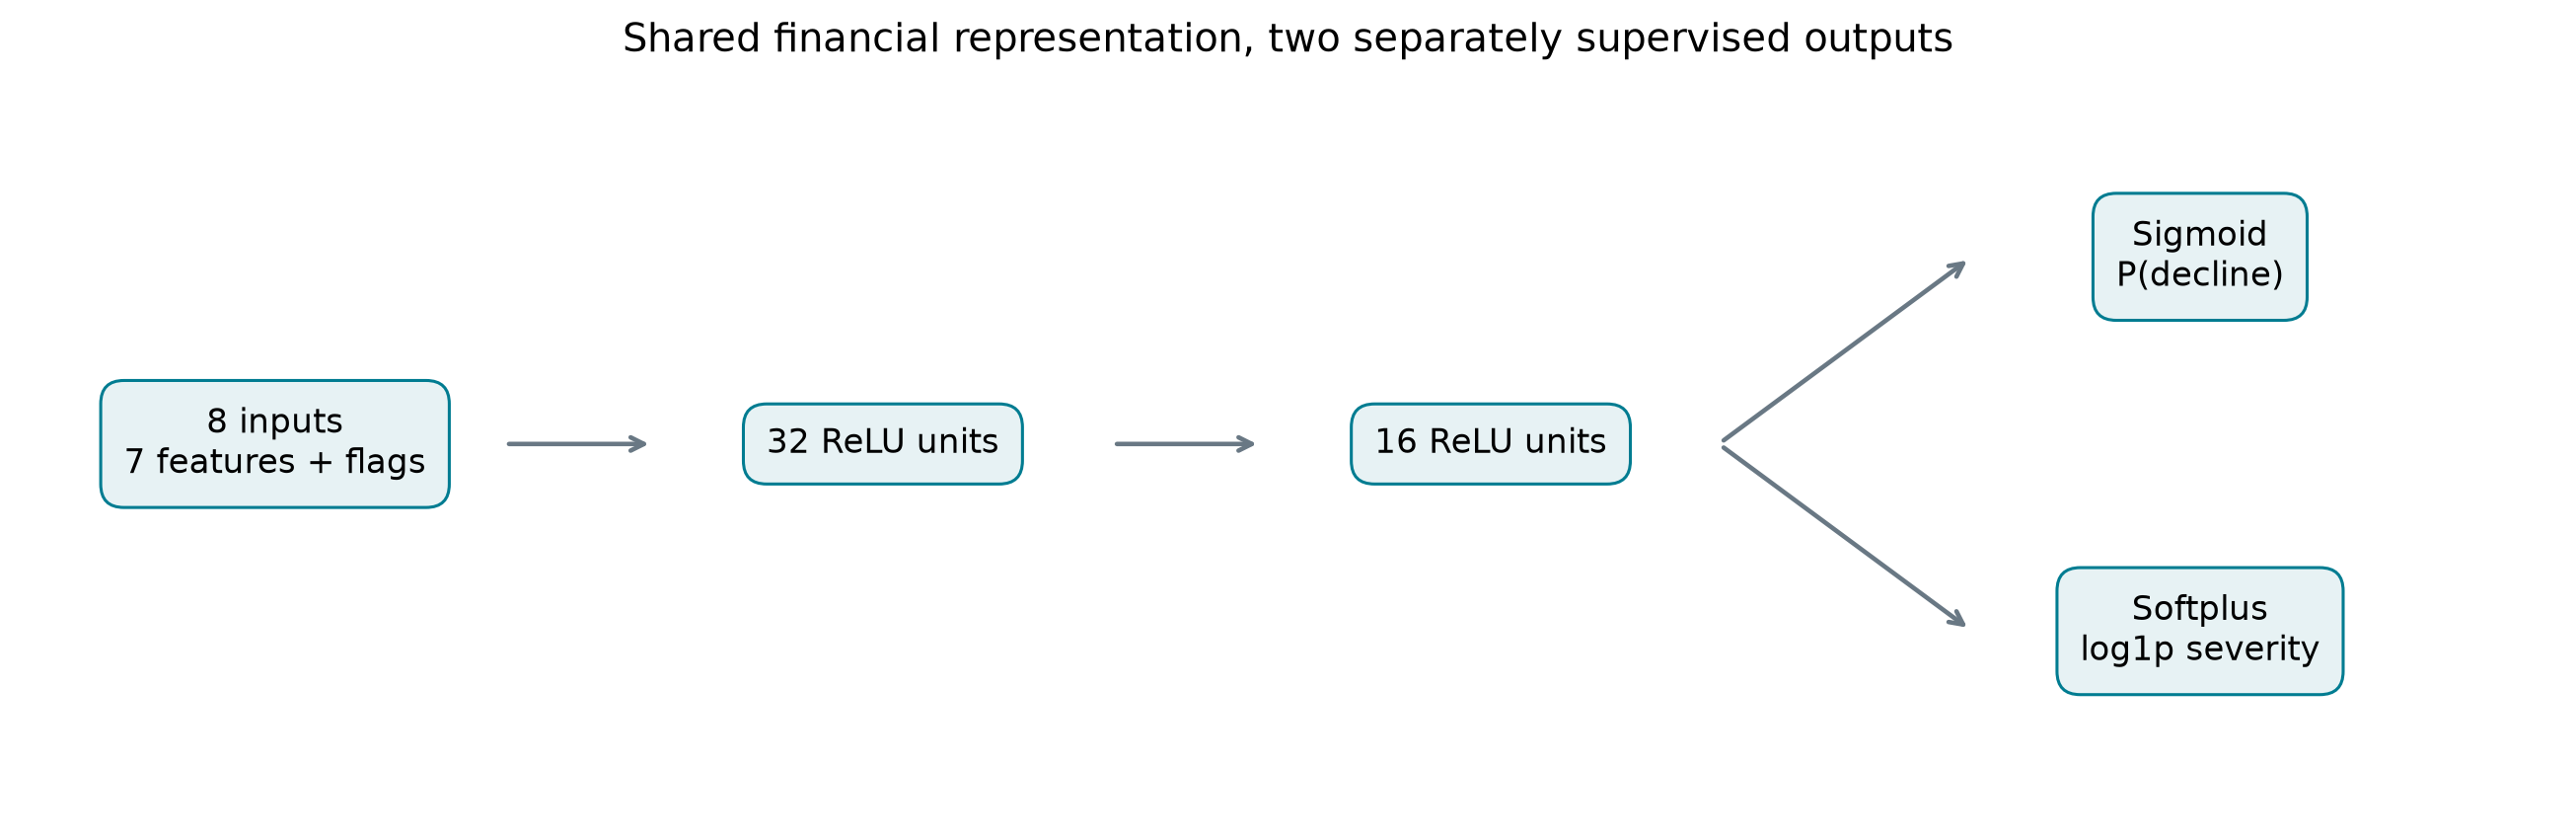

In [22]:
def build_two_head(input_dim, widths=(32,16), dropout=0.0, l2=0.0, seed=SEED):
    tf.keras.utils.set_random_seed(seed)
    inputs = tf.keras.Input(shape=(input_dim,), name="financial_inputs")
    hidden = inputs
    for i,width in enumerate(widths):
        hidden = tf.keras.layers.Dense(width,activation="relu",kernel_initializer="he_normal",
            kernel_regularizer=tf.keras.regularizers.l2(l2),name=f"hidden_{i+1}")(hidden)
        if dropout:
            hidden = tf.keras.layers.Dropout(dropout,name=f"dropout_{i+1}")(hidden)
    outputs = {"chance": tf.keras.layers.Dense(1,activation="sigmoid",name="chance")(hidden),
               "severity": tf.keras.layers.Dense(1,activation="softplus",name="severity")(hidden)}
    model = tf.keras.Model(inputs,outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss={"chance":"binary_crossentropy","severity":"mae"},
        loss_weights={"chance":1.0,"severity":0.2}, run_eagerly=True)
    return model

architecture = build_two_head(X_train.shape[1])
layer_table = pd.DataFrame([{"Layer":layer.name,"Parameters":layer.count_params()} for layer in architecture.layers])
receipt(layer_table,"Every trainable parameter is counted")
print("Total parameters:",architecture.count_params())
fig, ax = plt.subplots(figsize=(12,4)); ax.set_xlim(0,10); ax.set_ylim(0,4); ax.axis("off")
nodes = [(1,2,f"{X_train.shape[1]} inputs\n7 features + flags"),(3.4,2,"32 ReLU units"),(5.8,2,"16 ReLU units"),
         (8.6,3,"Sigmoid\nP(decline)"),(8.6,1,"Softplus\nlog1p severity")]
for x,y,label in nodes:
    ax.text(x,y,label,ha="center",va="center",bbox=dict(boxstyle="round,pad=.7",facecolor="#E7F2F4",edgecolor=BLUE))
for a,b in [(0,1),(1,2),(2,3),(2,4)]:
    ax.annotate("",xy=(nodes[b][0]-.9,nodes[b][1]),xytext=(nodes[a][0]+.9,nodes[a][1]),arrowprops=dict(arrowstyle="->",color=GREY,lw=1.5))
ax.set_title("Shared financial representation, two separately supervised outputs")
finish(fig,"17_architecture")

### What exactly does the training objective reward?

`total loss = mean(binary cross-entropy) + 0.2 × mean(positive-row absolute log error) + L2 penalty`.
The implementation uses a full-batch average with severity weights `fell / training_prevalence`.
Over the complete split, that equals the positive-row mean; individual mini-batches fluctuate. Validation weights use validation prevalence
so its aggregate severity loss has the same conditional meaning. No validation weight participates in training gradients.

- **Binary cross-entropy:** penalizes confidently wrong chances. A 99% prediction when no decline occurs hurts much more than 51%.
- **Log-scale MAE:** seeks a typical positive decline and reduces giant-bank dominance during fitting.
  `expm1(predicted_log_amount)` is a conditional median-style estimate, not the conditional mean.
- **Priority:** chance × conditional typical amount. It has dollar units but **is not a calibrated expected dollar loss**.
  Multiplying a probability by a conditional *mean* would have that expectation identity; our head is not trained for that mean.
- **Adam at 0.001:** an initial optimizer choice that adapts weight updates. It is not universally optimal.
- **Batch size 512:** number of examples per weight-update batch. **Epoch:** one pass over training examples.
- **Early stopping:** stop after three epochs without validation-loss improvement, and restore the best validation-loss weights.
- **Regularization:** the challenger uses L2=0.0001 to penalize large weights and dropout=0.1 to mask hidden activations during training.
  Dropout turns off at prediction time. A smaller network is another constraint on capacity.
- **Loss weight 0.2:** an explicit teaching hyperparameter balancing tasks; not a financial price or calibrated business cost.
- **CPU/eager execution:** simple to inspect and compatible with the original local environment; slower than a compiled training loop.

The losses of one-output and two-output networks have different meanings. Compare each curve to its own history,
then compare models with the same external decision metrics.

### 5.3 · How do we check the implementation before spending time on experiments?

**Short answer.** Check output shapes, finite gradients, zero contribution from masked severity rows, and the ability to reduce loss on a tiny real-data subset.

**ELI8.** Before a road trip, check the brakes in the driveway. Passing that check does not prove the entire trip will be safe.

**Read the code.** A balanced 64-row training subset supplies the smoke test. We compute gradients explicitly and fit the same small subset repeatedly. That deliberate overfitting checks wiring; it does not measure generalization.

**Predict before Run:** Would a tiny-subset success justify opening the holdout?

<details><summary>Check your reasoning</summary>

No. We still need baselines, validation experiments, and a frozen selection rule.

</details>

In [23]:
tiny_positions = np.r_[np.flatnonzero(train.fell.to_numpy()==0)[:32],np.flatnonzero(train.fell.to_numpy()==1)[:32]]
tiny_frame = train.iloc[tiny_positions]
tiny_y,tiny_w = targets_and_weights(tiny_frame)
tiny_x = X_train[tiny_positions]
smoke = build_two_head(X_train.shape[1],seed=SEED)
with tf.GradientTape() as tape:
    outputs = smoke(tiny_x,training=True)
    bce = tf.keras.losses.binary_crossentropy(tiny_y["chance"],outputs["chance"])
    error = tf.abs(tf.constant(tiny_y["severity"])-outputs["severity"])[:,0]
    masked_error = error*tf.constant(tiny_w["severity"])
    smoke_loss = tf.reduce_mean(bce)+.2*tf.reduce_mean(masked_error)
gradients = tape.gradient(smoke_loss,smoke.trainable_variables)
assert all(g is not None and bool(tf.reduce_all(tf.math.is_finite(g))) for g in gradients)
assert outputs["chance"].shape == (64,1)
assert np.all(masked_error.numpy()[tiny_frame.fell.eq(0)]==0)
before = float(smoke.evaluate(tiny_x,tiny_y,sample_weight=tiny_w,verbose=0,return_dict=True)["loss"])
for _ in range(100):
    smoke.train_on_batch(tiny_x,tiny_y,sample_weight=tiny_w)
after = float(smoke.evaluate(tiny_x,tiny_y,sample_weight=tiny_w,verbose=0,return_dict=True)["loss"])
assert after < before, "Tiny-data loss did not improve; investigate implementation before experiments."
wm_check_card(title="Preliminary implementation checks",theme=theme,checks=[
    {"label":"Output shape", "status":"PASS", "detail":"Two (64, 1) outputs on 64 real training rows"},
    {"label":"Gradients and masking", "status":"PASS", "detail":"All gradients finite; 32 no-decline rows contribute zero severity loss"},
    {"label":"Tiny-data learning", "status":"PASS", "detail":f"Loss {before:.4f} → {after:.4f} after 100 updates; training evidence only"}])
del smoke

## 6. Which experiments could change our conclusion?

**Freeze the plan before scoring.** We compare size, prior decline, a linear two-part model, a boosted-tree two-part model,
a direct one-output network, and three two-head variants. The regularized variant changes capacity and regularization together;
it is a practical candidate, not an experiment isolating which regularizer caused a difference. The no-calendar variant is a controlled feature ablation.

**Primary selection metric:** mean fraction of observed decline dollars captured by the top 10% **within each validation quarter**.
Each quarter gets equal weight. Dollar-weighted aggregate capture is also reported. Ties in model selection use the table order, with simpler rules first.
Within-quarter score ties use certificate ascending for a reproducible queue. Alternative seeds are stability checks, excluded from best-seed selection.

**Secondary questions:** does the chance head distinguish declines (AP, ROC AUC)? Are its probabilities reliable (Brier, calibration)?
How well does the severity head estimate positive amounts (MAE, log MAE)? How many actual decline cases fit in the queue?
No one metric answers all four questions.

**Retesting rule:** diagnose on validation, test a predeclared smaller/regularized architecture and no-calendar ablation, then freeze.
Historical evaluation may describe failure modes but cannot trigger another tuning loop on 2024.

### 6.1 · How do we score a review queue fairly?

**Short answer.** Every model gets the same number of review slots in each quarter. Dollars and cases use separate denominators.

**ELI8.** Give each contestant the same basket size. Then count both how many apples and how much apple weight each basket catches.

**Read the code.** The evaluator groups by quarter, selects ceil(10%×rows), and computes capture and case recall. All-zero priority gets an explicitly deterministic tie order, not a claim that it has learned a ranking.

**Predict before Run:** Why not take the top 10% from all years pooled together?

<details><summary>Check your reasoning</summary>

That could allocate most review slots to one quarter. An analyst makes a new queue each quarter.

</details>

In [24]:
def queue_mask(frame, score, fraction=CAPACITY):
    ranking = frame[["report_date","CERT"]].reset_index(drop=True).copy()
    ranking["score"] = np.asarray(score)
    assert len(score)==len(frame) and np.isfinite(score).all()
    chosen = np.zeros(len(frame),dtype=bool)
    for _, group in ranking.groupby("report_date",sort=True):
        count = max(1,int(np.ceil(len(group)*fraction)))
        order = group.sort_values(["score","CERT"],ascending=[False,True],kind="stable").index[:count]
        chosen[order] = True
    return chosen

def rank_metrics(frame, score, fraction=CAPACITY):
    chosen = queue_mask(frame,score,fraction)
    f = frame[["report_date","runoff_m","fell"]].reset_index(drop=True).copy()
    f["selected"] = chosen
    parts = []
    for date,g in f.groupby("report_date"):
        selected = g.loc[g.selected]
        parts.append({"Quarter":str(date.to_period("Q")),"Rows":len(g),"Selected":int(g.selected.sum()),
            "Capture": selected.runoff_m.sum()/g.runoff_m.sum() if g.runoff_m.sum()>0 else np.nan,
            "Case recall": selected.fell.sum()/g.fell.sum() if g.fell.sum()>0 else np.nan,
            "Precision": selected.fell.mean()})
    quarters = pd.DataFrame(parts)
    return {"Mean quarterly capture":quarters.Capture.mean(),
        "Aggregate capture":f.loc[chosen,"runoff_m"].sum()/f.runoff_m.sum(),
        "Mean case recall":quarters["Case recall"].mean()}, quarters

def probability_metrics(frame,p):
    return {"AP":average_precision_score(frame.fell,p),"ROC AUC":roc_auc_score(frame.fell,p),
        "Brier":brier_score_loss(frame.fell,p)}

def previous_decline(frame):
    return ((frame.prior_deposits-frame.DEPDOM)/1000).clip(lower=0).to_numpy()

def bounded_severity(frame,log_prediction):
    # Enforce the physical limit: a nonnegative balance cannot lose more than itself.
    max_log = np.log1p(frame.deposit_m.to_numpy())
    return np.expm1(np.clip(np.asarray(log_prediction).ravel(),0,max_log))

# Independent small contract: two quarters, one slot each, explicit dollar arithmetic.
fixture = pd.DataFrame({"report_date":pd.to_datetime(["2000-03-31"]*2+["2000-06-30"]*2),
    "CERT":[1,2,1,2],"runoff_m":[2.,8.,1.,9.],"fell":[1,1,1,1]})
fixture_result,_ = rank_metrics(fixture,np.array([0,1,1,0]),fraction=.5)
assert np.isclose(fixture_result["Mean quarterly capture"],(.8+.1)/2)
print("Quarter-specific ranking and denominator check passed.")

Quarter-specific ranking and denominator check passed.


### 6.2 · Which simple models must the network beat?

**Short answer.** Size tests dollar concentration; prior decline tests persistence; logistic-plus-ridge tests linear relationships; boosted trees test a strong tabular alternative.

**ELI8.** Before buying a fancy calculator, see what a ruler and a simple rule already do well.

**Read the code.** The linear and tree chance models use all training rows. Their severity regressions use only positive training rows on a log scale. We cap amount predictions at current deposits for every learned amount model.

**Predict before Run:** Why include a tree model in a deep learning assignment?

<details><summary>Check your reasoning</summary>

Because choosing a deep network responsibly requires checking whether simpler or different model families already solve the task.

</details>

In [25]:
positive_mask = train.fell.to_numpy().astype(bool)
linear_chance = LogisticRegression(max_iter=600,random_state=SEED).fit(X_train,train.fell)
linear_amount = Ridge(alpha=10).fit(X_train[positive_mask],Y_train["severity"][positive_mask].ravel())
tree_chance = HistGradientBoostingClassifier(max_iter=100,max_leaf_nodes=15,l2_regularization=1,random_state=SEED).fit(X_train,train.fell)
tree_amount = HistGradientBoostingRegressor(loss="absolute_error",max_iter=100,max_leaf_nodes=15,
    l2_regularization=1,random_state=SEED).fit(X_train[positive_mask],Y_train["severity"][positive_mask].ravel())
validation_predictions = {}
validation_predictions["Size rule"] = {"priority":valid.deposit_m.to_numpy()}
validation_predictions["Prior decline"] = {"priority":previous_decline(valid)}
for name,c_model,s_model in [("Linear two-part",linear_chance,linear_amount),("Boosted trees",tree_chance,tree_amount)]:
    probability = c_model.predict_proba(X_valid)[:,1]
    severity = bounded_severity(valid,s_model.predict(X_valid))
    validation_predictions[name] = {"chance":probability,"severity":severity,"priority":probability*severity}
print("Baselines fitted on",len(train),"training rows; validation predictions ready.")

Baselines fitted on 48472 training rows; validation predictions ready.


### 6.3 · What happens if we ask one network to predict everything directly?

**Short answer.** A one-output network is an informative comparison because it must learn a zero-heavy amount distribution with one loss.

**ELI8.** One helper must answer both whether it rains and how much it rains using a single number.

**Read the code.** The shared layer sizes stay 32 and 16. A softplus output predicts log1p amount for all rows with MAE. Early stopping uses validation loss. Its output ranks amounts but supplies no separate calibrated decline chance.

**Predict before Run:** Can we compare this network's raw loss height with the two-head loss height?

<details><summary>Check your reasoning</summary>

No. They optimize different objectives. Use the same queue metrics to compare them.

</details>

In [26]:
def train_network(model, x, y, vx, vy, weights=None, vweights=None):
    validation = (vx,vy) if vweights is None else (vx,vy,vweights)
    start = time.perf_counter()
    history = model.fit(x,y,sample_weight=weights,validation_data=validation,
        epochs=MAX_EPOCHS,batch_size=BATCH_SIZE,verbose=0,shuffle=True,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True)])
    return history.history, time.perf_counter()-start

tf.keras.utils.set_random_seed(SEED)
single = tf.keras.Sequential([tf.keras.Input((X_train.shape[1],)),
    tf.keras.layers.Dense(32,activation="relu"),tf.keras.layers.Dense(16,activation="relu"),
    tf.keras.layers.Dense(1,activation="softplus")])
single.compile(optimizer=tf.keras.optimizers.Adam(.001),loss="mae",run_eagerly=True)
single_history,single_seconds = train_network(single,X_train,Y_train["severity"],X_valid,Y_valid["severity"])
validation_predictions["One-head MLP"] = {"priority":bounded_severity(valid,single(X_valid,training=False).numpy())}
print("One-head epochs:",len(single_history["loss"]),"| seconds:",round(single_seconds,1))

2026-09-20 22:36:40.564446: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-09-20 22:36:40.564846: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

One-head epochs: 4 | seconds: 4.6


### 6.4 · Do shared heads, regularization, or calendar features improve validation?

**Short answer.** Run the declared alternatives under the same split and budget, recording each model rather than keeping only the winner.

**ELI8.** Try a few named recipes and write down every result. Do not quietly throw away the ones that taste worse.

**Read the code.** Each experiment stores its trained network, history, elapsed time, and predictions. The regularized model is smaller; the no-calendar model removes only the two seasonal inputs. Seeds 17 and 83 repeat the base architecture.

**Predict before Run:** Why must we not pick the luckiest seed and call that typical performance?

<details><summary>Check your reasoning</summary>

The seed would become another tuned hyperparameter. Here the primary seed is fixed at 42; the others show sensitivity.

</details>

In [27]:
no_calendar = np.array([i for i,name in enumerate(input_names) if name not in {"quarter_sin","quarter_cos"}])
all_inputs = np.arange(X_train.shape[1])
specs = [
    ("Two-head MLP",(32,16),0.,0.,SEED,all_inputs),
    ("Regularized MLP",(16,8),.1,.0001,SEED,all_inputs),
    ("No-calendar MLP",(32,16),0.,0.,SEED,no_calendar),
    ("Seed 17",(32,16),0.,0.,17,all_inputs),
    ("Seed 83",(32,16),0.,0.,83,all_inputs)]
trained,experiment_log = {},[]
for name,widths,drop,l2,seed,cols in specs:
    model = build_two_head(len(cols),widths,drop,l2,seed)
    history,seconds = train_network(model,X_train[:,cols],Y_train,X_valid[:,cols],Y_valid,W_train,W_valid)
    predictions = model(X_valid[:,cols],training=False)
    chance = predictions["chance"].numpy().ravel()
    severity = bounded_severity(valid,predictions["severity"].numpy())
    validation_predictions[name] = {"chance":chance,"severity":severity,"priority":chance*severity}
    trained[name] = {"model":model,"history":history,"columns":cols}
    experiment_log.append({"Model":name,"Widths":str(widths),"Dropout":drop,"L2":l2,"Seed":seed,
        "Epochs":len(history["loss"]),"Best epoch":int(np.argmin(history["val_loss"])+1),"Seconds":seconds,"Parameters":model.count_params()})
    print(name,"finished:",len(history["loss"]),"epochs")
receipt(pd.DataFrame(experiment_log),"Every neural experiment has a receipt",{"Seconds":"{:.1f}"})

2026-09-20 22:36:46.923451: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_18}}
2026-09-20 22:36:46.923879: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

Two-head MLP finished: 10 epochs


2026-09-20 22:37:03.862420: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_18}}
2026-09-20 22:37:03.862839: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

Regularized MLP finished: 18 epochs


2026-09-20 22:37:42.484775: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_18}}
2026-09-20 22:37:42.485255: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

...

2026-09-20 22:38:17.552961: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_18}}
2026-09-20 22:38:17.553353: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

Seed 17 finished: 18 epochs


2026-09-20 22:38:54.983951: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_18}}
2026-09-20 22:38:54.984481: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

Seed 83 finished: 10 epochs


Model,Widths,Dropout,L2,Seed,Epochs,Best epoch,Seconds,Parameters
Two-head MLP,"(32, 16)",0.000000,0.000000,42,10,7,18.7,850
Regularized MLP,"(16, 8)",0.100000,0.000100,42,18,17,38.6,298
No-calendar MLP,"(32, 16)",0.000000,0.000000,42,16,13,35.0,786
Seed 17,"(32, 16)",0.000000,0.000000,17,18,16,37.4,850
Seed 83,"(32, 16)",0.000000,0.000000,83,10,7,21.4,850


### 6.5 · What do the learning curves actually diagnose?

**Short answer.** Diverging training and validation loss suggests overfitting or a period difference. Both staying high may suggest underfitting, optimization difficulty, or weak features.

**ELI8.** Doing better on yesterday's spelling list while struggling on new words tells us memorization may be winning.

**Read the code.** Plot both losses against epochs for each candidate. The dotted vertical line is its best validation epoch, whose weights are restored. Each panel has its own loss units; regularized loss also includes the penalty.

**Predict before Run:** Does early stopping guarantee the best dollar-capture ranking?

<details><summary>Check your reasoning</summary>

No. It monitors training-objective loss. Candidate selection uses the separate declared business metric.

</details>

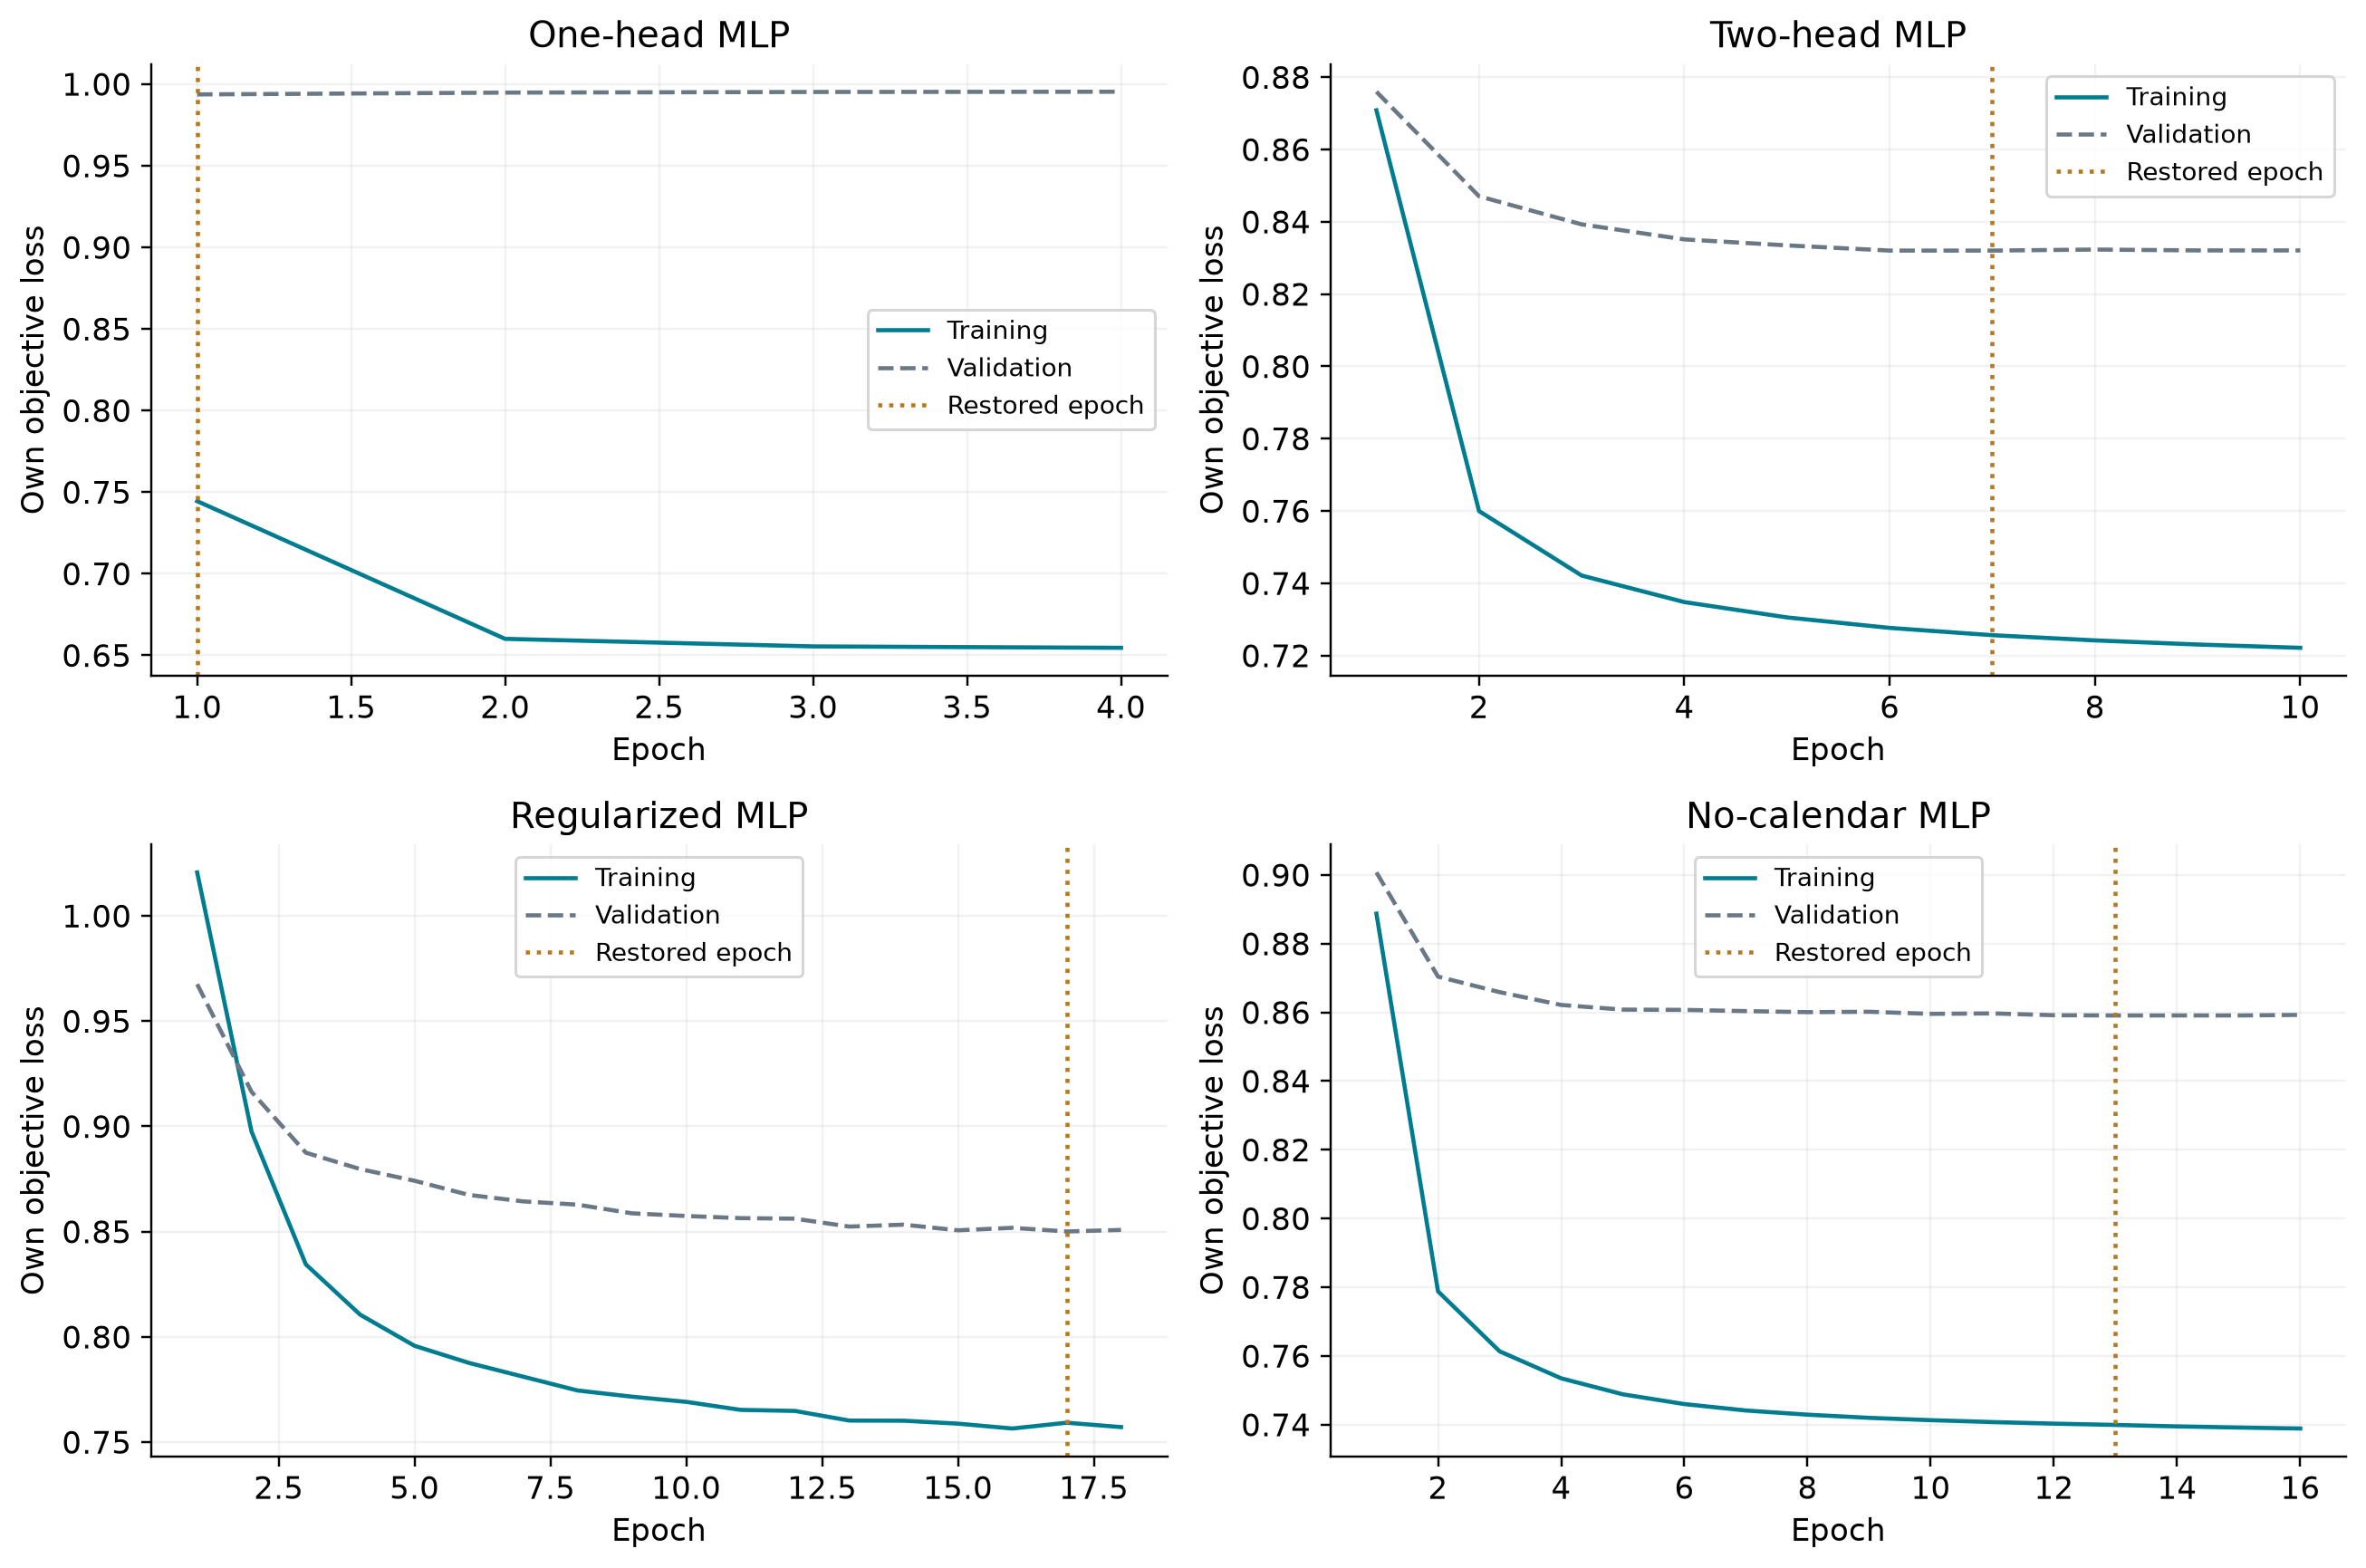

In [28]:
histories = {"One-head MLP":single_history, **{name:trained[name]["history"] for name in ["Two-head MLP","Regularized MLP","No-calendar MLP"]}}
fig, axes = plt.subplots(2,2,figsize=(12,8))
for ax,(name,h) in zip(axes.ravel(),histories.items()):
    epochs = np.arange(1,len(h["loss"])+1)
    ax.plot(epochs,h["loss"],label="Training",color=BLUE)
    ax.plot(epochs,h["val_loss"],label="Validation",color=GREY,ls="--")
    ax.axvline(np.argmin(h["val_loss"])+1,color=AMBER,ls=":",label="Restored epoch")
    ax.set(title=name,xlabel="Epoch",ylabel="Own objective loss"); ax.legend(fontsize=9)
finish(fig,"18_learning_curves")

### 6.6 · Which candidate earns the historical evaluation?

**Short answer.** Select from primary candidates using the declared validation ranking metric. Keep probability quality and severity error visible alongside it.

**ELI8.** Choose the recipe using the practice taste test, then write the choice in ink before the final test.

**Read the code.** All model names are retained in the receipt. Seed variants are excluded from selection. The winner is frozen and saved to a manifest before we compute historical predictions.

**Predict before Run:** If the size rule wins, did the lesson fail?

<details><summary>Check your reasoning</summary>

No. It would show that extra modeling complexity did not add ranking value under the chosen metric and validation period.

</details>

Model,Mean quarterly capture,Aggregate capture,Mean case recall
Size rule,83.26%,85.98%,8.65%
Prior decline,48.30%,49.85%,9.38%
Linear two-part,84.15%,86.75%,9.09%
Boosted trees,83.76%,86.47%,9.06%
One-head MLP,2.34%,1.69%,11.96%
Two-head MLP,83.82%,86.35%,8.83%
Regularized MLP,83.92%,86.56%,9.00%
No-calendar MLP,83.59%,86.28%,8.87%
Seed 17,82.68%,85.81%,8.79%
Seed 83,83.43%,86.20%,8.80%


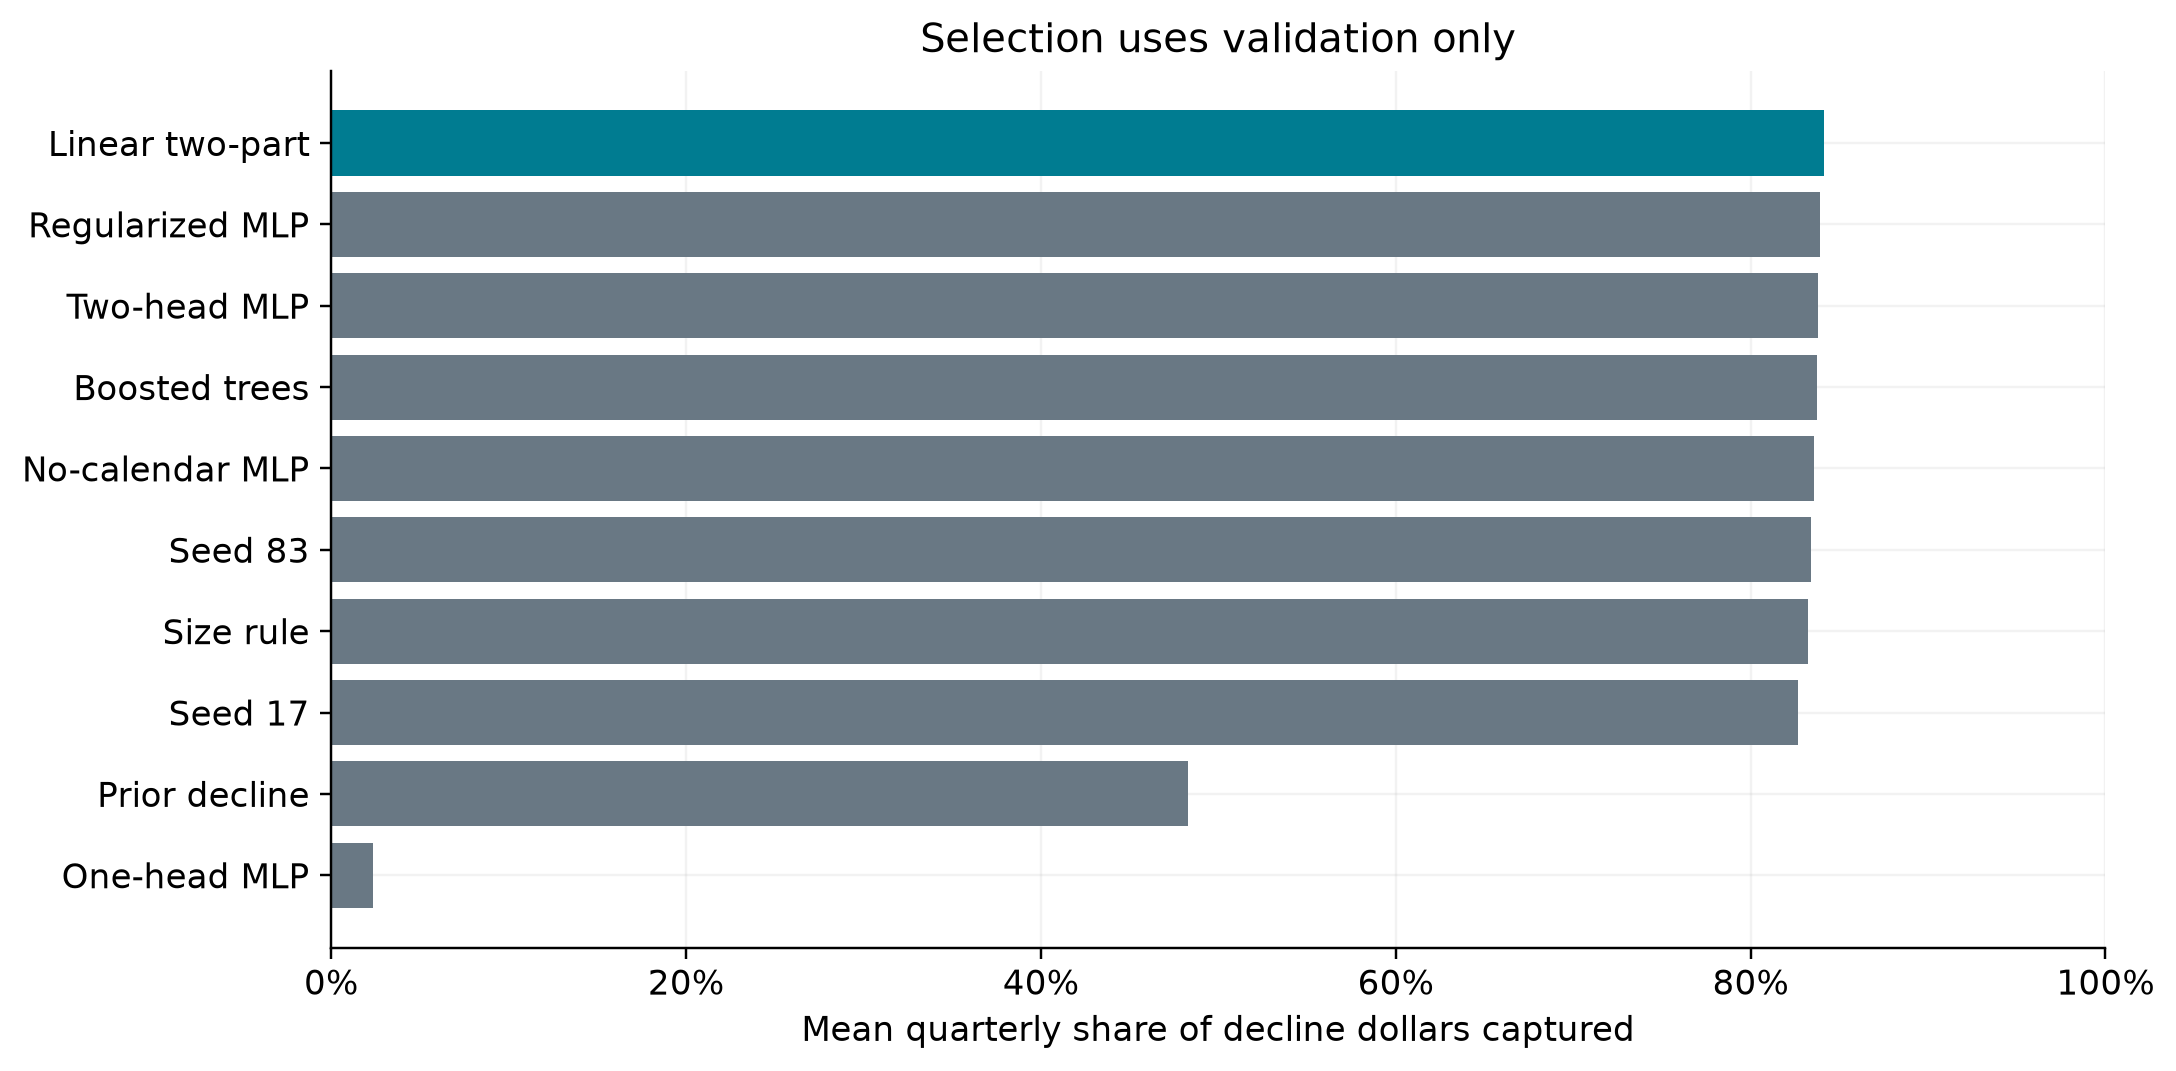

Model,AP,ROC AUC,Brier
Training prevalence,0.481,0.500,0.275
Linear two-part,0.559,0.588,0.263
Boosted trees,0.562,0.609,0.251
Two-head MLP,0.561,0.610,0.253
Regularized MLP,0.575,0.606,0.259
No-calendar MLP,0.537,0.576,0.267
Seed 17,0.550,0.601,0.254
Seed 83,0.573,0.616,0.253


Model,MAE USD M
Training positive median,67.73
Linear two-part,47.18
Boosted trees,47.07
Two-head MLP,53.81
Regularized MLP,48.68
No-calendar MLP,42.91
Seed 17,44.30
Seed 83,59.27


In [29]:
validation_scores = pd.DataFrame([{"Model":name,**rank_metrics(valid,pred["priority"])[0]}
    for name,pred in validation_predictions.items()])
primary_candidates = [name for name in validation_predictions if not name.startswith("Seed ")]
selection = validation_scores.loc[validation_scores.Model.isin(primary_candidates)].sort_values(
    "Mean quarterly capture",ascending=False,kind="stable")
winner = selection.iloc[0].Model
receipt(validation_scores,"Validation queue comparison: 10% each quarter",{c:"{:.2%}" for c in validation_scores.columns if c!="Model"})
fig, ax = plt.subplots(figsize=(10,5))
ordered = validation_scores.sort_values("Mean quarterly capture")
ax.barh(ordered.Model,ordered["Mean quarterly capture"],color=[BLUE if n==winner else GREY for n in ordered.Model])
ax.set_xlim(0,1); ax.xaxis.set_major_formatter(PercentFormatter(1)); ax.set(xlabel="Mean quarterly share of decline dollars captured",title="Selection uses validation only")
finish(fig,"19_validation_ranking")
prob_receipt = [{"Model":"Training prevalence",**probability_metrics(valid,np.full(len(valid),prevalence))}]
severity_receipt = [{"Model":"Training positive median","MAE USD M":mean_absolute_error(valid.loc[valid.fell.eq(1),"runoff_m"],np.full(valid.fell.sum(),positive_train.runoff_m.median()))}]
for name,pred in validation_predictions.items():
    if "chance" in pred:
        prob_receipt.append({"Model":name,**probability_metrics(valid,pred["chance"])})
        mask = valid.fell.eq(1).to_numpy()
        severity_receipt.append({"Model":name,"MAE USD M":mean_absolute_error(valid.runoff_m.to_numpy()[mask],pred["severity"][mask])})
receipt(pd.DataFrame(prob_receipt),"Validation probability quality",{"AP":"{:.3f}","ROC AUC":"{:.3f}","Brier":"{:.3f}"})
receipt(pd.DataFrame(severity_receipt),"Positive-row amount error; validation",{"MAE USD M":"{:,.2f}"})
frozen = {"winner":winner,"seed":SEED,"capacity":CAPACITY,"features":FEATURES,"source_sha256":source_sha,
    "selection_metric":"equal-quarter mean capture","test_status":"reused historical 2024 holdout",
    "no_retraining_after_selection":True}
(OUT/"frozen_plan.json").write_text(json.dumps(frozen,indent=2))
takeaway("The choice is now frozen",f"Validation selects {winner}. The following historical evaluation does not change this choice.")

### 6.7 · How much do seeds and calendar choices matter?

**Short answer.** Use paired differences against the base network on the same validation rows. A seed spread is a sensitivity check, not a confidence interval.

**ELI8.** Cook the same recipe three times before assuming one good result is guaranteed.

**Read the code.** The comparison subtracts base mean-quarter capture. The seed range and controlled no-calendar difference are calculated from completed runs. The smaller regularized variant has several changes, so causal attribution is limited.

**Predict before Run:** Can three seeds establish robust performance across future years?

<details><summary>Check your reasoning</summary>

No. They test initialization and training randomness under one temporal split, not new economic conditions.

</details>

Model,Mean quarterly capture,Difference from base (pp)
Two-head MLP,83.82%,+0.00
Seed 17,82.68%,-1.14
Seed 83,83.43%,-0.39
Regularized MLP,83.92%,+0.10
No-calendar MLP,83.59%,-0.23


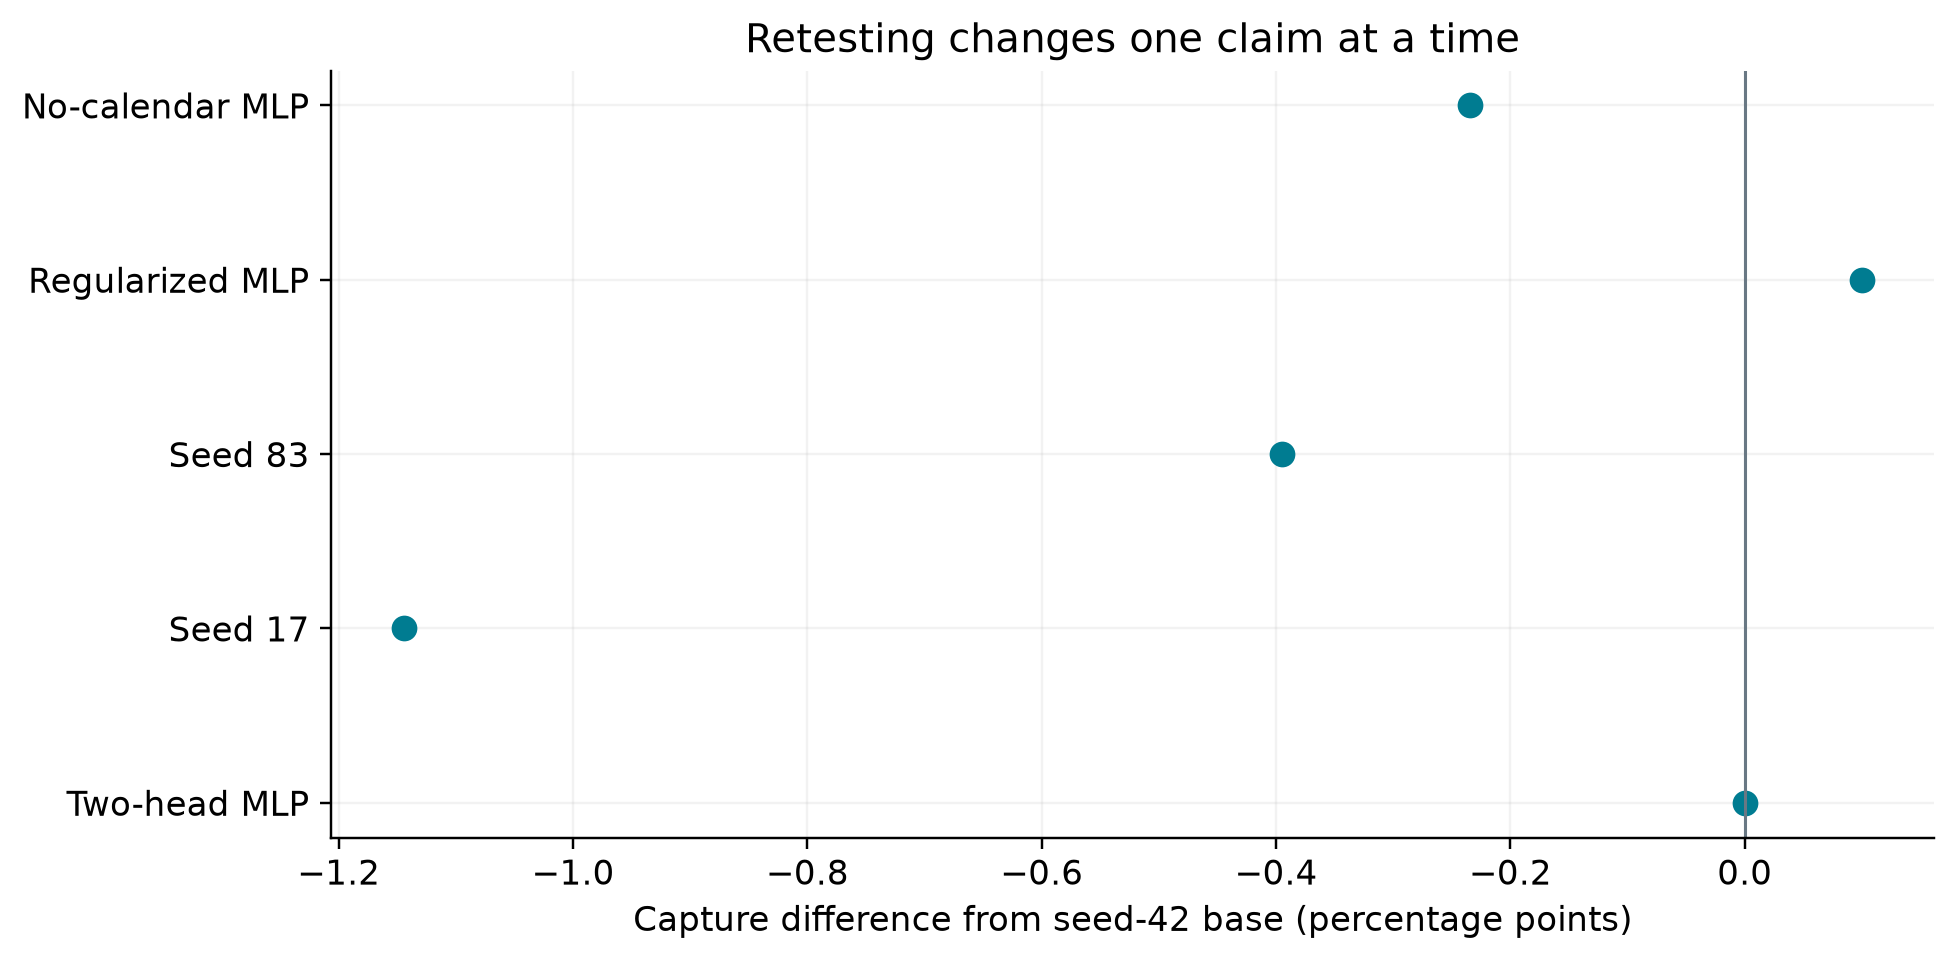

In [30]:
indexed = validation_scores.set_index("Model")
names = ["Two-head MLP","Seed 17","Seed 83","Regularized MLP","No-calendar MLP"]
stability = indexed.loc[names,["Mean quarterly capture"]].reset_index()
stability["Difference from base (pp)"] = 100*(stability["Mean quarterly capture"]-indexed.loc["Two-head MLP","Mean quarterly capture"])
receipt(stability,"Validation sensitivity; same rows and capacity",{"Mean quarterly capture":"{:.2%}","Difference from base (pp)":"{:+.2f}"})
fig, ax = plt.subplots()
ax.scatter(stability["Difference from base (pp)"],stability.Model,color=BLUE,s=55)
ax.axvline(0,color=GREY,lw=1); ax.set(xlabel="Capture difference from seed-42 base (percentage points)",title="Retesting changes one claim at a time")
finish(fig,"20_sensitivity")
seed_values = indexed.loc[["Two-head MLP","Seed 17","Seed 83"],"Mean quarterly capture"]
takeaway("Training randomness has a measurable range",f"The three base-architecture runs span {seed_values.min():.2%} to {seed_values.max():.2%} validation capture. "
    "This range is descriptive. Calendar removal and regularization were tested before historical evaluation.")

## 7. What survives the reused historical holdout?

**Stop and say the contract aloud:** “The model choice, capacity, features, and preprocessing are frozen.
I will describe 2024 outcomes once in this notebook, and I will not tune against them.”
The earlier assignment already used this period; that reuse limits confirmatory interpretation even when the new run follows a clean execution order.

**Metric reading guide.** AP summarizes precision across recall levels (higher is better, prevalence is a useful reference).
ROC AUC measures ordering of positives above negatives (0.5 is a no-discrimination reference).
Brier is mean squared probability error (lower is better). Calibration compares predicted chances with observed rates.
Dollar capture measures covered observed declines, **not avoided loss or saved money**. Case recall measures covered decline events.

### 7.1 · What happens when every frozen method sees later reports?

**Short answer.** Reuse the fitted imputer, scaler, and models. Evaluate primary candidates transparently; the validation winner remains fixed.

**ELI8.** Use the same ruler and the recipe you already chose. Seeing the exam answers does not let us edit the recipe and call it the same exam.

**Read the code.** Only now do we transform historical predictors and make model predictions. Secondary historical comparisons are descriptive. The original assignment's published percentages are not copied because the split and quarterly budget differ.

**Predict before Run:** Should we now select whichever model wins in 2024?

<details><summary>Check your reasoning</summary>

No. That would turn this period into another validation set. Report the frozen choice and any failure honestly.

</details>

Model,Mean quarterly capture,Aggregate capture,Mean case recall
Size rule,84.82%,89.04%,9.29%
Prior decline,32.88%,27.14%,8.17%
Linear two-part,85.33%,89.37%,9.43%
Boosted trees,85.26%,89.29%,9.65%
One-head MLP,1.77%,1.24%,11.34%
Two-head MLP,85.09%,89.25%,9.41%
Regularized MLP,84.92%,89.23%,9.60%
No-calendar MLP,85.16%,89.21%,9.25%


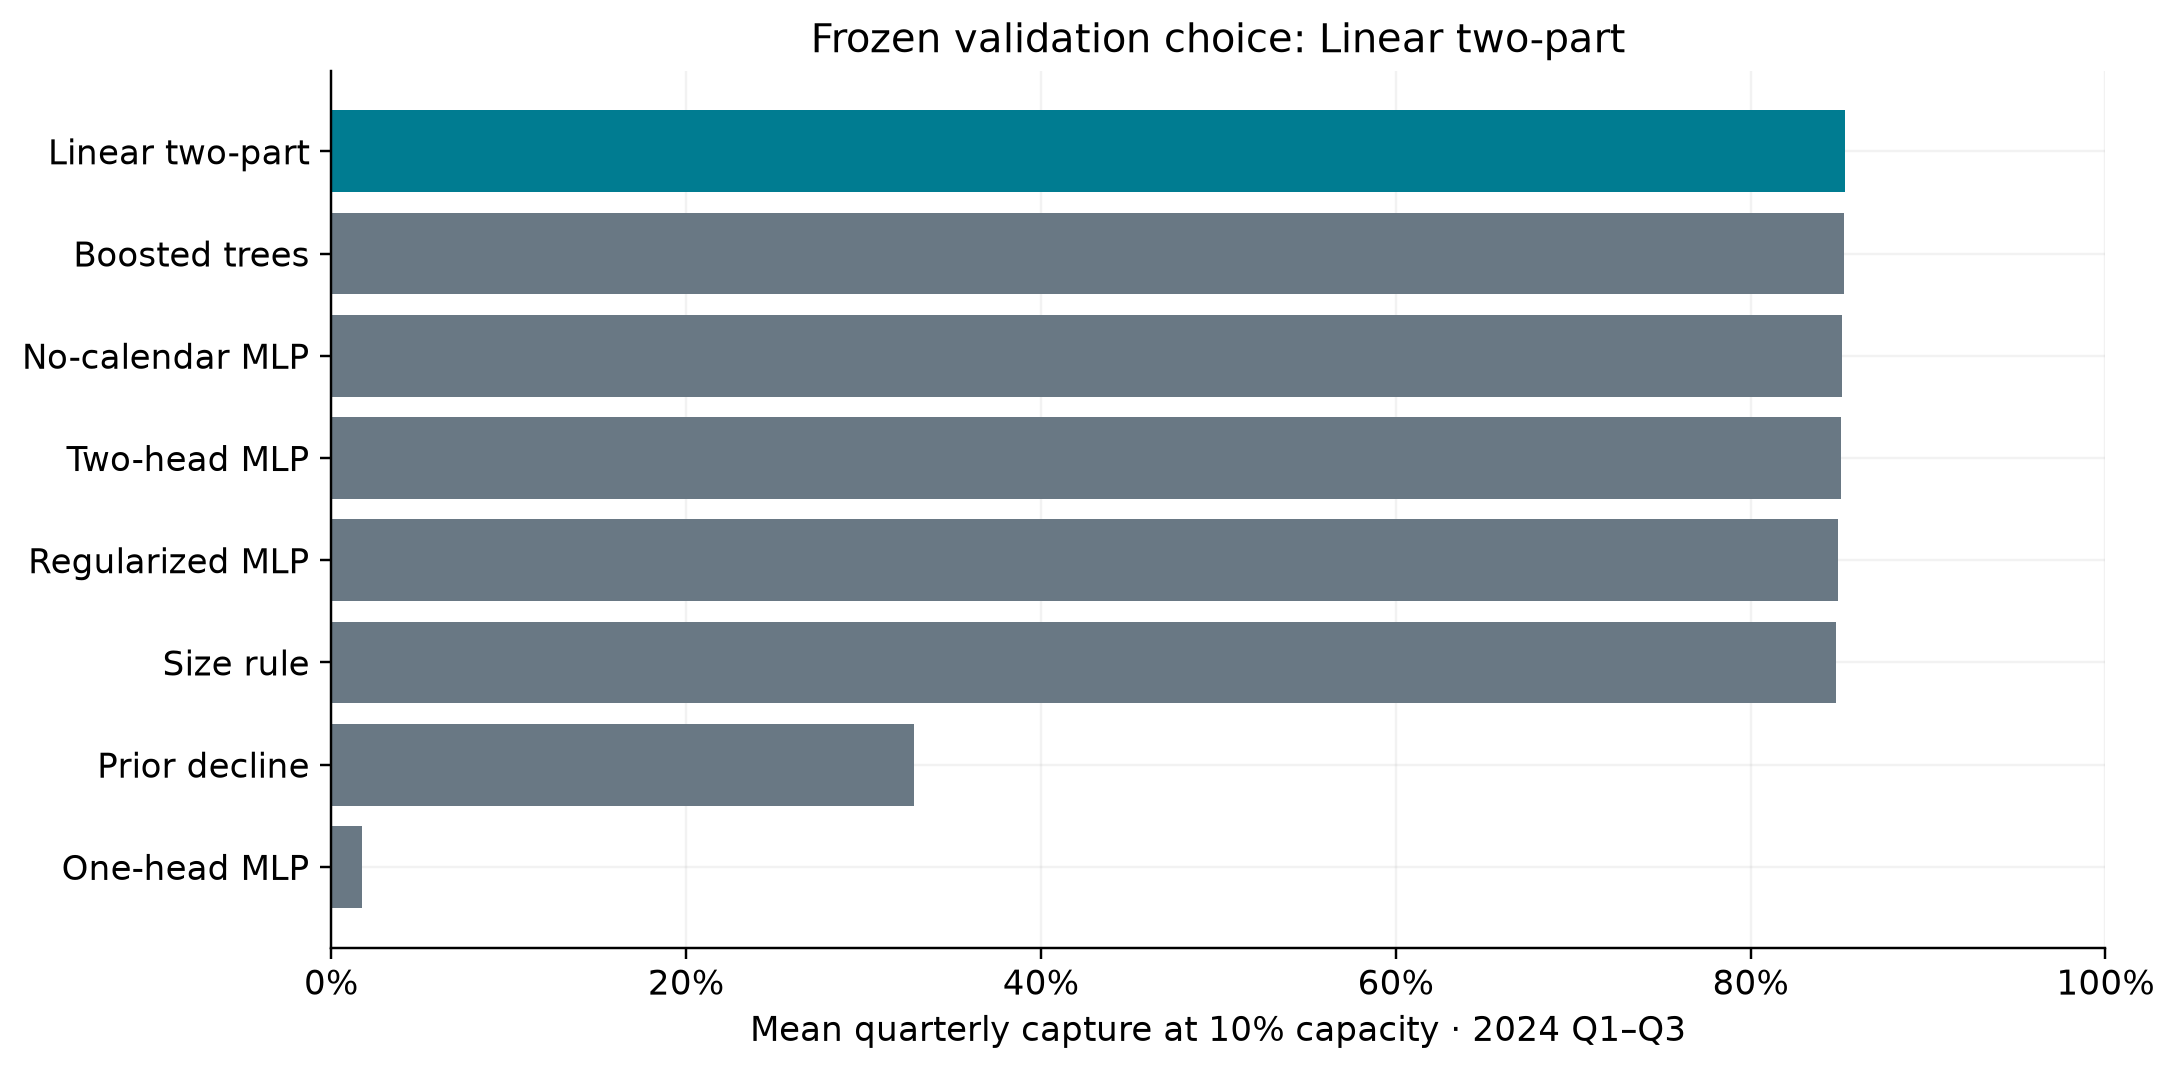

In [31]:
X_test = scaler.transform(imputer.transform(test[FEATURES])).astype("float32")
assert np.isfinite(X_test).all()
test_predictions = {"Size rule":{"priority":test.deposit_m.to_numpy()},"Prior decline":{"priority":previous_decline(test)}}
for name,c_model,s_model in [("Linear two-part",linear_chance,linear_amount),("Boosted trees",tree_chance,tree_amount)]:
    p = c_model.predict_proba(X_test)[:,1]; s = bounded_severity(test,s_model.predict(X_test))
    test_predictions[name] = {"chance":p,"severity":s,"priority":p*s}
test_predictions["One-head MLP"] = {"priority":bounded_severity(test,single(X_test,training=False).numpy())}
for name in ["Two-head MLP","Regularized MLP","No-calendar MLP"]:
    record = trained[name]; out = record["model"](X_test[:,record["columns"]],training=False)
    p = out["chance"].numpy().ravel(); s = bounded_severity(test,out["severity"].numpy())
    test_predictions[name] = {"chance":p,"severity":s,"priority":p*s}
historical_scores = pd.DataFrame([{"Model":name,**rank_metrics(test,pred["priority"])[0]}
    for name,pred in test_predictions.items()])
receipt(historical_scores,"Historical 2024 evaluation; selection remains frozen",{c:"{:.2%}" for c in historical_scores.columns if c!="Model"})
fig, ax = plt.subplots(figsize=(10,5))
order = historical_scores.sort_values("Mean quarterly capture")
ax.barh(order.Model,order["Mean quarterly capture"],color=[BLUE if n==winner else GREY for n in order.Model])
ax.set_xlim(0,1);ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.set(title=f"Frozen validation choice: {winner}",xlabel="Mean quarterly capture at 10% capacity · 2024 Q1–Q3")
finish(fig,"21_historical_ranking")

### 7.2 · Does the network identify declines and estimate believable probabilities?

**Short answer.** Discrimination and calibration need separate checks. A good ordering can coexist with inaccurate probabilities.

**ELI8.** A child might rank tomorrow's weather correctly from sunny to rainy but still say '90%' far too often.

**Read the code.** PR and ROC curves compare the base network, logistic baseline, and boosted trees. The calibration plot uses probability bins; the companion histogram shows where predictions live. Bins can be noisy and are not uncertainty intervals.

**Predict before Run:** If ROC AUC is above 0.5, are probabilities calibrated?

<details><summary>Check your reasoning</summary>

No. ROC depends on order; calibration depends on the actual probability values.

</details>

Model,AP,ROC AUC,Brier
Training prevalence,0.400,0.500,0.246
Linear two-part,0.460,0.568,0.241
Boosted trees,0.476,0.596,0.236
Two-head MLP,0.481,0.602,0.235


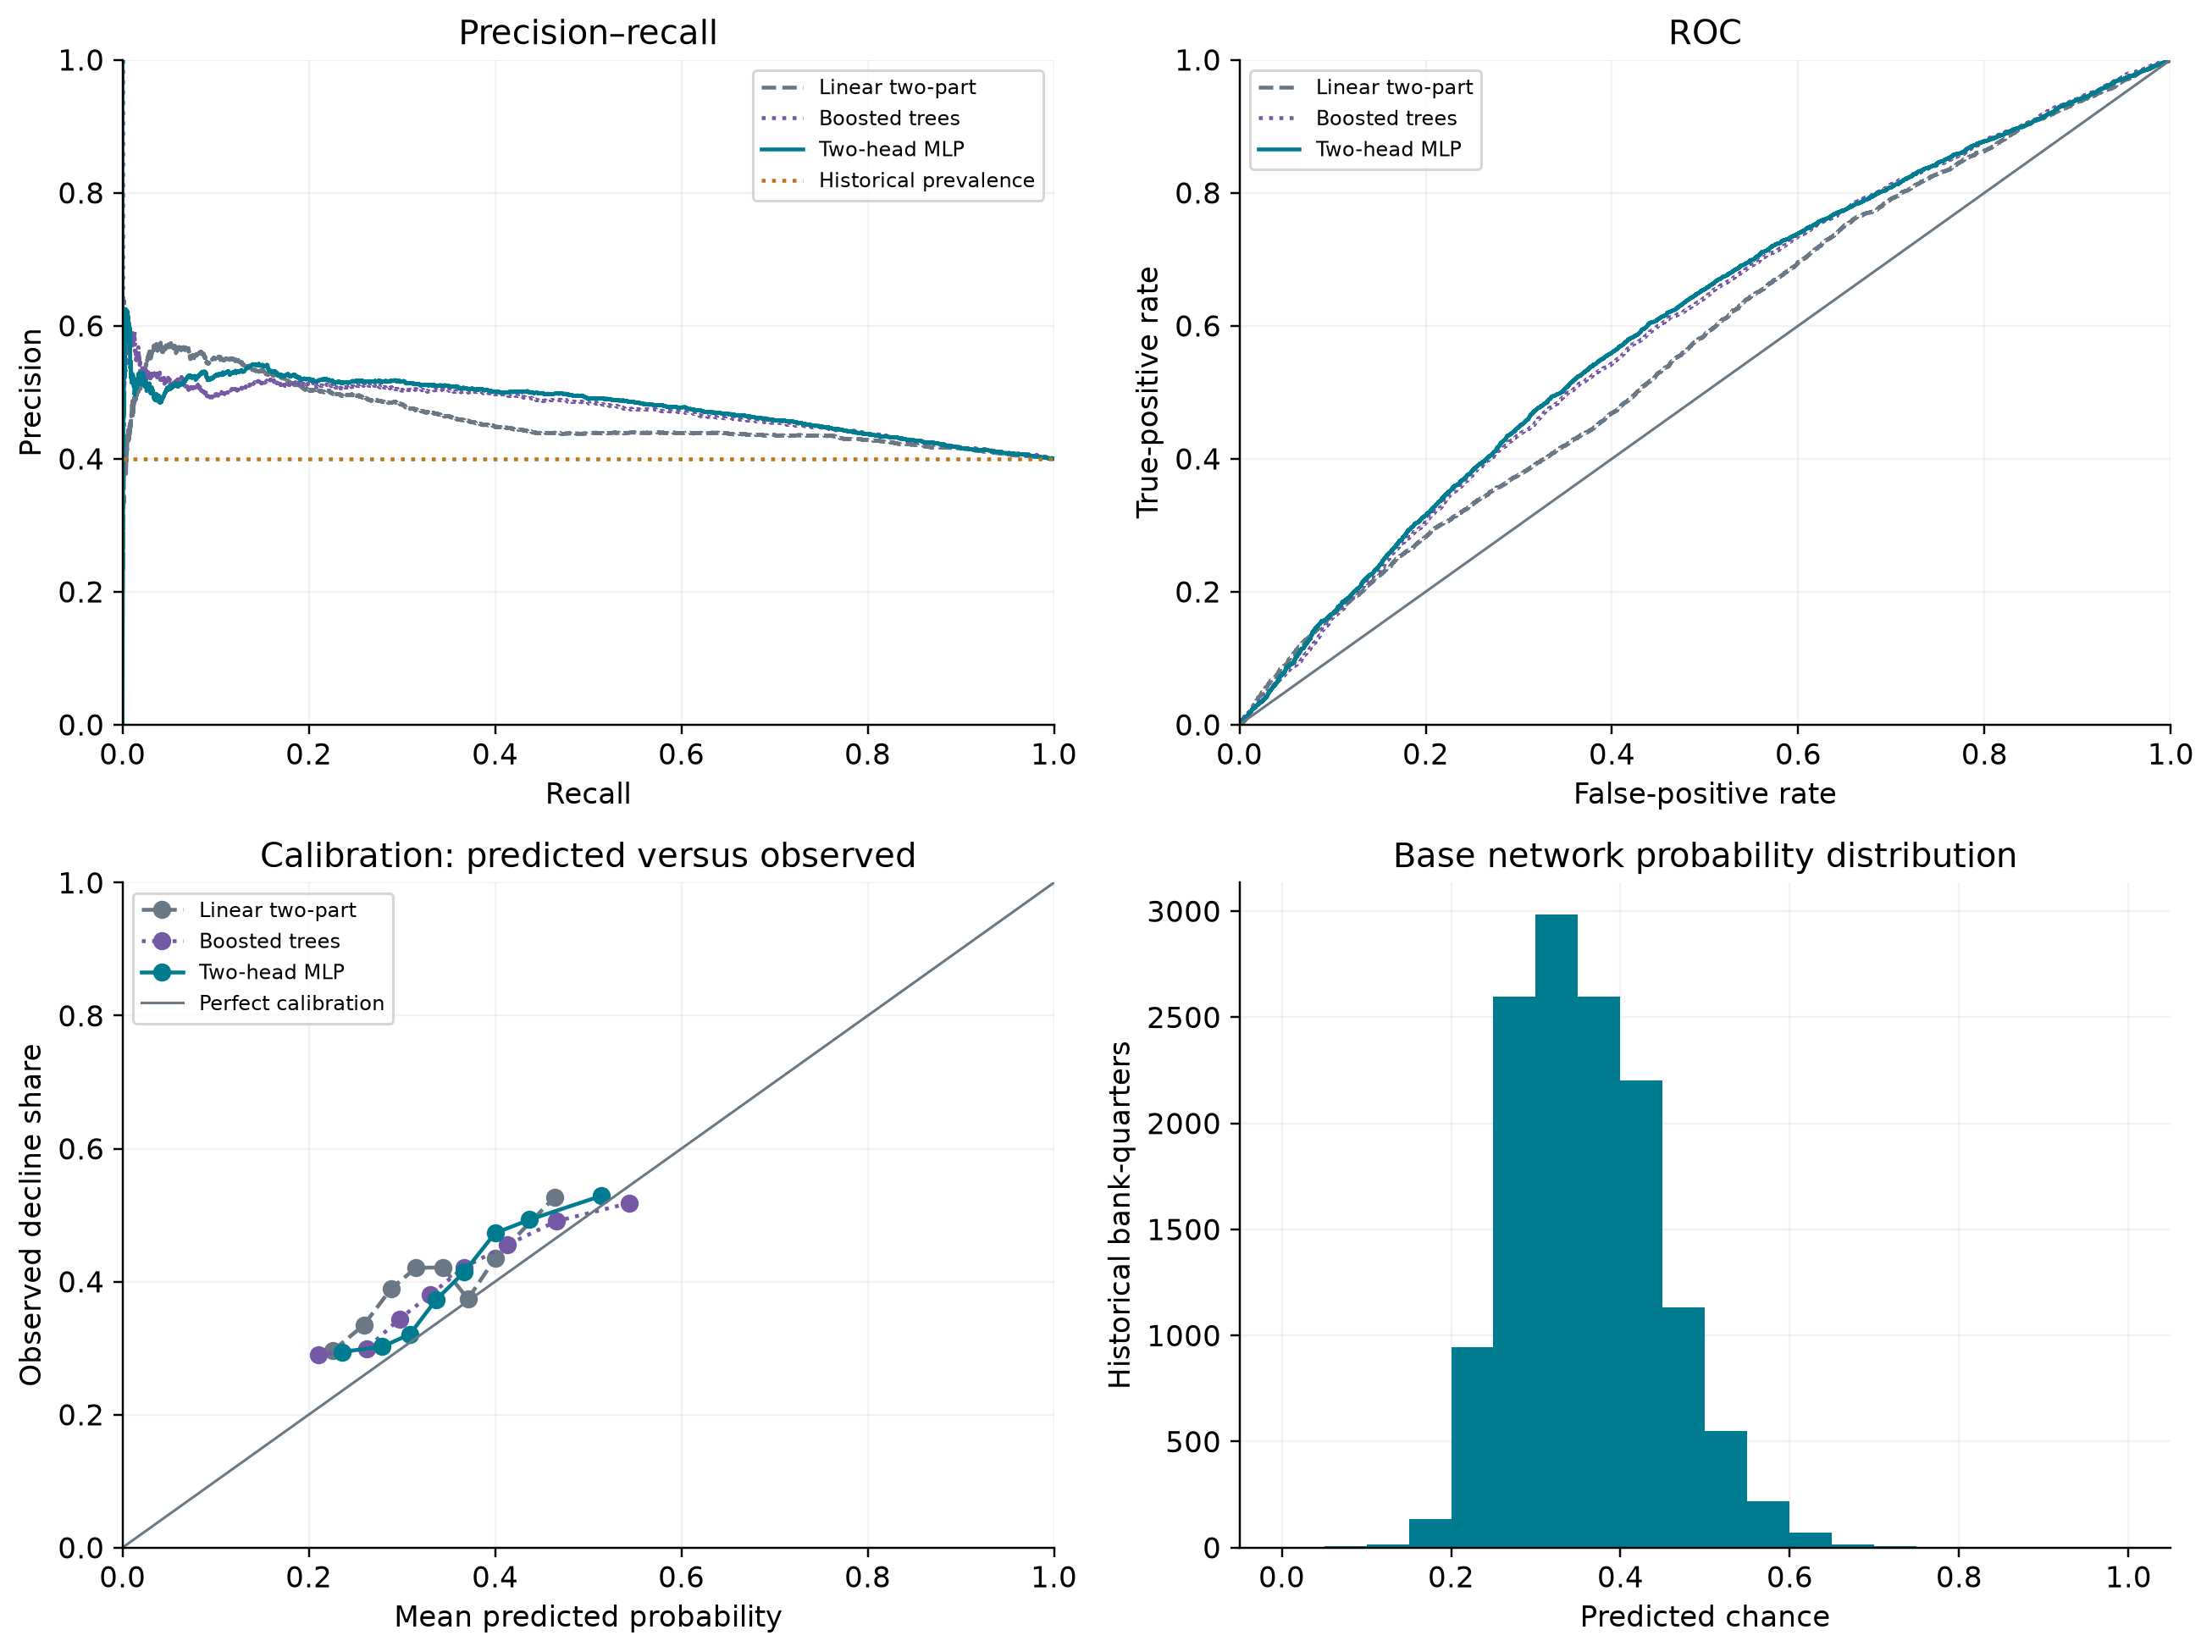

In [32]:
probability_names = ["Linear two-part","Boosted trees","Two-head MLP"]
test_prob_table = pd.DataFrame([{"Model":"Training prevalence",**probability_metrics(test,np.full(len(test),prevalence))}]+
    [{"Model":n,**probability_metrics(test,test_predictions[n]["chance"])} for n in probability_names])
receipt(test_prob_table,"Historical probability metrics",{"AP":"{:.3f}","ROC AUC":"{:.3f}","Brier":"{:.3f}"})
fig, axes = plt.subplots(2,2,figsize=(12,9))
for n,color,style in zip(probability_names,[GREY,"#7659A5",BLUE],["--",":","-"]):
    p = test_predictions[n]["chance"]
    precision,recall,_ = precision_recall_curve(test.fell,p)
    fpr,tpr,_ = roc_curve(test.fell,p)
    axes[0,0].plot(recall,precision,label=n,color=color,ls=style)
    axes[0,1].plot(fpr,tpr,label=n,color=color,ls=style)
    observed,predicted = calibration_curve(test.fell,p,n_bins=8,strategy="quantile")
    axes[1,0].plot(predicted,observed,marker="o",label=n,color=color,ls=style)
axes[0,0].axhline(test.fell.mean(),color=AMBER,ls=":",label="Historical prevalence")
axes[0,1].plot([0,1],[0,1],color=GREY,lw=1)
axes[1,0].plot([0,1],[0,1],color=GREY,lw=1,label="Perfect calibration")
axes[1,1].hist(test_predictions["Two-head MLP"]["chance"],bins=np.linspace(0,1,21),color=BLUE)
for ax in [axes[0,0],axes[0,1],axes[1,0]]:
    ax.set_xlim(0,1);ax.set_ylim(0,1);ax.legend(fontsize=8)
axes[0,0].set(title="Precision–recall",xlabel="Recall",ylabel="Precision")
axes[0,1].set(title="ROC",xlabel="False-positive rate",ylabel="True-positive rate")
axes[1,0].set(title="Calibration: predicted versus observed",xlabel="Mean predicted probability",ylabel="Observed decline share")
axes[1,1].set(title="Base network probability distribution",xlabel="Predicted chance",ylabel="Historical bank-quarters")
finish(fig,"22_probability_diagnostics")

### 7.3 · How does queue capacity change what we catch?

**Short answer.** A capacity rule creates a quarter-specific score cutoff. It is different from using probability 0.5.

**ELI8.** If you can inspect ten bags, choose the ten highest-ranked bags. You do not get extra time because more bags look suspicious.

**Read the code.** Capture curves recompute ranks at several capacities for the frozen winner, base network, and size rule. The confusion matrix calls selected rows 'review' and unselected rows 'no review'; it is an operational queue, not a diagnosis.

**Predict before Run:** Should we choose a new capacity from this 2024 curve?

<details><summary>Check your reasoning</summary>

No. This is a sensitivity description. Operational capacity was set at 10% before evaluation.

</details>

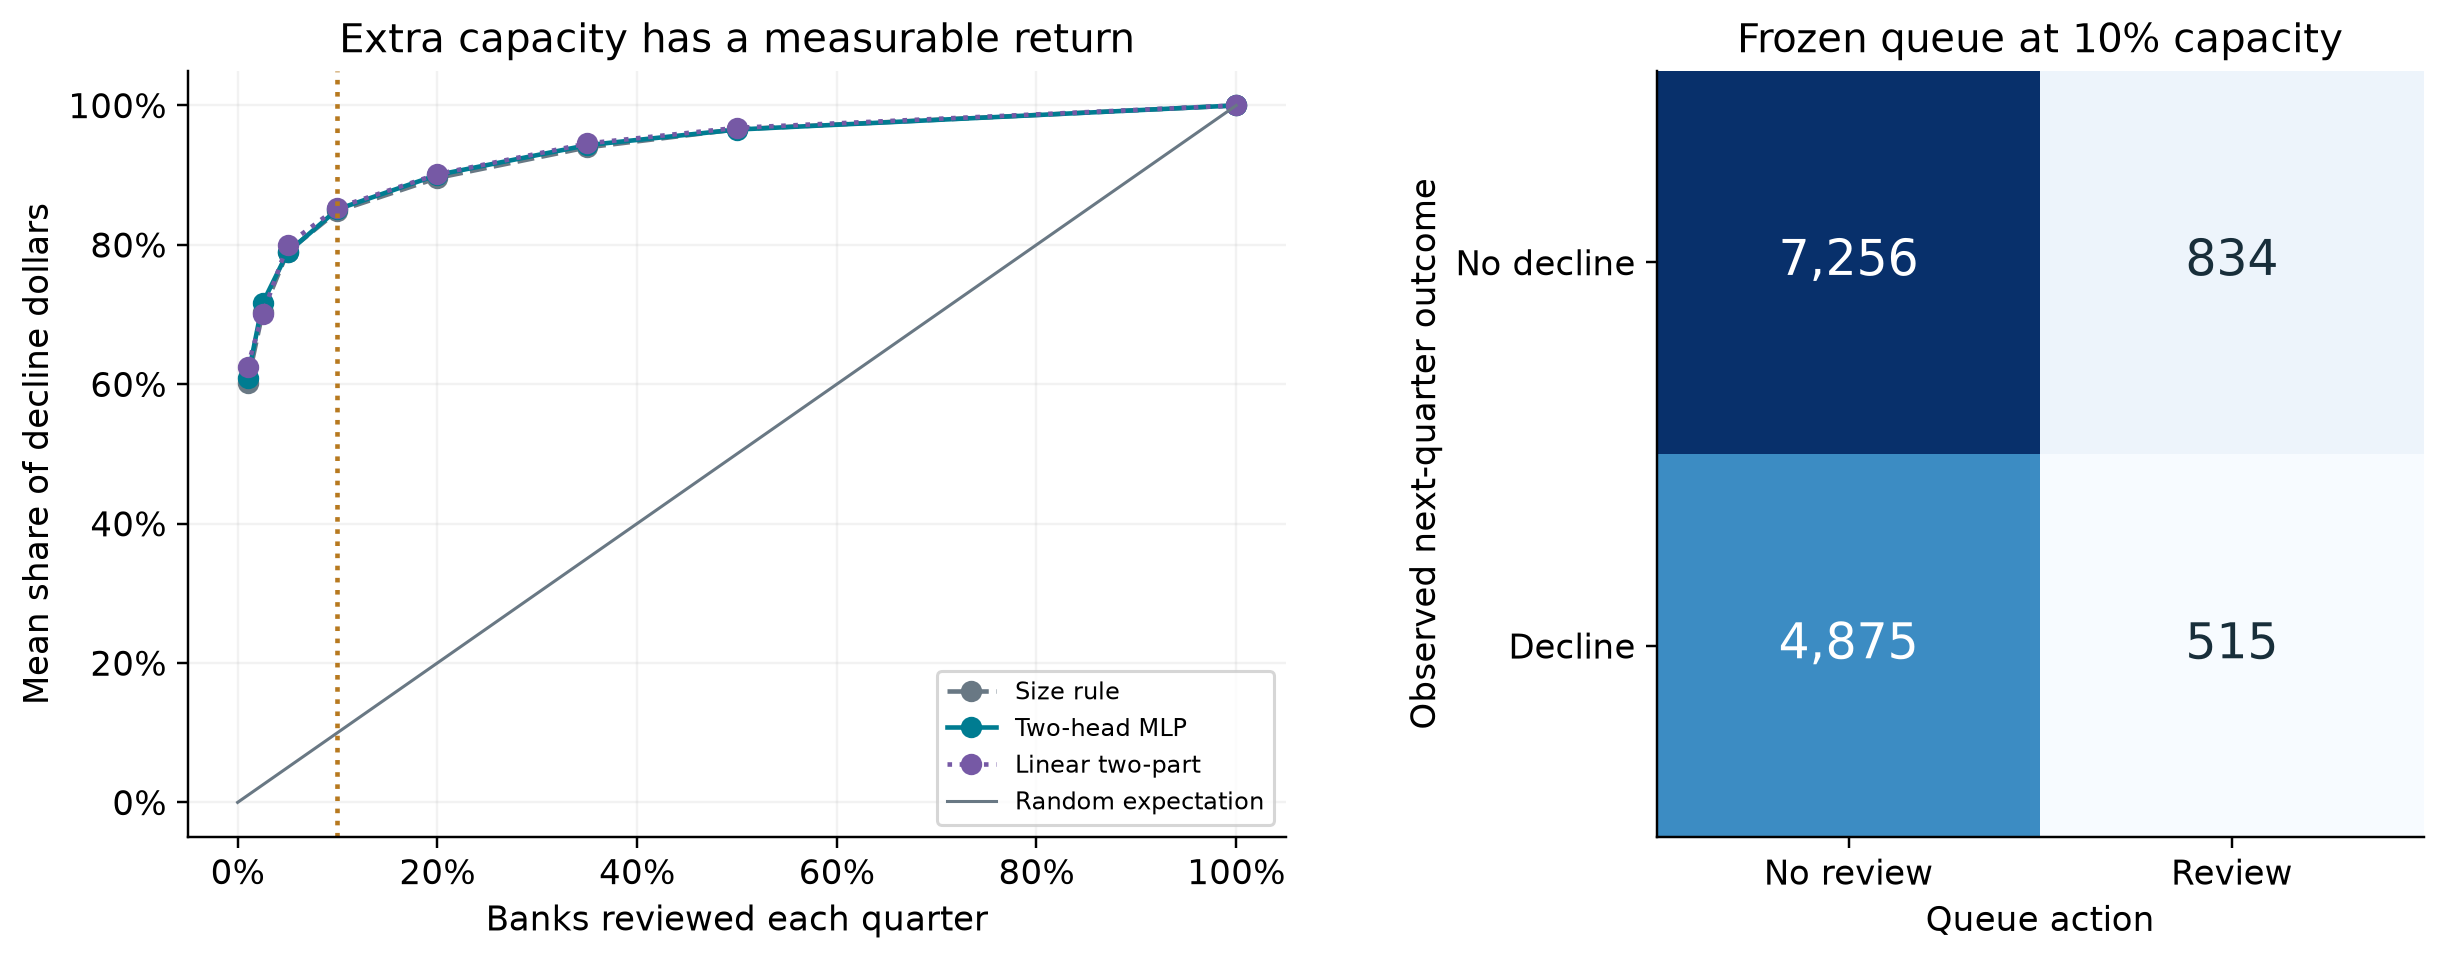

Outcome,Rows
No decline / no review,7256
No decline / review,834
Decline / no review,4875
Decline / review,515


Quarter,Rows,Selected,Capture,Case recall,Precision
2024Q1,4519,452,93.09%,10.87%,53.54%
2024Q2,4498,450,85.09%,7.44%,27.78%
2024Q3,4463,447,77.82%,9.99%,33.11%


In [33]:
capacities = np.array([.01,.025,.05,.10,.20,.35,.50,1.0])
compare_names = list(dict.fromkeys(["Size rule","Two-head MLP",winner]))
curve_rows = []
for n in compare_names:
    for capacity in capacities:
        m,_ = rank_metrics(test,test_predictions[n]["priority"],capacity)
        curve_rows.append({"Model":n,"Capacity":capacity,"Capture":m["Mean quarterly capture"]})
curves = pd.DataFrame(curve_rows)
fig, axes = plt.subplots(1,2,figsize=(12,4.5))
model_colors = {"Size rule":GREY,"Two-head MLP":BLUE,winner:"#7659A5"}
for n,style in zip(compare_names,["--","-",":"]):
    c = curves.loc[curves.Model.eq(n)]
    axes[0].plot(c.Capacity,c.Capture,marker="o",ls=style,color=model_colors[n],label=n)
axes[0].plot([0,1],[0,1],color=GREY,lw=1,label="Random expectation")
axes[0].axvline(CAPACITY,color=AMBER,ls=":");axes[0].legend(fontsize=8)
axes[0].set(xlabel="Banks reviewed each quarter",ylabel="Mean share of decline dollars",title="Extra capacity has a measurable return")
axes[0].xaxis.set_major_formatter(PercentFormatter(1));axes[0].yaxis.set_major_formatter(PercentFormatter(1))
selected = queue_mask(test,test_predictions[winner]["priority"])
cm = confusion_matrix(test.fell,selected,labels=[0,1])
axes[1].imshow(cm,cmap="Blues");axes[1].grid(False)
axes[1].set_xticks([0,1],["No review","Review"]);axes[1].set_yticks([0,1],["No decline","Decline"])
for i in range(2):
    for j in range(2):
        axes[1].text(j,i,f"{cm[i,j]:,}",ha="center",va="center",color="white" if cm[i,j]>cm.max()/2 else INK,fontsize=16)
axes[1].set(title=f"Frozen queue at 10% capacity",xlabel="Queue action",ylabel="Observed next-quarter outcome")
finish(fig,"23_capacity_confusion")
receipt(pd.DataFrame({"Outcome":["No decline / no review","No decline / review","Decline / no review","Decline / review"],"Rows":cm.ravel()}),"Exact queue confusion counts")
_,quarter_queue = rank_metrics(test,test_predictions[winner]["priority"])
receipt(quarter_queue,"Review workload by quarter",{"Capture":"{:.2%}","Case recall":"{:.2%}","Precision":"{:.2%}"})

### 7.4 · Are the amount estimates accurate where declines actually occur?

**Short answer.** Report positive-row error in dollars and log units. Typical-row accuracy and giant-bank errors need different views.

**ELI8.** Being off by one marble on most bags can look good even if you miss an entire bucket once.

**Read the code.** A scatter compares actual and estimated positive amounts on log1p axes, allowing predicted zeros. An identity line marks perfect estimates. MAE, median absolute error, and log MAE expose different error scales.

**Predict before Run:** Does the priority score belong on a calibrated expected-loss chart?

<details><summary>Check your reasoning</summary>

No. We evaluate the conditional severity head here. Priority is a ranking proxy, not a promised amount.

</details>

Model,MAE USD M,Median AE USD M,Log MAE
Training median,76.65,3.70,1.045
Repeat prior decline,77.50,4.34,1.592
Linear two-part,52.33,3.04,0.657
Boosted trees,50.14,2.93,0.639
Two-head MLP,66.18,2.97,0.662


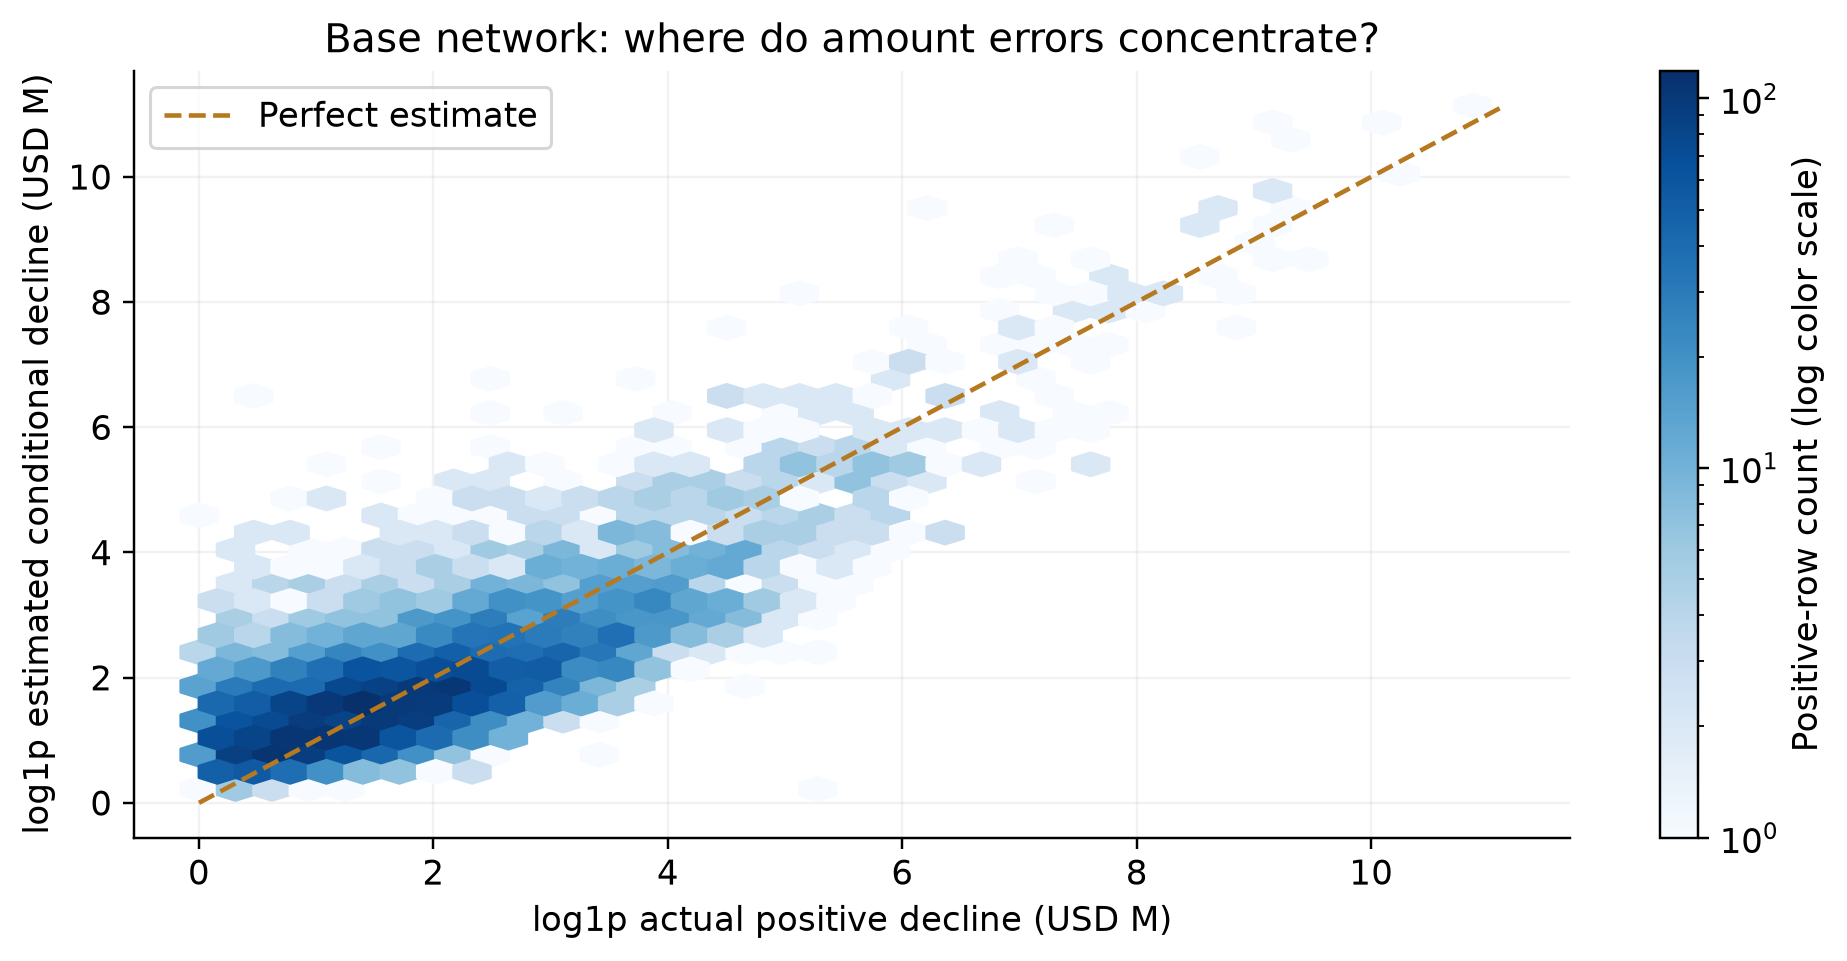

In [34]:
mask = test.fell.eq(1).to_numpy(); actual_positive = test.runoff_m.to_numpy()[mask]
amount_predictions = {"Training median":np.full(mask.sum(),positive_train.runoff_m.median()),
    "Repeat prior decline":previous_decline(test)[mask],
    **{n:test_predictions[n]["severity"][mask] for n in probability_names}}
amount_scores = []
for name,pred in amount_predictions.items():
    error = np.abs(pred-actual_positive)
    amount_scores.append({"Model":name,"MAE USD M":error.mean(),"Median AE USD M":np.median(error),
        "Log MAE":np.mean(np.abs(np.log1p(pred)-np.log1p(actual_positive)))})
receipt(pd.DataFrame(amount_scores),"Severity on positive historical rows only",{"MAE USD M":"{:,.2f}","Median AE USD M":"{:,.2f}","Log MAE":"{:.3f}"})
predicted_positive = amount_predictions["Two-head MLP"]
fig, ax = plt.subplots()
h=ax.hexbin(np.log1p(actual_positive),np.log1p(predicted_positive),gridsize=35,mincnt=1,bins="log",cmap="Blues")
upper=max(np.log1p(actual_positive).max(),np.log1p(predicted_positive).max())
ax.plot([0,upper],[0,upper],ls="--",color=AMBER,label="Perfect estimate")
ax.set(xlabel="log1p actual positive decline (USD M)",ylabel="log1p estimated conditional decline (USD M)",title="Base network: where do amount errors concentrate?")
ax.legend();fig.colorbar(h,ax=ax,label="Positive-row count (log color scale)");finish(fig,"24_severity")

### 7.5 · Does the headline improvement survive each quarter and bank size?

**Short answer.** Inspect quarter-level differences and size slices fixed from training. Aggregate capture may conceal a weak quarter or strong concentration.

**ELI8.** A team can win the season total while losing two of three games. Look at each game too.

**Read the code.** Quarter deltas compare the base network and frozen winner with size. Size groups use training quartiles and fixed boundaries; slice capture uses the original global queue, not extra review slots within each group.

**Predict before Run:** If a small-bank slice has poor capture, can we infer discrimination against depositors?

<details><summary>Check your reasoning</summary>

No. These are institution-size diagnostics. Customer demographics and outcomes are absent; fairness claims need an appropriate population and evidence.

</details>

Quarter,Linear two-part,Size rule,Two-head MLP
2024Q1,93.09%,92.93%,93.07%
2024Q2,85.09%,84.26%,84.86%
2024Q3,77.82%,77.28%,77.35%


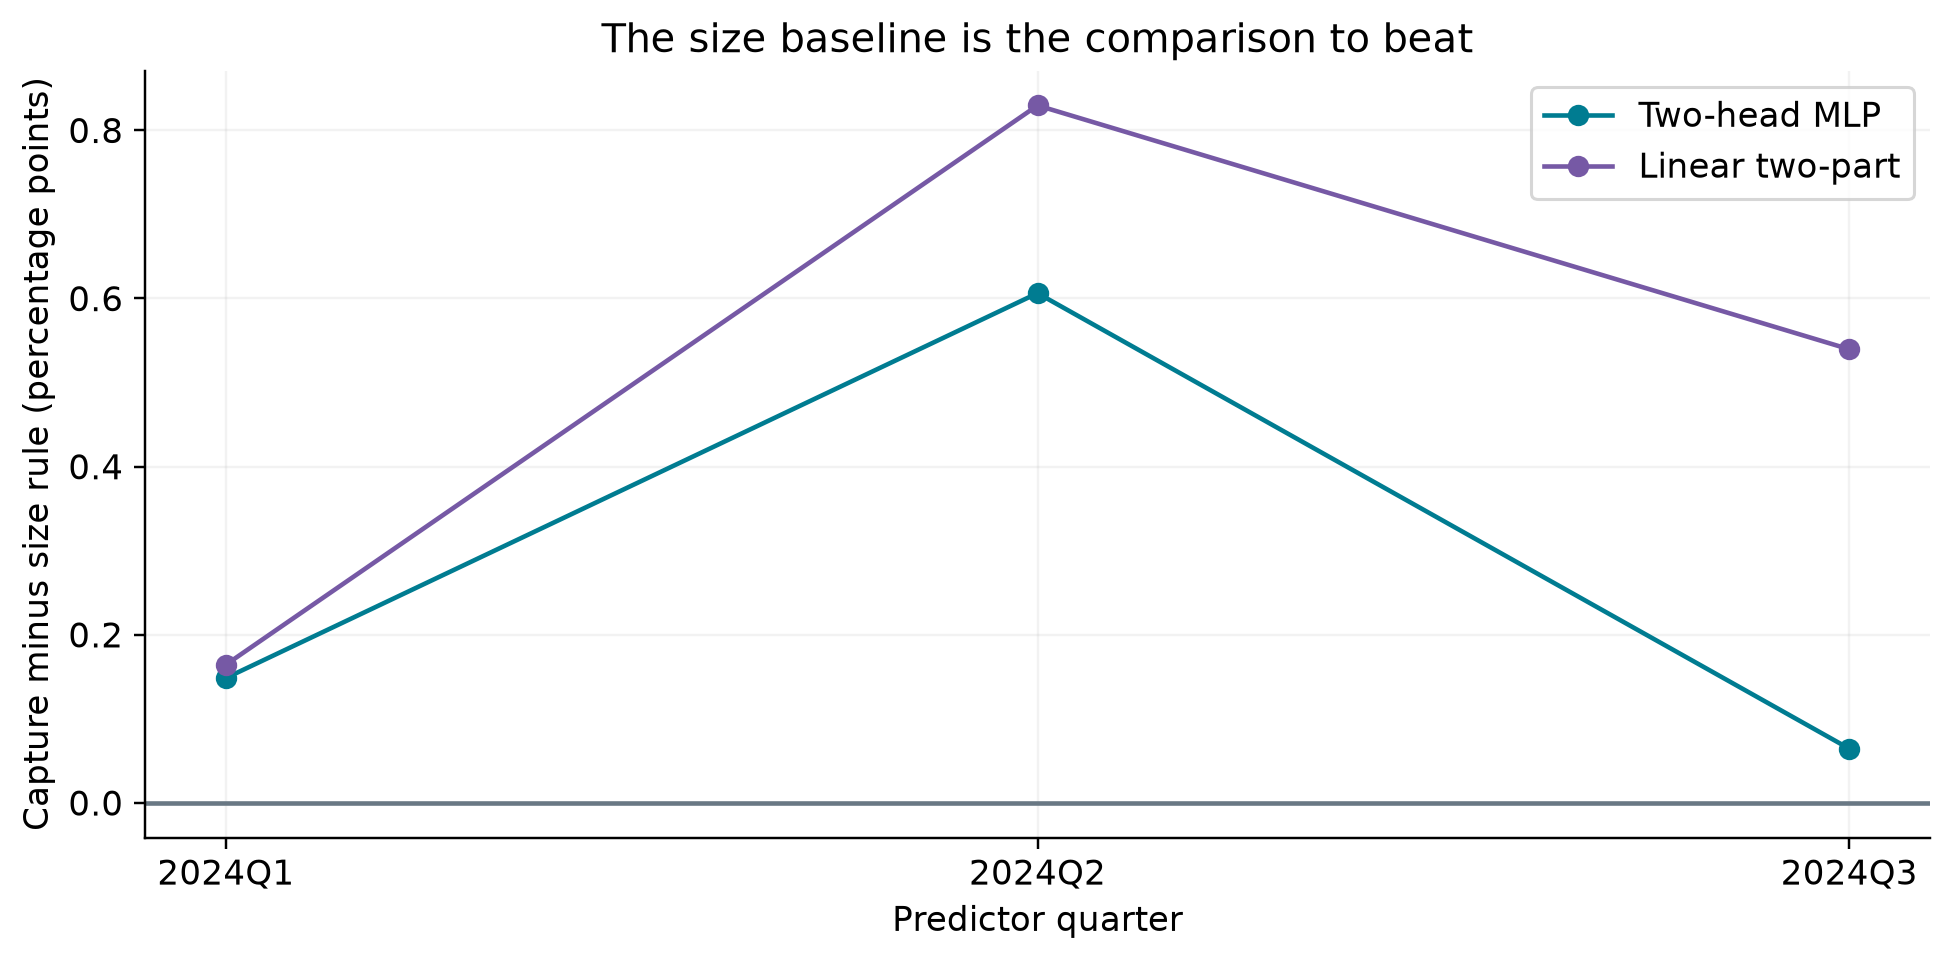

Training-size group,Rows,Review share,Dollar share,Captured within group
Smallest,2912,0.10%,0.62%,0.34%
Lower middle,3189,0.00%,1.43%,0.00%
Upper middle,3528,0.17%,3.41%,3.34%
Largest,3851,34.80%,94.54%,94.41%


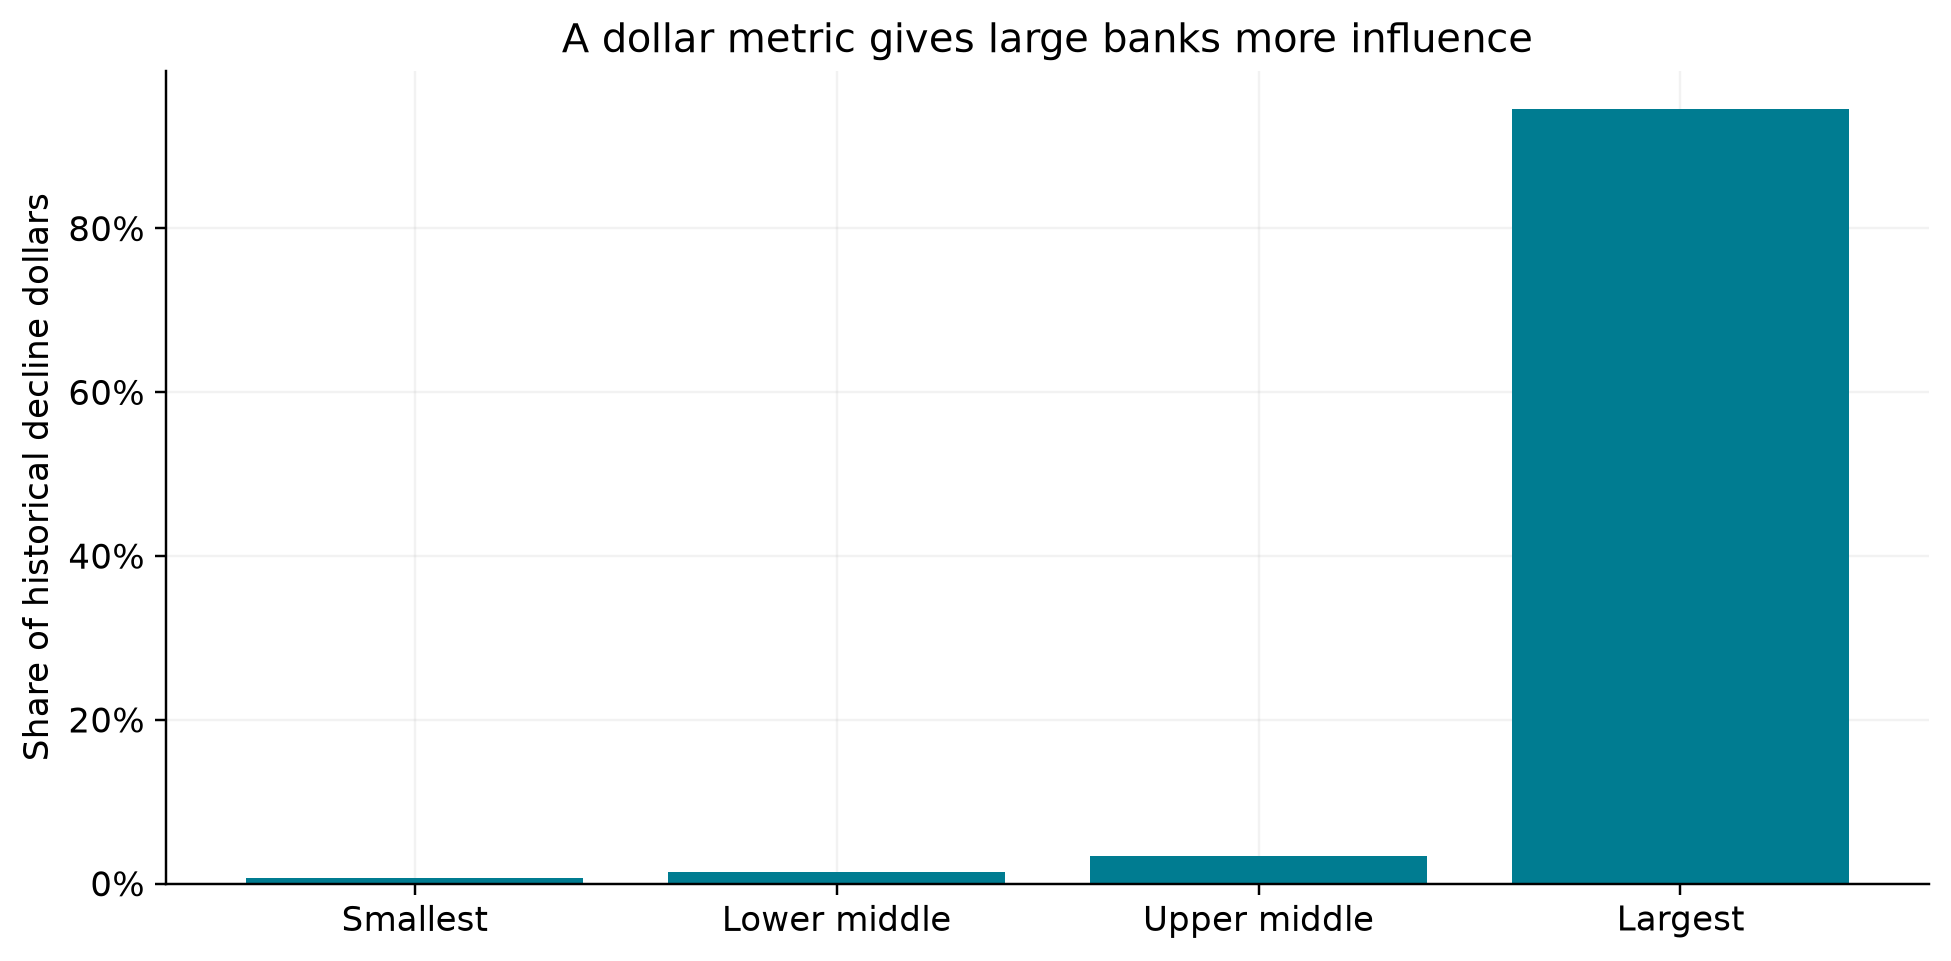

In [35]:
quarter_rows=[]
for n in compare_names:
    _,q = rank_metrics(test,test_predictions[n]["priority"])
    quarter_rows.append(q.assign(Model=n))
quarter_comparison=pd.concat(quarter_rows,ignore_index=True)
wide=quarter_comparison.pivot(index="Quarter",columns="Model",values="Capture")
receipt(wide.reset_index(),"Capture can change by quarter",{n:"{:.2%}" for n in compare_names})
fig,ax=plt.subplots()
for n in compare_names:
    if n!="Size rule": ax.plot(wide.index,100*(wide[n]-wide["Size rule"]),marker="o",color=model_colors[n],label=n)
ax.axhline(0,color=GREY);ax.set(ylabel="Capture minus size rule (percentage points)",xlabel="Predictor quarter",title="The size baseline is the comparison to beat");ax.legend()
finish(fig,"25_quarter_differences")
size_edges=np.r_[-np.inf,train.deposit_m.quantile([.25,.5,.75]).to_numpy(),np.inf]
slice_frame=test.assign(size_group=pd.cut(test.deposit_m,size_edges,labels=["Smallest","Lower middle","Upper middle","Largest"]),selected=selected)
slice_rows=[]
for group,g in slice_frame.groupby("size_group",observed=True):
    slice_rows.append({"Training-size group":str(group),"Rows":len(g),"Review share":g.selected.mean(),
        "Dollar share":g.runoff_m.sum()/test.runoff_m.sum(),
        "Captured within group":g.loc[g.selected,"runoff_m"].sum()/g.runoff_m.sum()})
slices=pd.DataFrame(slice_rows)
receipt(slices,"Fixed size groups; frozen winner's original queue",{c:"{:.2%}" for c in ["Review share","Dollar share","Captured within group"]})
fig,ax=plt.subplots()
ax.bar(slices["Training-size group"],slices["Dollar share"],color=BLUE)
ax.set(ylabel="Share of historical decline dollars",title="A dollar metric gives large banks more influence");ax.yaxis.set_major_formatter(PercentFormatter(1))
finish(fig,"26_size_slices")

### 7.6 · How uncertain is the network's advantage over size?

**Short answer.** A paired bank-cluster bootstrap preserves each sampled bank's observed quarter history and compares both ranking methods on the same resample.

**ELI8.** Pull whole folders from a filing cabinet, not loose pages. Keep a bank's pages together each time you rebuild the sample.

**Read the code.** We sample certificates with replacement, recompute quarter-specific queues, and store the network-minus-size difference. Two hundred replicates provide a teaching interval; it is conditional on fitted models and these three quarters.

**Predict before Run:** Does this interval cover uncertainty about next year's economy or training process?

<details><summary>Check your reasoning</summary>

No. It excludes new temporal regimes, data revisions, model fitting uncertainty, and validation-selection uncertainty. Three quarters cannot establish broad temporal reliability.

</details>

Comparison,Observed pp,2.5% bootstrap pp,97.5% bootstrap pp
Base network minus size,+0.27,-0.29,+1.21


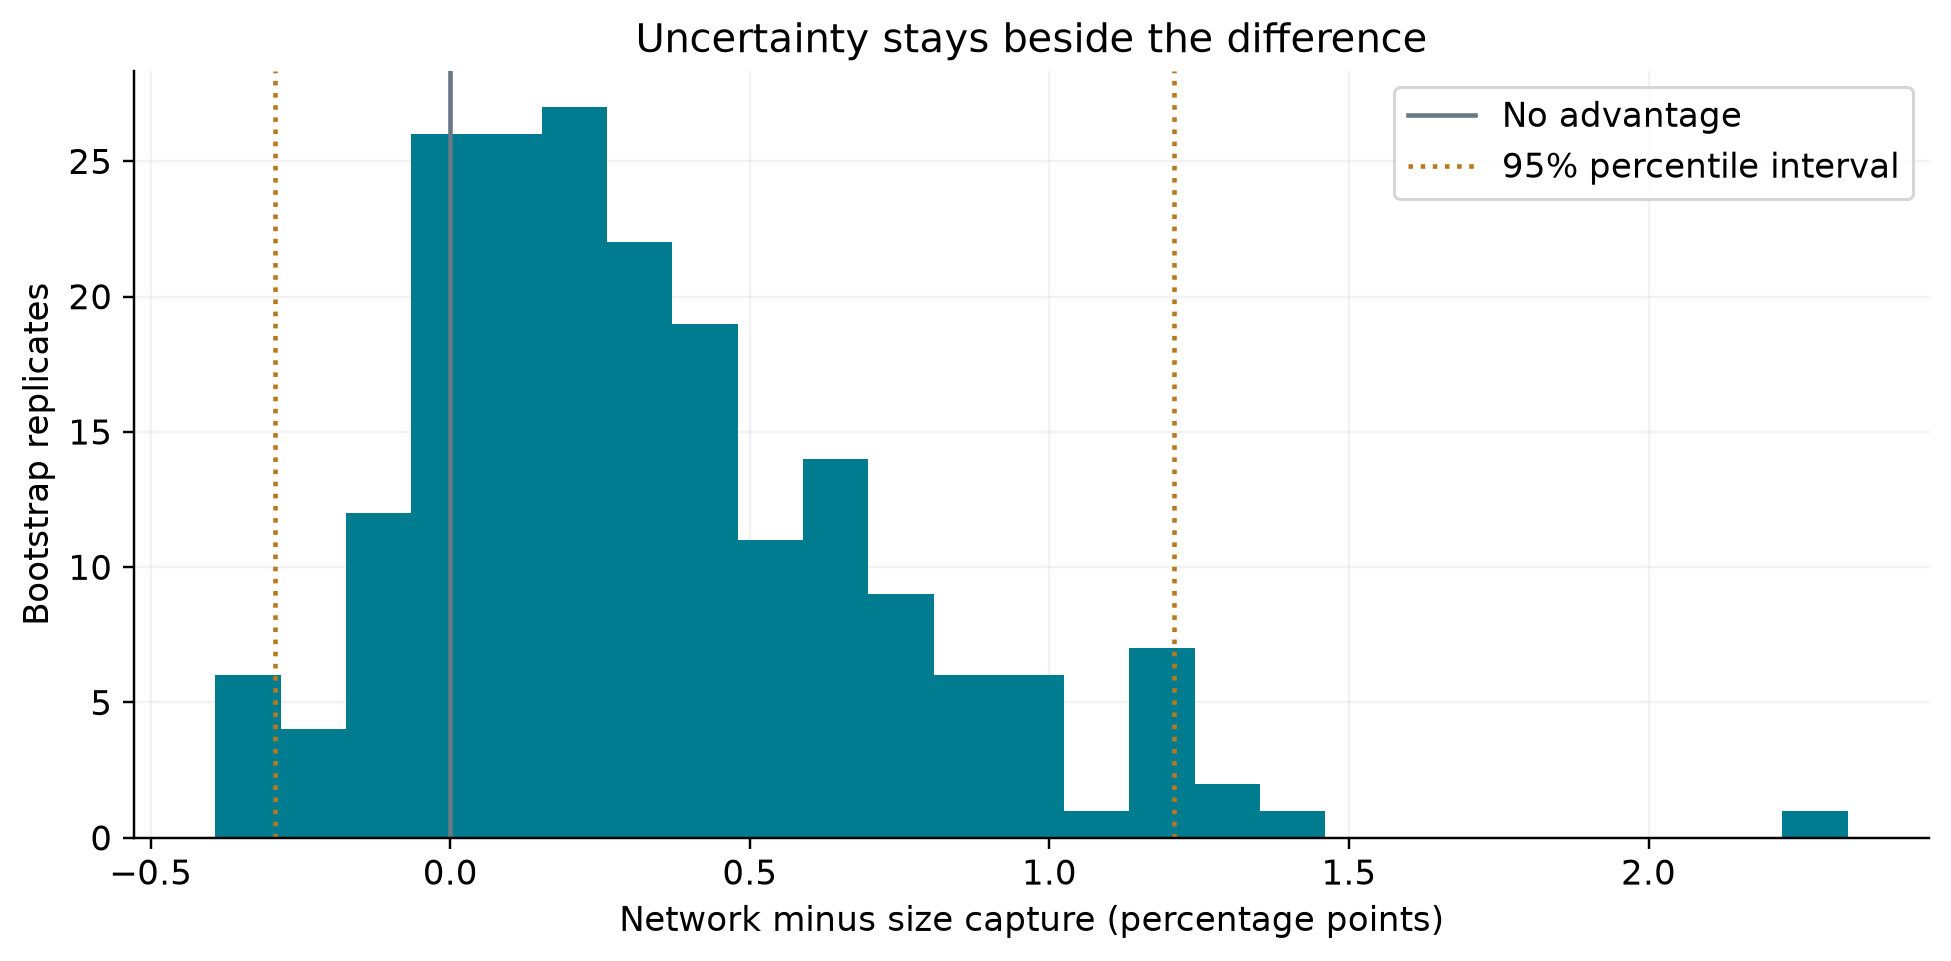

In [36]:
base_priority=test_predictions["Two-head MLP"]["priority"]
bootstrap_frame=test[["CERT","report_date","runoff_m","fell","deposit_m"]].reset_index(drop=True)
bank_positions={cert:np.asarray(pos) for cert,pos in bootstrap_frame.groupby("CERT").indices.items()}
certs=np.array(list(bank_positions));rng=np.random.default_rng(SEED)
bootstrap_delta=[]
for _ in range(200):
    sampled=rng.choice(certs,size=len(certs),replace=True)
    positions=np.concatenate([bank_positions[c] for c in sampled])
    sample=bootstrap_frame.iloc[positions].reset_index(drop=True)
    a=rank_metrics(sample,base_priority[positions])[0]["Mean quarterly capture"]
    b=rank_metrics(sample,sample.deposit_m.to_numpy())[0]["Mean quarterly capture"]
    bootstrap_delta.append(100*(a-b))
low,high=np.quantile(bootstrap_delta,[.025,.975])
hist_index=historical_scores.set_index("Model")
point_delta=100*(hist_index.loc["Two-head MLP","Mean quarterly capture"]-hist_index.loc["Size rule","Mean quarterly capture"])
receipt(pd.DataFrame({"Comparison":["Base network minus size"],"Observed pp":[point_delta],"2.5% bootstrap pp":[low],"97.5% bootstrap pp":[high]}),
    "Paired bank-cluster bootstrap; 200 replicates",{"Observed pp":"{:+.2f}","2.5% bootstrap pp":"{:+.2f}","97.5% bootstrap pp":"{:+.2f}"})
fig,ax=plt.subplots()
ax.hist(bootstrap_delta,bins=25,color=BLUE);ax.axvline(0,color=GREY,label="No advantage")
ax.axvline(low,color=AMBER,ls=":");ax.axvline(high,color=AMBER,ls=":",label="95% percentile interval")
ax.set(xlabel="Network minus size capture (percentage points)",ylabel="Bootstrap replicates",title="Uncertainty stays beside the difference");ax.legend()
finish(fig,"27_bootstrap")
takeaway("The interval has a specific scope",f"Observed difference {point_delta:+.2f} pp; bank-cluster interval [{low:+.2f}, {high:+.2f}] pp. "
    "This measures resampling sensitivity within the historical evaluation, not a deployment guarantee.")

### 7.7 · What would the analyst actually receive?

**Short answer.** A dated, ranked, review-only list with transparent scores and later outcomes for historical auditing.

**ELI8.** A homework checklist tells the teacher where to look first. Being on the list does not prove someone did anything wrong.

**Read the code.** The final historical quarter shows the frozen winner's top ten selected rows. CERT provides a join key. Observed future amounts are labeled hindsight-only and would be absent from a live queue.

**Predict before Run:** Would all available 2024 Q4 banks appear in this list?

<details><summary>Check your reasoning</summary>

No. This is a historical scored cohort whose next report exists in the file. Live eligibility cannot require a future report and needs a separate scoring workflow.

</details>

In [37]:
watchlist=test[["CERT","NAME","report_date","deposit_m","runoff_m"]].copy()
watchlist["Priority score"]=test_predictions[winner]["priority"]
watchlist["Review"]=selected
latest=watchlist.report_date.max()
historical_watchlist=watchlist.loc[watchlist.report_date.eq(latest)&watchlist.Review].sort_values(
    ["Priority score","CERT"],ascending=[False,True]).head(10)
display_list=historical_watchlist[["CERT","NAME","deposit_m","Priority score","runoff_m"]].rename(
    columns={"deposit_m":"Current deposits USD M","runoff_m":"Later decline USD M (hindsight)"})
receipt(display_list,f"Historical review list · {latest:%Y-%m-%d} · {winner}",
    {"Current deposits USD M":"{:,.1f}","Priority score":"{:,.1f}","Later decline USD M (hindsight)":"{:,.1f}"})
watchlist.to_csv(OUT/"historical_watchlist.csv",index=False)

CERT,NAME,Current deposits USD M,Priority score,Later decline USD M (hindsight)
628,JPMORGAN CHASE BANK NA,"2,032,340.0","3,539.8",0.0
3510,BANK OF AMERICA NA,"1,892,511.0","3,106.0",0.0
3511,WELLS FARGO BANK NA,"1,397,345.0","2,204.4",0.0
7213,CITIBANK NATIONAL ASSN,"766,194.0","1,726.0","8,721.0"
33124,GOLDMAN SACHS BANK USA,"370,460.0","1,029.4",0.0
639,BANK OF NEW YORK MELLON,"195,220.0","1,014.1","1,052.0"
6548,U S BANK NATIONAL ASSN,"522,481.6",963.2,440.9
14,STATE STREET BANK&TRUST CO,"182,432.0",931.3,0.0
33692,STANDARD CHARTERED BANK PLC,"39,665.3",854.6,"2,363.4"
6384,PNC BANK NATIONAL ASSN,"429,848.6",752.1,0.0


### 7.8 · What can I conclude, and what would I test next?

**Short answer.** Use the computed difference, probability diagnostics, and study limits to state the result. The next experiment needs fresh temporal evidence.

**ELI8.** A good science notebook tells us what happened, what remains uncertain, and what observation could change our mind.

**Read the code.** The conclusion reads actual score tables rather than hard-coding an optimistic claim. The final audit checks source immutability, target arithmetic, shapes, and saved provenance. It does not certify deployment readiness.

**Predict before Run:** What is the first change needed for a genuine early warning claim?

<details><summary>Check your reasoning</summary>

A point-in-time dataset with publication dates and a fresh future evaluation, using only features and labels available when each prediction is made.

</details>

In [38]:
base_capture=hist_index.loc["Two-head MLP","Mean quarterly capture"]
size_capture=hist_index.loc["Size rule","Mean quarterly capture"]
winner_capture=hist_index.loc[winner,"Mean quarterly capture"]
evidence_word="includes zero" if low<=0<=high else "excludes zero in this resampling exercise"
takeaway("The baseline determines what the headline means",
    f"Across 2024 Q1–Q3, reviewing 10% each quarter captures {base_capture:.2%} of decline dollars on an equal-quarter average with the base network, "
    f"versus {size_capture:.2%} with size alone ({point_delta:+.2f} percentage points). The bank-cluster interval {evidence_word}. "
    f"The validation-selected method was {winner}, with historical capture {winner_capture:.2%}. "
    "These are retrospective ranking results; no amount is claimed as money saved.")
wm_counterintuitive_card(title="A high capture rate can come from bank size",theme=theme,
    why_misread="A large captured-dollar percentage can sound like the network identified hidden warning signals.",
    ordinary_process="Large banks contain more deposit dollars and can dominate the observed decline total even under a size-only rule.",
    conclusion_boundary="Judge incremental capture, cases, calibration, and stability. The reused period and absent publication timestamps prevent a fresh live-warning claim.")
assert pd.util.hash_pandas_object(raw,index=True).sum()==raw_fingerprint
sample=test.iloc[0]
next_row=reviewed.loc[reviewed.CERT.eq(sample.CERT)&reviewed.report_date.eq(sample.target_date)].iloc[0]
assert np.isclose(sample.runoff_m,max(0,sample.DEPDOM-next_row.DEPDOM)/1000)
assert all(np.isfinite(p["priority"]).all() for p in test_predictions.values())
validation_scores.to_csv(OUT/"validation_scores.csv",index=False)
historical_scores.to_csv(OUT/"historical_scores.csv",index=False)
pd.DataFrame(experiment_log).to_csv(OUT/"experiment_log.csv",index=False)
summary={**frozen,"train_rows":len(train),"validation_rows":len(valid),"historical_rows":len(test),
    "network_capture":float(base_capture),"size_capture":float(size_capture),"winner_capture":float(winner_capture),
    "network_difference_pp":float(point_delta),"bootstrap_interval_pp":[float(low),float(high)],
    "python":platform.python_version(),"packages":{n:importlib.metadata.version(n) for n in ["numpy","pandas","scikit-learn","tensorflow","wm-notecards"]}}
(OUT/"run_summary.json").write_text(json.dumps(summary,indent=2))
print("Audit passed: source unchanged; target manually reconciled; predictions finite; result receipts saved.")

Audit passed: source unchanged; target manually reconciled; predictions finite; result receipts saved.


## 8. Can you now explain the whole process without the notebook?

### Retrieval practice: answer aloud before checking

1. What is the row grain, and why is the certificate alone an incomplete key?
2. Which two source fields contain blanks, and what is the treatment of each?
3. How does a missing future report differ from an observed zero decline?
4. Which financial extremes did we retain, and why?
5. Explain the difference between a log axis, a log predictor, and a log target.
6. Which date boundary protects the training labels from validation?
7. Why can a chronologically correct notebook still fail a real-time availability test?
8. What does one Dense layer compute, and why do hidden activations matter?
9. How does a gradient differ from a prediction?
10. What is the difference between epoch, batch size, learning rate, and patience?
11. Why does only the severity head ignore zero-decline rows?
12. Why is chance × typical positive severity a ranking proxy rather than expected loss?
13. Which result would make you prefer the size rule?
14. Why can ROC AUC improve while Brier score gets worse?
15. What does a review-queue false positive mean?
16. Why do we bootstrap certificates rather than independent rows?
17. Why is seed sensitivity different from future-period uncertainty?
18. What makes the 2024 period reused rather than untouched?

<details><summary>Answer key</summary>

1. One bank certificate and reporting quarter; one bank appears repeatedly.
2. EQ and STALP. Model equity ratios use a training-median fill and missing flag; state stays descriptive context.
3. The former has no observable label; the latter is a valid measured outcome.
4. Large banks and plausible negative equity remain; unusual values are not proof of error.
5. The first changes display, the second changes inputs, the third changes the fitted error scale.
6. Maximum training outcome date precedes the first validation predictor date; embargo quarters make the gap explicit.
7. Accounting dates omit publication lag and revisions.
8. Weighted sums plus biases and activations; nonlinear activations prevent a stack from collapsing into one linear map.
9. A prediction is an output; a gradient describes local loss sensitivity to a parameter.
10. Data passes; examples per update; step-size control; tolerated non-improving epochs.
11. It answers a conditional amount question; the chance head must see both classes.
12. Log MAE targets a median-style amount; an expectation identity requires a conditional mean.
13. Comparable or better capture, more stable quarters, and no meaningful incremental network benefit under the decision contract.
14. Ordering can improve while probability magnitudes become too confident or too low.
15. Analyst time is spent on a bank with no measured next-quarter decline; it is not a false fraud accusation.
16. Reports from the same bank are dependent.
17. Seeds change optimization randomness; new periods change the evidence and potentially the economic regime.
18. The original assignment already reported results on that year.

</details>

### Deliberate-practice labs

Run these in a **copy** and keep the existing historical result as a fixed reference. These are exercises, not unfinished requirements of the completed experiment.

| Lab | Change one thing | Predict first | Evaluate on |
|---|---|---|---|
| Missingness | Remove the missing-equity flag | Does reporting practice help? | Validation, same rows |
| Learning rate | Compare 0.0003 with 0.001 | Slower learning or less instability? | Validation curves and capture |
| Architecture | Use one hidden layer of 16 units | Does depth add value? | Same validation budget |
| Objective | Compare log MAE with log MSE | Which errors get extra weight? | Positive-row dollar and log errors |
| Population | Test USD 5M and USD 25M eligibility | Does the business question change? | New counts and validation denominators |
| Decision | Rank by chance only | More cases or more dollars? | Validation case recall and dollar capture |
| Availability | Obtain report publication dates | Which forecasts remain feasible? | A fresh point-in-time backtest |

For each experiment write: **hypothesis → one change → expected effect → measured effect → decision → remaining uncertainty**.
If you change the population, do not compare percentages as if the denominator were unchanged.

### What expert practice would require next

**For an analyst:** review the named institutions' reports and corporate actions before interpreting balance changes;
set actual review capacity and cost; retain an auditable dated queue; compare with a simple size baseline.

**For a model builder:** obtain publication timestamps and frozen historical data vintages; distinguish mergers and reporting changes;
score live-eligible banks without requiring a future report; run multiple rolling time splits; evaluate on new periods unavailable during development;
test calibration if probabilities are operationally used; monitor drift and missingness; document failure cases and retraining rules.
The current sample excludes unmatched exits and does not establish behavior for failing or newly created institutions.

### Troubleshooting

- **File not found:** the working directory must contain `data/` and `vendor/`.
- **Missing EDA helper:** synchronize the supplied environment and bundled wheel. Version `0.1.0` alone does not distinguish package builds.
- **TensorFlow configuration error after rerunning setup:** restart the kernel, then Run All. Device/thread configuration belongs before first model use.
- **A slow training cell:** eager CPU training favors inspectability. Start with saved outputs; reduce the experiment budget only in a practice copy and label its results.
- **Unexpected result after out-of-order execution:** restart and Run All. Do not patch outputs by hand.
- **Different results on another machine:** compare source fingerprint, package versions, seed, split counts, and experiment settings before interpreting differences.

### Sources and reproducibility

- Data: local `data/fdic_financials_2020_2024.csv`; extraction fields, dates, API pagination checks, and endpoint in `download_fdic.py`.
- [FDIC field definitions](https://api.fdic.gov/banks/docs/risview_properties.yaml) and [BankFind financial reporting documentation](https://banks.data.fdic.gov/docs/).
- [TensorFlow training and evaluation guide](https://www.tensorflow.org/guide/keras/training_with_built_in_methods): multi-output training, sample weighting, callbacks.
- [scikit-learn evaluation documentation](https://scikit-learn.org/stable/modules/model_evaluation.html): probability, ranking, and regression metrics.
- [scikit-learn common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html): preprocessing and leakage.
- [wm-notecards PR #2](https://github.com/wmoore012/wm-notecards/pull/2): checked open, mergeable, and passing listed checks during authoring.
  The bundled `wm_notecards.eda` source matches PR head `906547888cc4a785992d1b8abf059a7badc2d34c` exactly
  (SHA-256 `0660c57ca1c6bc09c0a71d54d25d4a63a1e836d8dc2b09b9675564610ee65354`). No merge is required to run this notebook.
- The user's supplied EDA text inspired the audit questions. Its suggestion to eliminate outliers was evaluated as reference material;
  plausible extreme values are retained here. The attached screenshot provides visual context, not computational evidence.

`masterclass_outputs/run_summary.json` records exact data identity, package versions, split counts, model choice, and measured results.
CSV receipts preserve the experiment comparison and historical queue. PNG figures are generated by visible notebook code.